<a href="https://colab.research.google.com/github/Aninda11/-CVPR-Machine-Learning/blob/main/Uncertain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Content-Selection vs Symbol-Binding Uncertainty in Multiple-Choice Language Models

**Granite-3.3-2B-Instruct + MMLU-Pro pilot**

This notebook contains:

- one separate installation cell;
- the **first ten moderate substantive code blocks**;
- eight counterbalanced presentations per question:
  - four option orders;
  - two output-label systems;
- uncertainty decomposition in content space;
- initial internal-representation analysis.

The first ten blocks do **not** perform causal patching. They establish whether the behavioural decomposition and internal content/symbol trajectories are stable enough to justify the later causal stage.

### Method references

- MMLU-Pro dataset: `https://huggingface.co/datasets/TIGER-Lab/MMLU-Pro`
- Granite-3.3-2B-Instruct: `https://huggingface.co/ibm-granite/granite-3.3-2b-instruct`
- TransformerBridge compatibility mode: `https://transformerlensorg.github.io/TransformerLens/content/compatibility_mode.html`


In [ ]:
# INSTALLATION CELL — not counted among the ten substantive blocks.
# Run once in a fresh Colab T4 runtime.
# Do NOT pin, downgrade, or replace NumPy, pandas, PyTorch, or SciPy.

%pip install -q -U transformer_lens
%pip install -q datasets scikit-learn

from importlib.metadata import version

for package in ("transformer-lens", "transformers", "datasets", "scikit-learn"):
    print(f"{package}: {version(package)}")

print("Installation complete. Continue to Block 1.")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.0 MB/s eta 0:00:00
transformer-lens: 3.6.0
transformers: 5.13.1
datasets: 4.0.0
scikit-learn: 1.6.1
Installation complete. Continue to Block 1.


## Block 1 — Imports, configuration, reproducibility, and output paths

In [ ]:
# =====================================================================
# BLOCK 1 — IMPORTS, CONFIGURATION, AND REPRODUCIBILITY
# =====================================================================

import gc
import json
import math
import random
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SEED = 20260805
MODEL_ID = "ibm-granite/granite-3.3-2b-instruct"
DATASET_ID = "TIGER-Lab/MMLU-Pro"

# Pilot settings. The later full run can increase N_QUESTIONS without
# changing the experimental definitions.
N_QUESTIONS = 200
CANDIDATE_POOL = 800
BATCH_SIZE = 2
MAX_PROMPT_TOKENS = 720
N_CALIBRATION_PER_SYSTEM = 20
MAX_ACTIVATION_QUESTIONS = 120
RESIDUAL_LAYER_STRIDE = 4
BOOTSTRAP_SAMPLES = 1000

OUTPUT_DIR = Path("/content/content_binding_uncertainty_pilot")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_grad_enabled(False)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. In Colab choose Runtime > Change runtime type > T4 GPU."
    )

DEVICE = "cuda"
DTYPE = torch.float16

print("GPU:", torch.cuda.get_device_name(0))
print("Model:", MODEL_ID)
print("Questions:", N_QUESTIONS)
print("Output directory:", OUTPUT_DIR)

def save_json(data, filename):
    with open(OUTPUT_DIR / filename, "w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2, default=str)

def batched(values, batch_size):
    values = list(values)
    for start in range(0, len(values), batch_size):
        yield values[start:start + batch_size]

def stable_rng(question_id, salt):
    return np.random.default_rng(
        SEED + int(question_id) * 1009 + int(salt)
    )

print("Block 1 complete.")


GPU: Tesla T4
Model: ibm-granite/granite-3.3-2b-instruct
Questions: 200
Output directory: /content/content_binding_uncertainty_pilot
Block 1 complete.


## Block 2 — Load Granite through TransformerBridge and verify the runtime

In [ ]:
# =====================================================================
# BLOCK 2 — MODEL, TOKENIZER, AND TRANSFORMERBRIDGE
# =====================================================================

from transformer_lens.model_bridge import TransformerBridge

gc.collect()
torch.cuda.empty_cache()

model = TransformerBridge.boot_transformers(
    MODEL_ID,
    device=DEVICE,
    dtype=DTYPE,
    trust_remote_code=False,
)

# We need legacy hook aliases but want raw Hugging Face inference numerics.
# no_processing=True registers aliases without folding or centering weights.
model.enable_compatibility_mode(
    no_processing=True,
    disable_warnings=True,
)
model.eval()

tokenizer = model.tokenizer
tokenizer.padding_side = "left"
tokenizer.truncation_side = "left"

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

if not getattr(tokenizer, "chat_template", None):
    raise RuntimeError(
        "The tokenizer has no chat template. This notebook requires an instruction model."
    )

print(
    f"Loaded {MODEL_ID}\n"
    f"layers={model.cfg.n_layers}, heads={model.cfg.n_heads}, "
    f"d_model={model.cfg.d_model}"
)

def apply_chat_template(user_text):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a careful multiple-choice question answering system. "
                "Do not provide reasoning, explanations, or thinking tags. "
                "Return only one allowed answer label."
            ),
        },
        {"role": "user", "content": user_text},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

save_json(
    {
        "model_id": MODEL_ID,
        "n_layers": model.cfg.n_layers,
        "n_heads": model.cfg.n_heads,
        "d_model": model.cfg.d_model,
        "dtype": str(DTYPE),
        "device": DEVICE,
    },
    "model_config.json",
)

print("Block 2 complete.")


config.json:   0%|          | 0.00/787 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/29.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/9.93k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.48M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/207 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

Loaded ibm-granite/granite-3.3-2b-instruct
layers=40, heads=32, d_model=2048
Block 2 complete.


## Block 3 — Load MMLU-Pro and create canonical four-option questions

In [ ]:
# =====================================================================
# BLOCK 3 — MMLU-PRO FOUR-OPTION CANONICALIZATION
# =====================================================================

raw_dataset = load_dataset(
    DATASET_ID,
    "default",
    split="test",
)

raw_dataset = raw_dataset.shuffle(seed=SEED).select(
    range(min(CANDIDATE_POOL, len(raw_dataset)))
)

def canonicalize_question(row):
    question_id = int(row["question_id"])
    options = [str(option).strip() for option in row["options"]]
    gold_original_index = int(row["answer_index"])

    if len(options) < 4 or not options[gold_original_index]:
        return None

    # Avoid duplicate option texts in the selected four-choice subset.
    seen_texts = {options[gold_original_index]}
    eligible_wrong = []

    for index, text in enumerate(options):
        if index == gold_original_index or not text or text in seen_texts:
            continue
        eligible_wrong.append(index)
        seen_texts.add(text)

    if len(eligible_wrong) < 3:
        return None

    rng = stable_rng(question_id, salt=11)
    sampled_wrong = rng.choice(
        eligible_wrong,
        size=3,
        replace=False,
    ).tolist()

    selected_original_indices = [gold_original_index] + sampled_wrong

    # Randomize canonical content identities so "content 0" is not always gold.
    canonical_permutation = stable_rng(
        question_id,
        salt=17,
    ).permutation(4).tolist()

    canonical_original_indices = [
        selected_original_indices[index]
        for index in canonical_permutation
    ]
    canonical_texts = [
        options[index]
        for index in canonical_original_indices
    ]
    gold_content_id = canonical_original_indices.index(
        gold_original_index
    )

    return {
        "question_id": question_id,
        "category": str(row["category"]),
        "question": str(row["question"]).strip(),
        "canonical_texts": canonical_texts,
        "canonical_original_indices": canonical_original_indices,
        "gold_content_id": int(gold_content_id),
    }

canonical_records = []

for row in raw_dataset:
    record = canonicalize_question(row)
    if record is not None:
        canonical_records.append(record)
    if len(canonical_records) >= N_QUESTIONS:
        break

questions_df = pd.DataFrame(canonical_records)

if len(questions_df) < N_QUESTIONS:
    raise RuntimeError(
        f"Only {len(questions_df)} usable questions were constructed; "
        f"{N_QUESTIONS} were requested."
    )

questions_df.to_pickle(OUTPUT_DIR / "canonical_questions.pkl")

print("Canonical questions:", len(questions_df))
print(
    "Gold canonical-ID counts:",
    questions_df["gold_content_id"].value_counts().sort_index().to_dict(),
)
print(
    "Category count:",
    questions_df["category"].nunique(),
)

print("Block 3 complete.")


README.md:   0%|          | 0.00/11.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.14MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 42.9kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/12032 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/70 [00:00<?, ? examples/s]

Canonical questions: 200
Gold canonical-ID counts: {0: 52, 1: 41, 2: 52, 3: 55}
Category count: 14
Block 3 complete.


## Block 4 — Generate four counterbalanced option orders and two label systems

In [ ]:
# =====================================================================
# BLOCK 4 — COUNTERBALANCED PRESENTATIONS
# =====================================================================

LABEL_SYSTEMS = {
    "letters": ["A", "B", "C", "D"],
    "digits": ["1", "2", "3", "4"],
}

def format_multiple_choice_prompt(question, ordered_texts, labels):
    allowed = ", ".join(labels)

    lines = [
        "Choose the best answer.",
        f"Reply with exactly one label from: {allowed}.",
        "Do not include any explanation.",
        "",
        f"Question: {question}",
        "",
    ]

    for label, option_text in zip(labels, ordered_texts):
        lines.append(f"{label}. {option_text}")

    lines.extend(["", "Answer:"])
    return "\n".join(lines)

presentation_records = []

for row in questions_df.itertuples(index=False):
    question_id = int(row.question_id)

    # A random base order followed by cyclic rotations guarantees that
    # every content identity appears in every output slot exactly once.
    base_order = stable_rng(
        question_id,
        salt=29,
    ).permutation(4).tolist()

    orders = [
        base_order[offset:] + base_order[:offset]
        for offset in range(4)
    ]

    for order_id, slot_to_content in enumerate(orders):
        ordered_texts = [
            row.canonical_texts[content_id]
            for content_id in slot_to_content
        ]

        for label_system, labels in LABEL_SYSTEMS.items():
            user_text = format_multiple_choice_prompt(
                row.question,
                ordered_texts,
                labels,
            )
            prompt = apply_chat_template(user_text)
            prompt_tokens = len(
                tokenizer.encode(
                    prompt,
                    add_special_tokens=False,
                )
            )

            presentation_records.append(
                {
                    "question_id": question_id,
                    "category": row.category,
                    "gold_content_id": int(row.gold_content_id),
                    "order_id": int(order_id),
                    "label_system": label_system,
                    "slot_to_content": list(slot_to_content),
                    "prompt": prompt,
                    "prompt_tokens": int(prompt_tokens),
                }
            )

presentation_df = pd.DataFrame(presentation_records)

# Keep only questions whose complete set of eight presentations is valid.
valid_question_ids = (
    presentation_df.groupby("question_id")
    .filter(
        lambda group: (
            len(group) == 8
            and group["prompt_tokens"].max() <= MAX_PROMPT_TOKENS
        )
    )["question_id"]
    .unique()
)

presentation_df = (
    presentation_df[
        presentation_df["question_id"].isin(valid_question_ids)
    ]
    .sort_values(
        ["question_id", "order_id", "label_system"]
    )
    .reset_index(drop=True)
)

questions_df = questions_df[
    questions_df["question_id"].isin(valid_question_ids)
].reset_index(drop=True)

if len(questions_df) < int(0.90 * N_QUESTIONS):
    raise RuntimeError(
        "Too many questions were removed by prompt-length or completeness checks."
    )

if not (
    presentation_df.groupby("question_id").size() == 8
).all():
    raise RuntimeError("At least one question does not have exactly eight presentations.")

presentation_df["presentation_index"] = np.arange(
    len(presentation_df),
    dtype=int,
)

presentation_df.to_pickle(OUTPUT_DIR / "presentations.pkl")

print("Retained questions:", len(questions_df))
print("Presentations:", len(presentation_df))
print("Maximum prompt tokens:", presentation_df["prompt_tokens"].max())
print(
    presentation_df.groupby(
        ["order_id", "label_system"]
    ).size().unstack().to_string()
)

print("Block 4 complete.")


Retained questions: 200
Presentations: 1600
Maximum prompt tokens: 581
label_system  digits  letters
order_id                     
0                200      200
1                200      200
2                200      200
3                200      200
Block 4 complete.


## Block 5 — Build label-token scorers, validate constrained scoring, and verify residual hooks

In [ ]:
# =====================================================================
# BLOCK 5 — LABEL SCORING VALIDATION AND HOOK VERIFICATION
# =====================================================================

def tokenize_prompts(prompts):
    encoded = tokenizer(
        list(prompts),
        padding=True,
        truncation=False,
        add_special_tokens=False,
        return_tensors="pt",
    )
    return (
        encoded["input_ids"].to(DEVICE),
        encoded["attention_mask"].to(DEVICE),
    )

def final_vocabulary_logits(prompts, fwd_hooks=None):
    outputs = []

    with torch.inference_mode():
        for prompt_batch in batched(prompts, BATCH_SIZE):
            tokens, attention_mask = tokenize_prompts(prompt_batch)

            if fwd_hooks:
                logits = model.run_with_hooks(
                    tokens,
                    attention_mask=attention_mask,
                    fwd_hooks=fwd_hooks,
                    return_type="logits",
                    use_cache=False,
                )
            else:
                logits = model(
                    tokens,
                    attention_mask=attention_mask,
                    return_type="logits",
                    use_cache=False,
                )

            outputs.append(
                logits[:, -1, :].float().cpu()
            )

            del tokens, attention_mask, logits

    return torch.cat(outputs, dim=0)

def build_label_token_sets(labels):
    token_sets = {}

    for label in labels:
        candidate_forms = [
            label,
            f" {label}",
            f"\n{label}",
        ]
        token_ids = []

        for form in candidate_forms:
            encoded = tokenizer.encode(
                form,
                add_special_tokens=False,
            )
            if len(encoded) == 1:
                token_ids.append(int(encoded[0]))

        token_ids = sorted(set(token_ids))

        if not token_ids:
            raise RuntimeError(
                f"No single-token representation exists for label {label!r}."
            )

        token_sets[label] = token_ids

    return token_sets

LABEL_TOKEN_SETS = {
    system: build_label_token_sets(labels)
    for system, labels in LABEL_SYSTEMS.items()
}

def option_logits_from_vocab(vocab_logits, label_system):
    labels = LABEL_SYSTEMS[label_system]
    columns = []

    for label in labels:
        token_ids = torch.tensor(
            LABEL_TOKEN_SETS[label_system][label],
            dtype=torch.long,
        )
        # Max, rather than log-sum-exp, avoids rewarding labels that
        # happen to have more valid one-token surface forms.
        columns.append(
            vocab_logits[:, token_ids].max(dim=-1).values
        )

    return torch.stack(columns, dim=-1)

validation_rows = []

for label_system in LABEL_SYSTEMS:
    sample_prompts = (
        presentation_df[
            presentation_df["label_system"] == label_system
        ]["prompt"]
        .iloc[:N_CALIBRATION_PER_SYSTEM]
        .tolist()
    )

    vocab_logits = final_vocabulary_logits(sample_prompts)
    option_logits = option_logits_from_vocab(
        vocab_logits,
        label_system,
    )

    constrained_slots = option_logits.argmax(dim=-1).numpy()
    greedy_token_ids = vocab_logits.argmax(dim=-1).numpy()

    token_to_slot = {}
    for slot, label in enumerate(LABEL_SYSTEMS[label_system]):
        for token_id in LABEL_TOKEN_SETS[label_system][label]:
            token_to_slot[int(token_id)] = int(slot)

    greedy_slots = np.array(
        [
            token_to_slot.get(int(token_id), -1)
            for token_id in greedy_token_ids
        ],
        dtype=int,
    )

    covered = greedy_slots >= 0
    coverage = float(covered.mean())
    agreement = (
        float(
            (
                constrained_slots[covered]
                == greedy_slots[covered]
            ).mean()
        )
        if covered.any()
        else 0.0
    )

    validation_rows.append(
        {
            "label_system": label_system,
            "greedy_label_coverage": coverage,
            "constrained_greedy_agreement": agreement,
        }
    )

scoring_validation_df = pd.DataFrame(validation_rows)
print(scoring_validation_df.round(4).to_string(index=False))

SCORING_VALID = bool(
    (
        scoring_validation_df["greedy_label_coverage"] >= 0.75
    ).all()
    and (
        scoring_validation_df["constrained_greedy_agreement"] >= 0.95
    ).all()
)

if not SCORING_VALID:
    raise RuntimeError(
        "Answer-label scoring validation failed. Stop rather than interpreting "
        "constrained scores that do not match the model's immediate output behavior."
    )

RESIDUAL_LAYERS = list(
    range(0, model.cfg.n_layers, RESIDUAL_LAYER_STRIDE)
)
if (model.cfg.n_layers - 1) not in RESIDUAL_LAYERS:
    RESIDUAL_LAYERS.append(model.cfg.n_layers - 1)

RESIDUAL_HOOKS = {
    layer: f"blocks.{layer}.hook_resid_post"
    for layer in RESIDUAL_LAYERS
}

missing_residual_hooks = [
    hook_name
    for hook_name in RESIDUAL_HOOKS.values()
    if hook_name not in model.hook_dict
]

if missing_residual_hooks:
    raise RuntimeError(
        "Required residual-stream hooks are missing: "
        + ", ".join(missing_residual_hooks[:5])
    )

scoring_validation_df.to_csv(
    OUTPUT_DIR / "scoring_validation.csv",
    index=False,
)

save_json(
    {
        "label_token_sets": LABEL_TOKEN_SETS,
        "scoring_valid": SCORING_VALID,
        "residual_layers": RESIDUAL_LAYERS,
        "residual_hooks": RESIDUAL_HOOKS,
    },
    "scoring_and_hooks.json",
)

print("Residual layers:", RESIDUAL_LAYERS)
print("Block 5 complete.")


label_system  greedy_label_coverage  constrained_greedy_agreement
     letters                    1.0                           1.0
      digits                    1.0                           1.0
Residual layers: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 39]
Block 5 complete.


## Block 6 — Run all eight presentations and store option distributions

In [ ]:
# =====================================================================
# BLOCK 6 — BATCHED INFERENCE FOR ALL PRESENTATIONS
# =====================================================================

def score_prompt_list(prompts, label_system):
    vocab_logits = final_vocabulary_logits(prompts)
    option_logits = option_logits_from_vocab(
        vocab_logits,
        label_system,
    )
    option_probs = torch.softmax(
        option_logits,
        dim=-1,
    )

    top_two = torch.topk(
        option_logits,
        k=2,
        dim=-1,
    ).values

    predicted_slots = option_logits.argmax(
        dim=-1
    ).numpy()

    return {
        "option_logits": option_logits.numpy(),
        "option_probs": option_probs.numpy(),
        "predicted_slot": predicted_slots,
        "entropy_bits": (
            -(
                option_probs
                * torch.log2(
                    option_probs.clamp_min(1e-12)
                )
            )
            .sum(dim=-1)
            .numpy()
        ),
        "margin": (
            top_two[:, 0] - top_two[:, 1]
        ).numpy(),
        "max_probability": option_probs.max(
            dim=-1
        ).values.numpy(),
    }

scored_parts = []

for label_system in LABEL_SYSTEMS:
    subset = (
        presentation_df[
            presentation_df["label_system"] == label_system
        ]
        .copy()
        .reset_index(drop=False)
        .rename(columns={"index": "original_row_index"})
    )

    print(
        f"Scoring {len(subset)} presentations "
        f"with label system {label_system!r}..."
    )

    result = score_prompt_list(
        subset["prompt"].tolist(),
        label_system,
    )

    subset["predicted_slot"] = result["predicted_slot"]
    subset["view_entropy_bits"] = result["entropy_bits"]
    subset["view_margin"] = result["margin"]
    subset["view_max_probability"] = result["max_probability"]

    for slot in range(4):
        subset[f"slot_logit_{slot}"] = result["option_logits"][:, slot]
        subset[f"slot_probability_{slot}"] = result["option_probs"][:, slot]

    scored_parts.append(subset)

scored_df = (
    pd.concat(scored_parts, ignore_index=True)
    .sort_values("original_row_index")
    .drop(columns=["original_row_index"])
    .reset_index(drop=True)
)

if len(scored_df) != len(presentation_df):
    raise RuntimeError("Inference output count does not match presentation count.")

if not np.isfinite(
    scored_df[
        [
            "view_entropy_bits",
            "view_margin",
            "view_max_probability",
        ]
    ].to_numpy()
).all():
    raise RuntimeError("Non-finite behavioural scores were produced.")

scored_df.to_pickle(
    OUTPUT_DIR / "scored_presentations.pkl"
)

print(
    scored_df.groupby("label_system")[
        ["view_entropy_bits", "view_margin", "view_max_probability"]
    ].mean().round(4).to_string()
)
print("Block 6 complete.")


Scoring 800 presentations with label system 'letters'...
Scoring 800 presentations with label system 'digits'...
              view_entropy_bits  view_margin  view_max_probability
label_system                                                      
digits                   0.7998       2.7905                0.7675
letters                  0.6509       3.4685                0.8126
Block 6 complete.


## Block 7 — Map symbol probabilities back to content identities and decompose uncertainty

In [ ]:
# =====================================================================
# BLOCK 7 — CONTENT-SPACE MAPPING AND UNCERTAINTY DECOMPOSITION
# =====================================================================

def entropy_bits(probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = probabilities / probabilities.sum(
        axis=-1,
        keepdims=True,
    )
    return -np.sum(
        probabilities
        * np.log2(
            np.clip(probabilities, 1e-12, 1.0)
        ),
        axis=-1,
    )

def generalized_js_divergence(probability_matrix):
    probability_matrix = np.asarray(
        probability_matrix,
        dtype=float,
    )
    mean_distribution = probability_matrix.mean(axis=0)

    return float(
        entropy_bits(mean_distribution)
        - entropy_bits(probability_matrix).mean()
    )

content_probability_rows = []
predicted_content_ids = []

for row in scored_df.itertuples(index=False):
    slot_probabilities = np.array(
        [
            getattr(row, f"slot_probability_{slot}")
            for slot in range(4)
        ],
        dtype=float,
    )

    content_probabilities = np.zeros(4, dtype=float)

    for slot, content_id in enumerate(row.slot_to_content):
        content_probabilities[int(content_id)] = slot_probabilities[slot]

    content_probability_rows.append(content_probabilities)
    predicted_content_ids.append(
        int(row.slot_to_content[int(row.predicted_slot)])
    )

content_probability_matrix = np.vstack(content_probability_rows)

for content_id in range(4):
    scored_df[
        f"content_probability_{content_id}"
    ] = content_probability_matrix[:, content_id]

scored_df["predicted_content_id"] = predicted_content_ids
scored_df["view_correct"] = (
    scored_df["predicted_content_id"]
    == scored_df["gold_content_id"]
)

probability_sums = content_probability_matrix.sum(axis=1)

if not np.allclose(probability_sums, 1.0, atol=1e-5):
    raise RuntimeError("Mapped content probabilities do not sum to one.")

question_rows = []

for question_id, group in scored_df.groupby("question_id", sort=False):
    group = group.sort_values(
        ["order_id", "label_system"]
    )

    content_probs = group[
        [
            "content_probability_0",
            "content_probability_1",
            "content_probability_2",
            "content_probability_3",
        ]
    ].to_numpy()

    consensus_probs = content_probs.mean(axis=0)
    consensus_pred = int(consensus_probs.argmax())
    gold_content_id = int(group["gold_content_id"].iloc[0])

    binding_js_values = []

    for order_id in sorted(group["order_id"].unique()):
        matched_order = group[group["order_id"] == order_id]
        matched_probs = matched_order[
            [
                "content_probability_0",
                "content_probability_1",
                "content_probability_2",
                "content_probability_3",
            ]
        ].to_numpy()

        if len(matched_probs) != 2:
            raise RuntimeError(
                f"Question {question_id}, order {order_id} "
                "does not contain exactly two label systems."
            )

        binding_js_values.append(
            generalized_js_divergence(matched_probs)
        )

    order_js_values = []

    for label_system in LABEL_SYSTEMS:
        matched_system = group[
            group["label_system"] == label_system
        ]
        matched_probs = matched_system[
            [
                "content_probability_0",
                "content_probability_1",
                "content_probability_2",
                "content_probability_3",
            ]
        ].to_numpy()

        order_js_values.append(
            generalized_js_divergence(matched_probs)
        )

    predictions = group["predicted_content_id"].to_numpy()
    counts = np.bincount(predictions, minlength=4)
    modal_content_id = int(counts.argmax())
    modal_consistency = float(counts.max() / len(predictions))

    base_row = group[
        (group["order_id"] == 0)
        & (group["label_system"] == "letters")
    ].iloc[0]

    label_disagreement_rate = np.mean(
        [
            int(
                group[
                    (group["order_id"] == order_id)
                    & (group["label_system"] == "letters")
                ]["predicted_content_id"].iloc[0]
                !=
                group[
                    (group["order_id"] == order_id)
                    & (group["label_system"] == "digits")
                ]["predicted_content_id"].iloc[0]
            )
            for order_id in range(4)
        ]
    )

    question_rows.append(
        {
            "question_id": int(question_id),
            "category": group["category"].iloc[0],
            "gold_content_id": gold_content_id,
            "base_predicted_content_id": int(base_row["predicted_content_id"]),
            "base_correct": bool(base_row["view_correct"]),
            "base_entropy": float(base_row["view_entropy_bits"]),
            "base_margin": float(base_row["view_margin"]),
            "base_max_probability": float(base_row["view_max_probability"]),
            "consensus_predicted_content_id": consensus_pred,
            "consensus_correct": bool(consensus_pred == gold_content_id),
            "modal_content_id": modal_content_id,
            "modal_consistency": modal_consistency,
            "mean_view_accuracy": float(group["view_correct"].mean()),
            "mean_within_view_entropy": float(group["view_entropy_bits"].mean()),
            "content_consensus_entropy": float(entropy_bits(consensus_probs)),
            "presentation_js": generalized_js_divergence(content_probs),
            "binding_js": float(np.mean(binding_js_values)),
            "order_js": float(np.mean(order_js_values)),
            "label_disagreement_rate": float(label_disagreement_rate),
            **{
                f"consensus_probability_{content_id}": float(
                    consensus_probs[content_id]
                )
                for content_id in range(4)
            },
        }
    )

question_metrics_df = pd.DataFrame(question_rows)
question_metrics_df["base_error"] = ~question_metrics_df["base_correct"]
question_metrics_df["consensus_error"] = ~question_metrics_df["consensus_correct"]

scored_df.to_pickle(
    OUTPUT_DIR / "scored_presentations_content_mapped.pkl"
)
question_metrics_df.to_csv(
    OUTPUT_DIR / "question_uncertainty_decomposition.csv",
    index=False,
)

summary_columns = [
    "base_entropy",
    "content_consensus_entropy",
    "presentation_js",
    "binding_js",
    "order_js",
    "modal_consistency",
    "label_disagreement_rate",
    "mean_view_accuracy",
]

print(question_metrics_df[summary_columns].describe().round(4).to_string())
print(
    "\nBase accuracy:",
    round(float(question_metrics_df["base_correct"].mean()), 4),
)
print(
    "Consensus accuracy:",
    round(float(question_metrics_df["consensus_correct"].mean()), 4),
)
print("Block 7 complete.")


       base_entropy  content_consensus_entropy  presentation_js  binding_js  order_js  modal_consistency  label_disagreement_rate  mean_view_accuracy
count      200.0000                   200.0000         200.0000    200.0000  200.0000           200.0000                 200.0000            200.0000
mean         0.6275                     1.3075           0.5822      0.0902    0.5473             0.6469                   0.2350              0.4175
std          0.5689                     0.6169           0.4343      0.0843    0.4306             0.2356                   0.2464              0.3298
min          0.0000                     0.0019           0.0002      0.0001    0.0001             0.2500                   0.0000              0.0000
25%          0.0444                     0.8811           0.2632      0.0295    0.2216             0.5000                   0.0000              0.1250
50%          0.5738                     1.5133           0.5059      0.0635    0.4693             0.

## Block 8 — Evaluate uncertainty signals for error detection and selective prediction

                        signal  auroc  auroc_lo  auroc_hi  auprc  auprc_lo  auprc_hi
   one_minus_modal_consistency 0.7062    0.6264    0.7739 0.7379    0.6506    0.8136
     content_consensus_entropy 0.6984    0.6156    0.7658 0.7599    0.6761    0.8378
      combined_cross_validated 0.6736       NaN       NaN 0.7249       NaN       NaN
               presentation_js 0.6516    0.5689    0.7258 0.7250    0.6323    0.8048
                      order_js 0.6500    0.5667    0.7235 0.7222    0.6297    0.8018
one_minus_base_max_probability 0.6295    0.5443    0.7072 0.7155    0.6326    0.7939
                  base_entropy 0.6270    0.5434    0.7079 0.6988    0.6135    0.7843
          negative_base_margin 0.6241    0.5415    0.7048 0.6998    0.6086    0.7872
                    binding_js 0.5753    0.4905    0.6592 0.6485    0.5613    0.7493


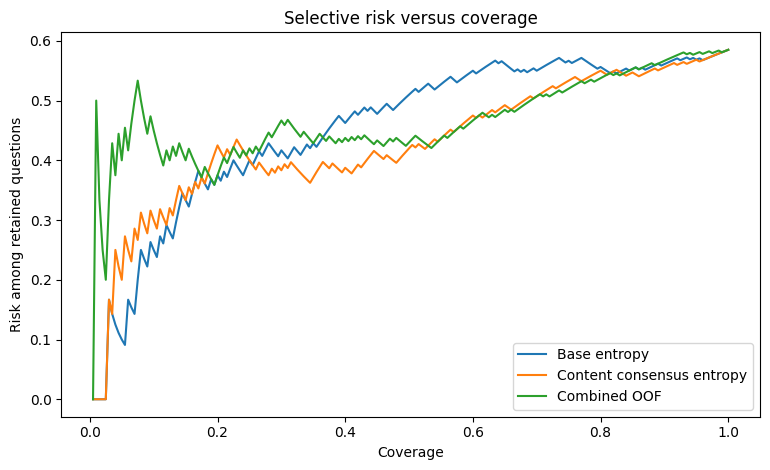

Block 8 complete.


In [ ]:
# =====================================================================
# BLOCK 8 — ERROR DETECTION AND SELECTIVE-RISK EVALUATION
# =====================================================================

def bootstrap_metric_ci(y_true, scores, metric_fn, n_boot=BOOTSTRAP_SAMPLES):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    rng = np.random.default_rng(SEED + 401)
    values = []

    for _ in range(n_boot):
        indices = rng.integers(
            0,
            len(y_true),
            size=len(y_true),
        )
        sampled_y = y_true[indices]

        if np.unique(sampled_y).size < 2:
            continue

        values.append(
            metric_fn(
                sampled_y,
                scores[indices],
            )
        )

    return (
        float(np.quantile(values, 0.025)),
        float(np.quantile(values, 0.975)),
    )

target = question_metrics_df["base_error"].astype(int).to_numpy()

uncertainty_signals = {
    "base_entropy": question_metrics_df["base_entropy"].to_numpy(),
    "negative_base_margin": -question_metrics_df["base_margin"].to_numpy(),
    "one_minus_base_max_probability": (
        1.0 - question_metrics_df["base_max_probability"].to_numpy()
    ),
    "content_consensus_entropy": (
        question_metrics_df["content_consensus_entropy"].to_numpy()
    ),
    "presentation_js": question_metrics_df["presentation_js"].to_numpy(),
    "binding_js": question_metrics_df["binding_js"].to_numpy(),
    "order_js": question_metrics_df["order_js"].to_numpy(),
    "one_minus_modal_consistency": (
        1.0 - question_metrics_df["modal_consistency"].to_numpy()
    ),
}

metric_rows = []

for signal_name, scores in uncertainty_signals.items():
    auroc = roc_auc_score(target, scores)
    auprc = average_precision_score(target, scores)

    auroc_lo, auroc_hi = bootstrap_metric_ci(
        target,
        scores,
        roc_auc_score,
    )
    auprc_lo, auprc_hi = bootstrap_metric_ci(
        target,
        scores,
        average_precision_score,
    )

    metric_rows.append(
        {
            "signal": signal_name,
            "auroc": float(auroc),
            "auroc_lo": auroc_lo,
            "auroc_hi": auroc_hi,
            "auprc": float(auprc),
            "auprc_lo": auprc_lo,
            "auprc_hi": auprc_hi,
        }
    )

# Cross-validated combined uncertainty model.
combined_features = question_metrics_df[
    [
        "base_entropy",
        "content_consensus_entropy",
        "presentation_js",
        "binding_js",
        "order_js",
        "modal_consistency",
        "label_disagreement_rate",
    ]
].copy()

combined_features["modal_consistency"] = (
    1.0 - combined_features["modal_consistency"]
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

combined_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED,
    ),
)

combined_oof_probability = cross_val_predict(
    combined_model,
    combined_features.to_numpy(),
    target,
    cv=cv,
    method="predict_proba",
)[:, 1]

combined_auroc = roc_auc_score(
    target,
    combined_oof_probability,
)
combined_auprc = average_precision_score(
    target,
    combined_oof_probability,
)

metric_rows.append(
    {
        "signal": "combined_cross_validated",
        "auroc": float(combined_auroc),
        "auroc_lo": np.nan,
        "auroc_hi": np.nan,
        "auprc": float(combined_auprc),
        "auprc_lo": np.nan,
        "auprc_hi": np.nan,
    }
)

uncertainty_evaluation_df = (
    pd.DataFrame(metric_rows)
    .sort_values("auroc", ascending=False)
    .reset_index(drop=True)
)

uncertainty_evaluation_df.to_csv(
    OUTPUT_DIR / "uncertainty_error_detection.csv",
    index=False,
)

question_metrics_df["combined_oof_error_probability"] = (
    combined_oof_probability
)
question_metrics_df.to_csv(
    OUTPUT_DIR / "question_uncertainty_decomposition.csv",
    index=False,
)

print(
    uncertainty_evaluation_df
    .round(4)
    .to_string(index=False)
)

def selective_risk_curve(errors, uncertainty):
    errors = np.asarray(errors, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)
    order = np.argsort(uncertainty)
    sorted_errors = errors[order]
    cumulative_errors = np.cumsum(sorted_errors)
    retained = np.arange(1, len(errors) + 1)
    coverage = retained / len(errors)
    risk = cumulative_errors / retained
    return coverage, risk

fig, ax = plt.subplots(figsize=(7.8, 4.8))

curve_signals = {
    "Base entropy": question_metrics_df["base_entropy"].to_numpy(),
    "Content consensus entropy": (
        question_metrics_df["content_consensus_entropy"].to_numpy()
    ),
    "Combined OOF": combined_oof_probability,
}

for name, scores in curve_signals.items():
    coverage, risk = selective_risk_curve(
        target,
        scores,
    )
    ax.plot(coverage, risk, label=name)

ax.set_xlabel("Coverage")
ax.set_ylabel("Risk among retained questions")
ax.set_title("Selective risk versus coverage")
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_selective_risk.png",
    dpi=180,
)
plt.show()

print("Block 8 complete.")


## Block 9 — Extract final-position residual states at selected layers

In [ ]:
# =====================================================================
# BLOCK 9 — RESIDUAL-STREAM EXTRACTION
# =====================================================================

activation_question_ids = (
    questions_df["question_id"]
    .iloc[:MAX_ACTIVATION_QUESTIONS]
    .astype(int)
    .tolist()
)

activation_index_df = (
    scored_df[
        scored_df["question_id"].isin(activation_question_ids)
    ]
    .sort_values("presentation_index")
    .reset_index(drop=True)
)

activation_prompts = activation_index_df["prompt"].tolist()

activation_chunks = {
    layer: []
    for layer in RESIDUAL_LAYERS
}

def make_residual_collector(layer):
    def collector(activation, hook):
        if activation.ndim != 3:
            raise RuntimeError(
                f"Residual hook at layer {layer} returned "
                f"shape {tuple(activation.shape)}."
            )

        activation_chunks[layer].append(
            activation[:, -1, :]
            .detach()
            .to(torch.float16)
            .cpu()
            .numpy()
        )
        return activation

    return collector

residual_hooks = [
    (
        RESIDUAL_HOOKS[layer],
        make_residual_collector(layer),
    )
    for layer in RESIDUAL_LAYERS
]

print(
    f"Extracting {len(activation_prompts)} presentations "
    f"at {len(RESIDUAL_LAYERS)} residual layers..."
)

with torch.inference_mode():
    for prompt_batch in tqdm(
        batched(activation_prompts, BATCH_SIZE),
        total=math.ceil(len(activation_prompts) / BATCH_SIZE),
        desc="Residual extraction",
    ):
        tokens, attention_mask = tokenize_prompts(prompt_batch)

        _ = model.run_with_hooks(
            tokens,
            attention_mask=attention_mask,
            fwd_hooks=residual_hooks,
            return_type=None,
            use_cache=False,
        )

        del tokens, attention_mask

residual_arrays = {
    layer: np.concatenate(
        activation_chunks[layer],
        axis=0,
    )
    for layer in RESIDUAL_LAYERS
}

for layer, array in residual_arrays.items():
    if array.shape != (
        len(activation_index_df),
        model.cfg.d_model,
    ):
        raise RuntimeError(
            f"Layer {layer} activation shape {array.shape} is incorrect."
        )

np.savez_compressed(
    OUTPUT_DIR / "residual_states_selected_layers.npz",
    **{
        f"layer_{layer}": array
        for layer, array in residual_arrays.items()
    },
)

activation_index_df[
    [
        "presentation_index",
        "question_id",
        "order_id",
        "label_system",
        "predicted_slot",
        "predicted_content_id",
        "view_correct",
    ]
].to_csv(
    OUTPUT_DIR / "residual_state_index.csv",
    index=False,
)

print(
    "Stored activation tensor shapes:",
    {
        layer: array.shape
        for layer, array in residual_arrays.items()
    },
)
print("Block 9 complete.")


Extracting 960 presentations at 11 residual layers...


Residual extraction:   0%|          | 0/480 [00:00<?, ?it/s]

Stored activation tensor shapes: {0: (960, 2048), 4: (960, 2048), 8: (960, 2048), 12: (960, 2048), 16: (960, 2048), 20: (960, 2048), 24: (960, 2048), 28: (960, 2048), 32: (960, 2048), 36: (960, 2048), 39: (960, 2048)}
Block 9 complete.


## Block 10 — Preliminary representational separation of selected content and output symbols

 layer  content_only_similarity  symbol_only_similarity  neither_similarity  content_alignment  symbol_alignment  content_alignment_questions  symbol_alignment_questions
     0                   0.9999                  0.9999              0.9999            -0.0000           -0.0000                           95                          95
     4                   0.9992                  0.9999              0.9991             0.0001            0.0008                           95                          95
     8                   0.9968                  0.9998              0.9965             0.0002            0.0033                           95                          95
    12                   0.9953                  0.9996              0.9949             0.0003            0.0047                           95                          95
    16                   0.9936                  0.9993              0.9931             0.0005            0.0063                           95         

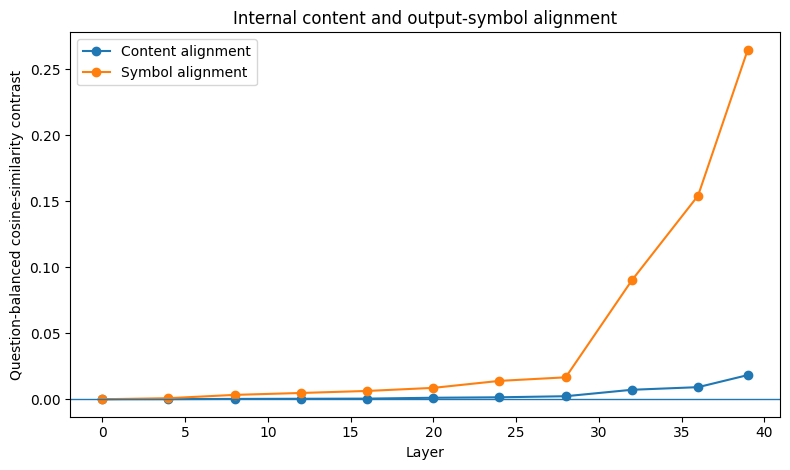

First ten substantive blocks complete.
Review the behavioural decomposition, uncertainty evaluation, and RSA trajectory before adding causal-intervention blocks.


In [ ]:
# =====================================================================
# BLOCK 10 — QUESTION-BALANCED REPRESENTATIONAL SIMILARITY ANALYSIS
# =====================================================================

# Pair categories within the same question:
#   content_only: same predicted content, different output symbol
#   symbol_only: same output symbol, different predicted content
#   neither: different content and different output symbol
#
# The actual output symbol is defined by (label system, output slot).
# This analysis is descriptive. It does not yet establish causality.

rsa_rows = []

for layer in RESIDUAL_LAYERS:
    states = residual_arrays[layer].astype(np.float32)
    norms = np.linalg.norm(
        states,
        axis=1,
        keepdims=True,
    )
    normalized_states = states / np.clip(
        norms,
        1e-12,
        None,
    )

    question_level_rows = []

    for question_id, positions in activation_index_df.groupby(
        "question_id"
    ).groups.items():
        positions = np.asarray(list(positions), dtype=int)
        metadata = activation_index_df.iloc[positions]
        question_states = normalized_states[positions]

        category_values = {
            "content_only": [],
            "symbol_only": [],
            "neither": [],
            "both": [],
        }

        for first, second in combinations(
            range(len(positions)),
            2,
        ):
            first_row = metadata.iloc[first]
            second_row = metadata.iloc[second]

            same_content = (
                int(first_row["predicted_content_id"])
                == int(second_row["predicted_content_id"])
            )

            first_symbol = (
                str(first_row["label_system"]),
                int(first_row["predicted_slot"]),
            )
            second_symbol = (
                str(second_row["label_system"]),
                int(second_row["predicted_slot"]),
            )
            same_symbol = first_symbol == second_symbol

            similarity = float(
                np.dot(
                    question_states[first],
                    question_states[second],
                )
            )

            if same_content and same_symbol:
                category = "both"
            elif same_content and not same_symbol:
                category = "content_only"
            elif same_symbol and not same_content:
                category = "symbol_only"
            else:
                category = "neither"

            category_values[category].append(similarity)

        question_level_rows.append(
            {
                "question_id": int(question_id),
                **{
                    category: (
                        float(np.mean(values))
                        if values
                        else np.nan
                    )
                    for category, values in category_values.items()
                },
            }
        )

    question_level_df = pd.DataFrame(question_level_rows)

    baseline = question_level_df["neither"]

    content_alignment = (
        question_level_df["content_only"] - baseline
    )
    symbol_alignment = (
        question_level_df["symbol_only"] - baseline
    )

    rsa_rows.append(
        {
            "layer": int(layer),
            "content_only_similarity": float(
                question_level_df["content_only"].mean()
            ),
            "symbol_only_similarity": float(
                question_level_df["symbol_only"].mean()
            ),
            "neither_similarity": float(
                question_level_df["neither"].mean()
            ),
            "content_alignment": float(
                content_alignment.mean()
            ),
            "symbol_alignment": float(
                symbol_alignment.mean()
            ),
            "content_alignment_questions": int(
                content_alignment.notna().sum()
            ),
            "symbol_alignment_questions": int(
                symbol_alignment.notna().sum()
            ),
        }
    )

rsa_trajectory_df = pd.DataFrame(rsa_rows)
rsa_trajectory_df.to_csv(
    OUTPUT_DIR / "content_symbol_rsa_trajectory.csv",
    index=False,
)

print(rsa_trajectory_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(
    rsa_trajectory_df["layer"],
    rsa_trajectory_df["content_alignment"],
    marker="o",
    label="Content alignment",
)
ax.plot(
    rsa_trajectory_df["layer"],
    rsa_trajectory_df["symbol_alignment"],
    marker="o",
    label="Symbol alignment",
)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("Layer")
ax.set_ylabel("Question-balanced cosine-similarity contrast")
ax.set_title("Internal content and output-symbol alignment")
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "figure_content_symbol_rsa.png",
    dpi=180,
)
plt.show()

save_json(
    {
        "completed_blocks": 10,
        "questions_behavioral": int(len(question_metrics_df)),
        "questions_activation": int(
            activation_index_df["question_id"].nunique()
        ),
        "presentations_activation": int(len(activation_index_df)),
        "residual_layers": RESIDUAL_LAYERS,
        "note": (
            "The first ten blocks end at descriptive internal separation. "
            "Causal interventions and cross-model replication are intentionally deferred."
        ),
    },
    "first_ten_blocks_summary.json",
)

print(
    "First ten substantive blocks complete.\n"
    "Review the behavioural decomposition, uncertainty evaluation, and RSA "
    "trajectory before adding causal-intervention blocks."
)


In [ ]:
# =====================================================================
# BLOCK 11 — COMPUTE-MATCHED PRESENTATION PANELS
# =====================================================================
# No new inference. Compares 1, 2, 4, and 8 presentations at equal cost.

from itertools import combinations

CONTENT_COLS = [f"content_probability_{i}" for i in range(4)]
LABEL_NAMES = list(LABEL_SYSTEMS.keys())
BASE_ERROR = (
    question_metrics_df.set_index("question_id")["base_error"]
    .astype(int)
    .to_dict()
)

PANELS = []


def add_panel(panel_id, design, keys):
    PANELS.append((panel_id, design, list(keys)))


# One-presentation baselines: all eight possible individual views.
for order_id in range(4):
    for label in LABEL_NAMES:
        add_panel(
            f"k1_o{order_id}_{label}",
            "single_view",
            [(order_id, label)],
        )

# Two presentations: same order, different label systems.
for order_id in range(4):
    add_panel(
        f"k2_label_o{order_id}",
        "label_variation",
        [(order_id, label) for label in LABEL_NAMES],
    )

# Two presentations: different orders, same label system.
for label in LABEL_NAMES:
    for order_pair in combinations(range(4), 2):
        add_panel(
            f"k2_order_{label}_{order_pair}",
            "order_variation",
            [(order_id, label) for order_id in order_pair],
        )

# Four presentations: all orders under one label system.
for label in LABEL_NAMES:
    add_panel(
        f"k4_order_{label}",
        "all_orders_one_label",
        [(order_id, label) for order_id in range(4)],
    )

# Four presentations: two orders crossed with two labels.
for order_pair in combinations(range(4), 2):
    add_panel(
        f"k4_balanced_{order_pair}",
        "two_orders_two_labels",
        [
            (order_id, label)
            for order_id in order_pair
            for label in LABEL_NAMES
        ],
    )

# Eight presentations: complete 4 × 2 factorial.
add_panel(
    "k8_full",
    "full_factorial",
    [
        (order_id, label)
        for order_id in range(4)
        for label in LABEL_NAMES
    ],
)


def panel_metrics(group, view_keys):
    wanted = set(view_keys)

    selected = group[
        [
            (int(row.order_id), str(row.label_system)) in wanted
            for row in group.itertuples(index=False)
        ]
    ]

    if len(selected) != len(view_keys):
        raise RuntimeError(
            f"Expected {len(view_keys)} views, found {len(selected)}."
        )

    probabilities = selected[CONTENT_COLS].to_numpy(dtype=float)
    consensus = probabilities.mean(axis=0)

    gold_content_id = int(
        selected["gold_content_id"].iloc[0]
    )

    prediction_counts = np.bincount(
        selected["predicted_content_id"].astype(int),
        minlength=4,
    )

    return {
        "panel_error": int(
            consensus.argmax() != gold_content_id
        ),
        "consensus_entropy": float(
            entropy_bits(consensus)
        ),
        "mean_view_entropy": float(
            selected["view_entropy_bits"].mean()
        ),
        "presentation_js": float(
            generalized_js_divergence(probabilities)
        ),
        "one_minus_modal_consistency": float(
            1.0
            - prediction_counts.max() / len(selected)
        ),
        "mean_view_accuracy": float(
            selected["view_correct"].mean()
        ),
    }


# ---------------------------------------------------------------------
# Construct all question × panel observations
# ---------------------------------------------------------------------

rows = []

for panel_id, design, view_keys in PANELS:
    for question_id, group in scored_df.groupby(
        "question_id",
        sort=False,
    ):
        rows.append(
            {
                "panel_id": panel_id,
                "design": design,
                "n_views": len(view_keys),
                "question_id": int(question_id),
                "fixed_base_error": BASE_ERROR[
                    int(question_id)
                ],
                **panel_metrics(group, view_keys),
            }
        )

compute_matched_question_df = pd.DataFrame(rows)


def safe_metric(y_true, scores, metric_fn):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    if (
        np.unique(y_true).size < 2
        or np.unique(scores).size < 2
    ):
        return np.nan

    return float(metric_fn(y_true, scores))


SIGNALS = [
    "consensus_entropy",
    "mean_view_entropy",
    "presentation_js",
    "one_minus_modal_consistency",
]

panel_rows = []
signal_rows = []

for panel_id, current_panel_df in (
    compute_matched_question_df.groupby(
        "panel_id",
        sort=False,
    )
):
    panel_rows.append(
        {
            "panel_id": panel_id,
            "design": current_panel_df[
                "design"
            ].iloc[0],
            "n_views": int(
                current_panel_df["n_views"].iloc[0]
            ),
            "consensus_accuracy": float(
                1.0
                - current_panel_df["panel_error"].mean()
            ),
            "mean_view_accuracy": float(
                current_panel_df[
                    "mean_view_accuracy"
                ].mean()
            ),
        }
    )

    # First target: error made by this panel's consensus.
    # Second target: error made by the original fixed base view.
    for target in [
        "panel_error",
        "fixed_base_error",
    ]:
        y_true = current_panel_df[target].to_numpy()

        for signal in SIGNALS:
            scores = current_panel_df[
                signal
            ].to_numpy()

            signal_rows.append(
                {
                    "panel_id": panel_id,
                    "design": current_panel_df[
                        "design"
                    ].iloc[0],
                    "n_views": int(
                        current_panel_df[
                            "n_views"
                        ].iloc[0]
                    ),
                    "target": target,
                    "signal": signal,
                    "auroc": safe_metric(
                        y_true,
                        scores,
                        roc_auc_score,
                    ),
                    "auprc": safe_metric(
                        y_true,
                        scores,
                        average_precision_score,
                    ),
                }
            )

panel_performance_df = pd.DataFrame(panel_rows)
panel_signal_df = pd.DataFrame(signal_rows)

accuracy_summary_df = (
    panel_performance_df
    .groupby(
        ["design", "n_views"],
        as_index=False,
    )
    .agg(
        panels=("panel_id", "nunique"),
        consensus_accuracy=(
            "consensus_accuracy",
            "mean",
        ),
        consensus_accuracy_sd=(
            "consensus_accuracy",
            "std",
        ),
        mean_view_accuracy=(
            "mean_view_accuracy",
            "mean",
        ),
    )
    .sort_values(["n_views", "design"])
)

signal_summary_df = (
    panel_signal_df
    .groupby(
        [
            "target",
            "design",
            "n_views",
            "signal",
        ],
        as_index=False,
    )
    .agg(
        panels=("panel_id", "nunique"),
        auroc=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        auprc=("auprc", "mean"),
    )
    .sort_values(
        [
            "target",
            "n_views",
            "design",
            "signal",
        ]
    )
)

compute_matched_question_df.to_pickle(
    OUTPUT_DIR
    / "block11_compute_matched_questions.pkl"
)

accuracy_summary_df.to_csv(
    OUTPUT_DIR
    / "block11_accuracy_summary.csv",
    index=False,
)

signal_summary_df.to_csv(
    OUTPUT_DIR
    / "block11_uncertainty_summary.csv",
    index=False,
)

print("\nCOMPUTE-MATCHED ACCURACY")
print(
    accuracy_summary_df
    .round(4)
    .to_string(index=False)
)

print("\nAUROC FOR EACH PANEL'S OWN ERROR")
print(
    signal_summary_df[
        signal_summary_df["target"]
        == "panel_error"
    ][
        [
            "design",
            "n_views",
            "signal",
            "auroc",
            "auroc_sd",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("Block 11 complete.")


COMPUTE-MATCHED ACCURACY
               design  n_views  panels  consensus_accuracy  consensus_accuracy_sd  mean_view_accuracy
          single_view        1       8              0.4175                 0.0110              0.4175
      label_variation        2       4              0.4150                 0.0141              0.4175
      order_variation        2      12              0.4454                 0.0222              0.4175
 all_orders_one_label        4       2              0.4800                 0.0000              0.4175
two_orders_two_labels        4       6              0.4533                 0.0147              0.4175
       full_factorial        8       1              0.4800                    NaN              0.4175

AUROC FOR EACH PANEL'S OWN ERROR
               design  n_views                      signal  auroc  auroc_sd
          single_view        1           consensus_entropy 0.6287    0.0287
          single_view        1           mean_view_entropy 0.6287    0.028

In [ ]:
# =====================================================================
# BLOCK 12 — ORDER / BINDING / INTERACTION DECOMPOSITION
# =====================================================================
# No new inference.
#
# Information:
#   total = Shapley order + Shapley binding
#
# Probability variation:
#   total = order + binding + order×binding interaction

CONTENT_COLS = [f"content_probability_{i}" for i in range(4)]
LABEL_NAMES = list(LABEL_SYSTEMS.keys())
EPS = 1e-12


def H(probabilities):
    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )
    probabilities = (
        probabilities / probabilities.sum()
    )

    return float(
        -np.sum(
            probabilities
            * np.log2(
                np.clip(
                    probabilities,
                    EPS,
                    1.0,
                )
            )
        )
    )


def decompose_question(question_id, group):
    indexed = group.set_index(
        ["order_id", "label_system"]
    )

    # Shape:
    # [four option orders, two label systems, four contents]
    probability_tensor = np.empty(
        (4, len(LABEL_NAMES), 4),
        dtype=float,
    )

    for order_id in range(4):
        for label_index, label in enumerate(
            LABEL_NAMES
        ):
            row = indexed.loc[
                (order_id, label)
            ]

            if isinstance(row, pd.DataFrame):
                raise RuntimeError(
                    f"Duplicate view for question "
                    f"{question_id}."
                )

            probability_tensor[
                order_id,
                label_index,
            ] = row[
                CONTENT_COLS
            ].to_numpy(dtype=float)

    if not np.allclose(
        probability_tensor.sum(axis=-1),
        1.0,
        atol=1e-5,
    ):
        raise RuntimeError(
            f"Invalid probabilities for question "
            f"{question_id}."
        )

    grand_mean = probability_tensor.mean(
        axis=(0, 1)
    )
    order_means = probability_tensor.mean(
        axis=1
    )
    label_means = probability_tensor.mean(
        axis=0
    )

    mean_view_entropy = np.mean(
        [
            H(
                probability_tensor[
                    order_id,
                    label_index,
                ]
            )
            for order_id in range(4)
            for label_index in range(
                len(LABEL_NAMES)
            )
        ]
    )

    mean_order_entropy = np.mean(
        [
            H(probabilities)
            for probabilities in order_means
        ]
    )

    mean_label_entropy = np.mean(
        [
            H(probabilities)
            for probabilities in label_means
        ]
    )

    grand_entropy = H(grand_mean)

    # ---------------------------------------------------------------
    # Information-theoretic quantities
    # ---------------------------------------------------------------

    total_information = (
        grand_entropy - mean_view_entropy
    )

    order_information = (
        grand_entropy - mean_order_entropy
    )

    binding_information = (
        grand_entropy - mean_label_entropy
    )

    binding_given_order = (
        mean_order_entropy
        - mean_view_entropy
    )

    order_given_binding = (
        mean_label_entropy
        - mean_view_entropy
    )

    # Symmetric Shapley allocation.
    shapley_order = 0.5 * (
        order_information
        + order_given_binding
    )

    shapley_binding = 0.5 * (
        binding_information
        + binding_given_order
    )

    # Positive values indicate synergy.
    # Negative values indicate redundancy.
    signed_interaction = (
        total_information
        - order_information
        - binding_information
    )

    # ---------------------------------------------------------------
    # Exact factorial probability-variation decomposition
    # ---------------------------------------------------------------

    order_effect = (
        order_means - grand_mean
    )

    binding_effect = (
        label_means - grand_mean
    )

    interaction_effect = (
        probability_tensor
        - grand_mean[None, None, :]
        - order_effect[:, None, :]
        - binding_effect[None, :, :]
    )

    total_variation = np.mean(
        np.sum(
            (
                probability_tensor
                - grand_mean[None, None, :]
            )
            ** 2,
            axis=-1,
        )
    )

    order_variation = np.mean(
        np.sum(
            order_effect ** 2,
            axis=-1,
        )
    )

    binding_variation = np.mean(
        np.sum(
            binding_effect ** 2,
            axis=-1,
        )
    )

    interaction_variation = np.mean(
        np.sum(
            interaction_effect ** 2,
            axis=-1,
        )
    )

    return {
        "question_id": int(question_id),
        "total_information_bits": float(
            total_information
        ),
        "shapley_order_bits": float(
            shapley_order
        ),
        "shapley_binding_bits": float(
            shapley_binding
        ),
        "signed_interaction_bits": float(
            signed_interaction
        ),
        "total_variation": float(
            total_variation
        ),
        "order_variation": float(
            order_variation
        ),
        "binding_variation": float(
            binding_variation
        ),
        "interaction_variation": float(
            interaction_variation
        ),
        "information_additivity_error": float(
            abs(
                total_information
                - shapley_order
                - shapley_binding
            )
        ),
        "variance_additivity_error": float(
            abs(
                total_variation
                - order_variation
                - binding_variation
                - interaction_variation
            )
        ),
    }


factor_decomposition_df = pd.DataFrame(
    [
        decompose_question(
            question_id,
            group,
        )
        for question_id, group in scored_df.groupby(
            "question_id",
            sort=False,
        )
    ]
).merge(
    question_metrics_df[
        [
            "question_id",
            "base_error",
            "consensus_error",
        ]
    ],
    on="question_id",
    how="left",
    validate="one_to_one",
)

if (
    factor_decomposition_df[
        "information_additivity_error"
    ].max()
    > 1e-7
):
    raise RuntimeError(
        "Information decomposition is not additive."
    )

if (
    factor_decomposition_df[
        "variance_additivity_error"
    ].max()
    > 1e-7
):
    raise RuntimeError(
        "Variance decomposition is not additive."
    )

# ---------------------------------------------------------------------
# Per-question component shares
# ---------------------------------------------------------------------

valid_information = (
    factor_decomposition_df[
        "total_information_bits"
    ]
    > EPS
)

valid_variation = (
    factor_decomposition_df[
        "total_variation"
    ]
    > EPS
)

factor_decomposition_df[
    "order_information_share"
] = np.where(
    valid_information,
    factor_decomposition_df[
        "shapley_order_bits"
    ]
    / factor_decomposition_df[
        "total_information_bits"
    ],
    np.nan,
)

factor_decomposition_df[
    "binding_information_share"
] = np.where(
    valid_information,
    factor_decomposition_df[
        "shapley_binding_bits"
    ]
    / factor_decomposition_df[
        "total_information_bits"
    ],
    np.nan,
)

for component in [
    "order",
    "binding",
    "interaction",
]:
    factor_decomposition_df[
        f"{component}_variation_share"
    ] = np.where(
        valid_variation,
        factor_decomposition_df[
            f"{component}_variation"
        ]
        / factor_decomposition_df[
            "total_variation"
        ],
        np.nan,
    )

# ---------------------------------------------------------------------
# Aggregate summaries
# ---------------------------------------------------------------------

summary_columns = [
    "total_information_bits",
    "shapley_order_bits",
    "shapley_binding_bits",
    "order_information_share",
    "binding_information_share",
    "signed_interaction_bits",
    "order_variation_share",
    "binding_variation_share",
    "interaction_variation_share",
]

factor_summary_df = (
    factor_decomposition_df[
        summary_columns
    ]
    .agg(["mean", "median", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "quantity"})
)

DECOMPOSED_SIGNALS = [
    "total_information_bits",
    "shapley_order_bits",
    "shapley_binding_bits",
    "total_variation",
    "order_variation",
    "binding_variation",
    "interaction_variation",
]

signal_rows = []

for target in [
    "base_error",
    "consensus_error",
]:
    y_true = (
        factor_decomposition_df[target]
        .astype(int)
        .to_numpy()
    )

    for signal in DECOMPOSED_SIGNALS:
        scores = factor_decomposition_df[
            signal
        ].to_numpy()

        signal_rows.append(
            {
                "target": target,
                "signal": signal,
                "auroc": safe_metric(
                    y_true,
                    scores,
                    roc_auc_score,
                ),
                "auprc": safe_metric(
                    y_true,
                    scores,
                    average_precision_score,
                ),
            }
        )

factor_error_signal_df = pd.DataFrame(
    signal_rows
)

factor_decomposition_df.to_csv(
    OUTPUT_DIR
    / "block12_factor_decomposition_questions.csv",
    index=False,
)

factor_summary_df.to_csv(
    OUTPUT_DIR
    / "block12_factor_decomposition_summary.csv",
    index=False,
)

factor_error_signal_df.to_csv(
    OUTPUT_DIR
    / "block12_factor_error_detection.csv",
    index=False,
)

print("\nFORMAL FACTOR DECOMPOSITION")
print(
    factor_summary_df
    .round(5)
    .to_string(index=False)
)

print("\nDECOMPOSED COMPONENTS AS ERROR SIGNALS")
print(
    factor_error_signal_df
    .round(4)
    .to_string(index=False)
)

print("Block 12 complete.")


FORMAL FACTOR DECOMPOSITION
                   quantity    mean  median     std
     total_information_bits 0.58216 0.50588 0.43425
         shapley_order_bits 0.51966 0.41032 0.42864
       shapley_binding_bits 0.06250 0.04478 0.06112
    order_information_share 0.83967 0.86962 0.12108
  binding_information_share 0.16033 0.13038 0.12108
    signed_interaction_bits 0.05536 0.03665 0.05808
      order_variation_share 0.73165 0.78478 0.21334
    binding_variation_share 0.07905 0.04438 0.08383
interaction_variation_share 0.18931 0.14398 0.16219

DECOMPOSED COMPONENTS AS ERROR SIGNALS
         target                 signal  auroc  auprc
     base_error total_information_bits 0.6516 0.7250
     base_error     shapley_order_bits 0.6458 0.7219
     base_error   shapley_binding_bits 0.5625 0.6482
     base_error        total_variation 0.6401 0.7183
     base_error        order_variation 0.6338 0.7136
     base_error      binding_variation 0.5817 0.6635
     base_error  interaction_variation 0

In [ ]:
# =====================================================================
# BLOCK 13 — OPTION-BOUNDARY RESIDUAL STATES
# =====================================================================
# One extra forward pass over the existing activation subset.
# Boundary locations come from tokenizer character offsets.

if not getattr(tokenizer, "is_fast", False):
    raise RuntimeError(
        "A fast tokenizer with offset mappings is required."
    )

LABEL_NAMES = list(LABEL_SYSTEMS)

question_text_lookup = (
    questions_df
    .set_index("question_id")["canonical_texts"]
    .to_dict()
)


def option_end_positions(prompt, ordered_texts, labels):
    """
    Locate the final token belonging to each rendered answer option.
    Uses character offsets rather than estimating token lengths.
    """
    encoded = tokenizer(
        prompt,
        add_special_tokens=False,
        return_offsets_mapping=True,
        return_attention_mask=False,
    )

    offsets = encoded["offset_mapping"]
    positions = []
    cursor = 0

    for label, text in zip(labels, ordered_texts):
        line = f"{label}. {text}"
        start = prompt.find(line, cursor)

        if start < 0:
            raise RuntimeError(
                f"Could not locate option line: {line!r}"
            )

        end = start + len(line)

        overlapping_tokens = [
            token_index
            for token_index, (token_start, token_end)
            in enumerate(offsets)
            if (token_start, token_end) != (0, 0)
            and token_start < end
            and token_end > start
        ]

        if not overlapping_tokens:
            raise RuntimeError(
                f"No token overlaps option line: {line!r}"
            )

        positions.append(max(overlapping_tokens))
        cursor = end

    if (
        positions != sorted(positions)
        or len(set(positions)) != 4
    ):
        raise RuntimeError(
            f"Invalid option-boundary positions: {positions}"
        )

    return encoded["input_ids"], positions


# ---------------------------------------------------------------------
# Recover unpadded option-boundary token positions
# ---------------------------------------------------------------------

position_rows = []

for row_id, row in activation_index_df.iterrows():
    canonical_texts = question_text_lookup[
        int(row["question_id"])
    ]

    ordered_texts = [
        canonical_texts[int(content_id)]
        for content_id in row["slot_to_content"]
    ]

    labels = LABEL_SYSTEMS[
        str(row["label_system"])
    ]

    input_ids, positions = option_end_positions(
        row["prompt"],
        ordered_texts,
        labels,
    )

    independently_encoded = tokenizer.encode(
        row["prompt"],
        add_special_tokens=False,
    )

    if input_ids != independently_encoded:
        raise RuntimeError(
            f"Tokenizer mismatch at activation row {row_id}."
        )

    position_rows.append(
        {
            "activation_row": int(row_id),
            "question_id": int(row["question_id"]),
            "unpadded_length": int(len(input_ids)),
            **{
                f"option_end_{slot}": int(
                    positions[slot]
                )
                for slot in range(4)
            },
        }
    )

option_position_df = pd.DataFrame(position_rows)

if not np.array_equal(
    option_position_df[
        "activation_row"
    ].to_numpy(),
    np.arange(len(activation_index_df)),
):
    raise RuntimeError(
        "Position rows are not aligned with activation_index_df."
    )

print(
    "Recovered option boundaries for",
    len(option_position_df),
    "presentations.",
)

print(
    "Prompt token-length range:",
    int(
        option_position_df[
            "unpadded_length"
        ].min()
    ),
    "to",
    int(
        option_position_df[
            "unpadded_length"
        ].max()
    ),
)


# ---------------------------------------------------------------------
# Extract residual states at the four option boundaries
# ---------------------------------------------------------------------

boundary_chunks = {
    layer: []
    for layer in RESIDUAL_LAYERS
}


def make_boundary_hook(layer, padded_positions):
    def boundary_hook(activation, hook):
        if activation.ndim != 3:
            raise RuntimeError(
                f"Layer {layer} returned shape "
                f"{tuple(activation.shape)}."
            )

        batch_indices = torch.arange(
            activation.shape[0],
            device=activation.device,
        )[:, None]

        boundary_states = activation[
            batch_indices,
            padded_positions,
            :,
        ]

        boundary_chunks[layer].append(
            boundary_states
            .detach()
            .to(torch.float16)
            .cpu()
            .numpy()
        )

        return activation

    return boundary_hook


for batch_start in tqdm(
    range(
        0,
        len(activation_index_df),
        BATCH_SIZE,
    ),
    desc="Option-boundary extraction",
):
    batch_stop = min(
        batch_start + BATCH_SIZE,
        len(activation_index_df),
    )

    batch_rows = activation_index_df.iloc[
        batch_start:batch_stop
    ]

    batch_position_rows = option_position_df.iloc[
        batch_start:batch_stop
    ]

    tokens, attention_mask = tokenize_prompts(
        batch_rows["prompt"].tolist()
    )

    actual_lengths = (
        attention_mask
        .sum(dim=1)
        .cpu()
        .numpy()
        .astype(int)
    )

    expected_lengths = batch_position_rows[
        "unpadded_length"
    ].to_numpy(dtype=int)

    if not np.array_equal(
        actual_lengths,
        expected_lengths,
    ):
        raise RuntimeError(
            f"Token-length mismatch in rows "
            f"{batch_start}:{batch_stop}."
        )

    left_padding = (
        tokens.shape[1] - actual_lengths
    )

    unpadded_positions = batch_position_rows[
        [
            f"option_end_{slot}"
            for slot in range(4)
        ]
    ].to_numpy(dtype=int)

    padded_positions_array = (
        unpadded_positions
        + left_padding[:, None]
    )

    if (
        padded_positions_array.min() < 0
        or padded_positions_array.max()
        >= tokens.shape[1]
    ):
        raise RuntimeError(
            f"Invalid padded positions in rows "
            f"{batch_start}:{batch_stop}."
        )

    padded_positions = torch.tensor(
        padded_positions_array,
        dtype=torch.long,
        device=DEVICE,
    )

    forward_hooks = [
        (
            RESIDUAL_HOOKS[layer],
            make_boundary_hook(
                layer,
                padded_positions,
            ),
        )
        for layer in RESIDUAL_LAYERS
    ]

    with torch.inference_mode():
        model.run_with_hooks(
            tokens,
            attention_mask=attention_mask,
            fwd_hooks=forward_hooks,
            return_type=None,
            use_cache=False,
        )

    del tokens
    del attention_mask
    del padded_positions


boundary_state_arrays = {
    layer: np.concatenate(
        boundary_chunks[layer],
        axis=0,
    )
    for layer in RESIDUAL_LAYERS
}

expected_boundary_shape = (
    len(activation_index_df),
    4,
    model.cfg.d_model,
)

for layer, array in boundary_state_arrays.items():
    if array.shape != expected_boundary_shape:
        raise RuntimeError(
            f"Layer {layer}: shape {array.shape}; "
            f"expected {expected_boundary_shape}."
        )


# ---------------------------------------------------------------------
# Metadata aligned with the flattened boundary arrays
# ---------------------------------------------------------------------

boundary_metadata_rows = []

for presentation_row, row in (
    activation_index_df.iterrows()
):
    for option_slot in range(4):
        content_id = int(
            row["slot_to_content"][option_slot]
        )

        boundary_metadata_rows.append(
            {
                "boundary_row": int(
                    presentation_row * 4
                    + option_slot
                ),
                "presentation_row": int(
                    presentation_row
                ),
                "presentation_index": int(
                    row["presentation_index"]
                ),
                "question_id": int(
                    row["question_id"]
                ),
                "order_id": int(
                    row["order_id"]
                ),
                "label_system": str(
                    row["label_system"]
                ),
                "option_slot": int(
                    option_slot
                ),
                "content_id": content_id,
                "is_model_winner": int(
                    content_id
                    == int(
                        row[
                            "predicted_content_id"
                        ]
                    )
                ),
                "is_gold_content": int(
                    content_id
                    == int(
                        row["gold_content_id"]
                    )
                ),
            }
        )

boundary_metadata_df = pd.DataFrame(
    boundary_metadata_rows
)

if (
    boundary_metadata_df[
        "is_model_winner"
    ].sum()
    != len(activation_index_df)
):
    raise RuntimeError(
        "Each presentation must have exactly "
        "one model-winner option."
    )


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

np.savez_compressed(
    OUTPUT_DIR
    / "block13_option_boundary_states.npz",
    **{
        f"layer_{layer}": array
        for layer, array
        in boundary_state_arrays.items()
    },
)

option_position_df.to_csv(
    OUTPUT_DIR
    / "block13_option_positions.csv",
    index=False,
)

boundary_metadata_df.to_csv(
    OUTPUT_DIR
    / "block13_boundary_metadata.csv",
    index=False,
)

print(
    "Boundary-state shape per layer:",
    expected_boundary_shape,
)
print("Residual layers:", RESIDUAL_LAYERS)
print("Block 13 complete.")

Recovered option boundaries for 960 presentations.
Prompt token-length range: 117 to 581


Option-boundary extraction:   0%|          | 0/480 [00:00<?, ?it/s]

Boundary-state shape per layer: (960, 4, 2048)
Residual layers: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 39]
Block 13 complete.


Metadata-only winner AUROC: 0.6406

QUESTION-GROUPED PROBE TRAJECTORY
 layer  metadata_only_winner_auroc  relative_winner_auroc  winner_ci_low  winner_ci_high  boundary_slot_balanced_accuracy  answer_slot_balanced_accuracy  answer_slot_ci_low  answer_slot_ci_high
     0                      0.6406                 0.5760         0.5282          0.6203                           0.5224                         0.2648              0.2296               0.2987
     4                      0.6406                 0.5617         0.5148          0.6092                           0.5341                         0.2770              0.2422               0.3063
     8                      0.6406                 0.5844         0.5317          0.6404                           0.5701                         0.2812              0.2498               0.3119
    12                      0.6406                 0.5340         0.4882          0.5800                           0.7383                         0.2602  

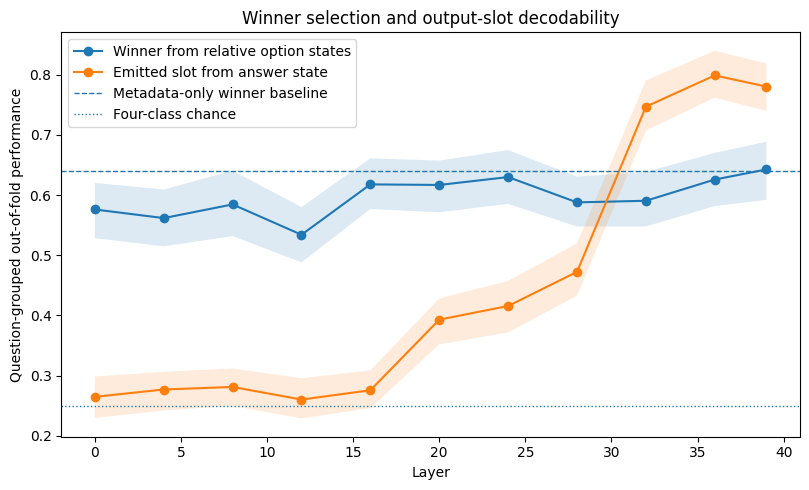

Peak winner probe: layer 39, AUROC=0.6425
Peak answer-slot probe: layer 36, balanced accuracy=0.7987
Block 14 complete.


In [ ]:
# =====================================================================
# BLOCK 14 — QUESTION-GROUPED WINNER AND OUTPUT-SLOT PROBES
# =====================================================================
# All presentations of one question remain in the same fold.
#
# Main measurements:
# 1. Can relative option-boundary states identify the model's winner?
# 2. How strongly do option-boundary states encode option position?
# 3. When does the final answer state encode the emitted output slot?

from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import (
    StratifiedGroupKFold,
)


def grouped_probe(
    features,
    targets,
    groups,
    alpha=10.0,
):
    X = np.asarray(
        features,
        dtype=np.float32,
    )
    y = np.asarray(targets)
    groups = np.asarray(groups)

    classes = np.unique(y)

    groups_per_class = [
        len(
            np.unique(
                groups[y == class_value]
            )
        )
        for class_value in classes
    ]

    n_splits = min(
        5,
        min(groups_per_class),
    )

    if n_splits < 3:
        raise RuntimeError(
            "Fewer than three grouped folds "
            "are possible."
        )

    cross_validator = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED,
    )

    predictions = np.empty(
        len(y),
        dtype=y.dtype,
    )

    fold_ids = np.full(
        len(y),
        -1,
        dtype=int,
    )

    binary_scores = (
        np.empty(
            len(y),
            dtype=float,
        )
        if len(classes) == 2
        else None
    )

    for fold, (
        training_indices,
        testing_indices,
    ) in enumerate(
        cross_validator.split(
            X,
            y,
            groups,
        )
    ):
        probe = make_pipeline(
            StandardScaler(),
            RidgeClassifier(
                alpha=alpha,
                class_weight="balanced",
                solver="lsqr",
            ),
        )

        probe.fit(
            X[training_indices],
            y[training_indices],
        )

        predictions[
            testing_indices
        ] = probe.predict(
            X[testing_indices]
        )

        fold_ids[
            testing_indices
        ] = fold

        if binary_scores is not None:
            binary_scores[
                testing_indices
            ] = probe.decision_function(
                X[testing_indices]
            )

    if (fold_ids < 0).any():
        raise RuntimeError(
            "Some observations received no "
            "out-of-fold prediction."
        )

    return {
        "predictions": predictions,
        "binary_scores": binary_scores,
        "fold_ids": fold_ids,
        "n_splits": int(n_splits),
    }


def grouped_bootstrap_ci(
    targets,
    predictions_or_scores,
    groups,
    metric,
    samples=500,
    salt=0,
):
    y = np.asarray(targets)
    values = np.asarray(
        predictions_or_scores
    )
    groups = np.asarray(groups)

    required_class_count = len(
        np.unique(y)
    )

    unique_groups = np.unique(groups)

    rows_by_group = {
        group: np.flatnonzero(
            groups == group
        )
        for group in unique_groups
    }

    rng = np.random.default_rng(
        SEED + 1400 + salt
    )

    bootstrap_values = []

    for _ in range(samples):
        sampled_groups = rng.choice(
            unique_groups,
            size=len(unique_groups),
            replace=True,
        )

        sampled_rows = np.concatenate(
            [
                rows_by_group[group]
                for group in sampled_groups
            ]
        )

        sampled_targets = y[
            sampled_rows
        ]

        if (
            len(np.unique(sampled_targets))
            != required_class_count
        ):
            continue

        bootstrap_values.append(
            metric(
                sampled_targets,
                values[sampled_rows],
            )
        )

    if not bootstrap_values:
        return np.nan, np.nan

    return (
        float(
            np.quantile(
                bootstrap_values,
                0.025,
            )
        ),
        float(
            np.quantile(
                bootstrap_values,
                0.975,
            )
        ),
    )


# ---------------------------------------------------------------------
# Targets and question groups
# ---------------------------------------------------------------------

winner_targets = boundary_metadata_df[
    "is_model_winner"
].to_numpy(dtype=int)

boundary_groups = boundary_metadata_df[
    "question_id"
].to_numpy(dtype=int)

boundary_slot_targets = (
    boundary_metadata_df[
        "option_slot"
    ].to_numpy(dtype=int)
)

answer_slot_targets = (
    activation_index_df[
        "predicted_slot"
    ].to_numpy(dtype=int)
)

answer_groups = activation_index_df[
    "question_id"
].to_numpy(dtype=int)


# ---------------------------------------------------------------------
# Metadata-only winner control
# ---------------------------------------------------------------------
# Tests whether winner prediction can be explained merely by slot,
# order, or label-system bias.

metadata_features = pd.get_dummies(
    boundary_metadata_df[
        [
            "option_slot",
            "order_id",
            "label_system",
        ]
    ].astype("category"),
    drop_first=False,
).to_numpy(dtype=np.float32)

metadata_probe = grouped_probe(
    metadata_features,
    winner_targets,
    boundary_groups,
)

metadata_winner_auroc = roc_auc_score(
    winner_targets,
    metadata_probe[
        "binary_scores"
    ],
)

print(
    "Metadata-only winner AUROC:",
    round(
        float(
            metadata_winner_auroc
        ),
        4,
    ),
)


# ---------------------------------------------------------------------
# Layerwise grouped probes
# ---------------------------------------------------------------------

trajectory_rows = []

boundary_oof_df = boundary_metadata_df[
    [
        "boundary_row",
        "presentation_row",
        "question_id",
        "option_slot",
        "is_model_winner",
    ]
].copy()

answer_oof_df = activation_index_df[
    [
        "presentation_index",
        "question_id",
        "label_system",
        "predicted_slot",
    ]
].copy()


for layer_number, layer in enumerate(
    RESIDUAL_LAYERS
):
    boundary_tensor = (
        boundary_state_arrays[layer]
        .astype(np.float32)
    )

    # Subtract the mean of the four option states
    # within each presentation. This isolates each
    # option's relative state from the shared prompt.
    relative_boundary_features = (
        boundary_tensor
        - boundary_tensor.mean(
            axis=1,
            keepdims=True,
        )
    ).reshape(
        -1,
        model.cfg.d_model,
    )

    # Existing Block 9 answer-position states.
    answer_features = (
        residual_arrays[layer]
        .astype(np.float32)
    )

    winner_probe = grouped_probe(
        relative_boundary_features,
        winner_targets,
        boundary_groups,
    )

    boundary_slot_probe = grouped_probe(
        relative_boundary_features,
        boundary_slot_targets,
        boundary_groups,
    )

    answer_slot_probe = grouped_probe(
        answer_features,
        answer_slot_targets,
        answer_groups,
    )

    winner_auroc = roc_auc_score(
        winner_targets,
        winner_probe[
            "binary_scores"
        ],
    )

    boundary_slot_accuracy = (
        balanced_accuracy_score(
            boundary_slot_targets,
            boundary_slot_probe[
                "predictions"
            ],
        )
    )

    answer_slot_accuracy = (
        balanced_accuracy_score(
            answer_slot_targets,
            answer_slot_probe[
                "predictions"
            ],
        )
    )

    winner_ci_low, winner_ci_high = (
        grouped_bootstrap_ci(
            winner_targets,
            winner_probe[
                "binary_scores"
            ],
            boundary_groups,
            roc_auc_score,
            salt=layer_number,
        )
    )

    answer_ci_low, answer_ci_high = (
        grouped_bootstrap_ci(
            answer_slot_targets,
            answer_slot_probe[
                "predictions"
            ],
            answer_groups,
            balanced_accuracy_score,
            salt=100 + layer_number,
        )
    )

    trajectory_rows.append(
        {
            "layer": int(layer),
            "metadata_only_winner_auroc": float(
                metadata_winner_auroc
            ),
            "relative_winner_auroc": float(
                winner_auroc
            ),
            "winner_ci_low": float(
                winner_ci_low
            ),
            "winner_ci_high": float(
                winner_ci_high
            ),
            "boundary_slot_balanced_accuracy": float(
                boundary_slot_accuracy
            ),
            "answer_slot_balanced_accuracy": float(
                answer_slot_accuracy
            ),
            "answer_slot_ci_low": float(
                answer_ci_low
            ),
            "answer_slot_ci_high": float(
                answer_ci_high
            ),
        }
    )

    boundary_oof_df[
        f"winner_score_L{layer}"
    ] = winner_probe[
        "binary_scores"
    ]

    boundary_oof_df[
        f"winner_fold_L{layer}"
    ] = winner_probe[
        "fold_ids"
    ]

    boundary_oof_df[
        f"slot_prediction_L{layer}"
    ] = boundary_slot_probe[
        "predictions"
    ]

    answer_oof_df[
        f"slot_prediction_L{layer}"
    ] = answer_slot_probe[
        "predictions"
    ]

    answer_oof_df[
        f"slot_fold_L{layer}"
    ] = answer_slot_probe[
        "fold_ids"
    ]


probe_trajectory_df = pd.DataFrame(
    trajectory_rows
)


# ---------------------------------------------------------------------
# Save results
# ---------------------------------------------------------------------

probe_trajectory_df.to_csv(
    OUTPUT_DIR
    / "block14_probe_trajectory.csv",
    index=False,
)

boundary_oof_df.to_csv(
    OUTPUT_DIR
    / "block14_boundary_oof.csv",
    index=False,
)

answer_oof_df.to_csv(
    OUTPUT_DIR
    / "block14_answer_oof.csv",
    index=False,
)


# ---------------------------------------------------------------------
# Display trajectory
# ---------------------------------------------------------------------

print("\nQUESTION-GROUPED PROBE TRAJECTORY")

print(
    probe_trajectory_df
    .round(4)
    .to_string(index=False)
)

fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

ax.plot(
    probe_trajectory_df["layer"],
    probe_trajectory_df[
        "relative_winner_auroc"
    ],
    marker="o",
    label=(
        "Winner from relative "
        "option states"
    ),
)

ax.fill_between(
    probe_trajectory_df["layer"],
    probe_trajectory_df[
        "winner_ci_low"
    ],
    probe_trajectory_df[
        "winner_ci_high"
    ],
    alpha=0.15,
)

ax.plot(
    probe_trajectory_df["layer"],
    probe_trajectory_df[
        "answer_slot_balanced_accuracy"
    ],
    marker="o",
    label=(
        "Emitted slot from "
        "answer state"
    ),
)

ax.fill_between(
    probe_trajectory_df["layer"],
    probe_trajectory_df[
        "answer_slot_ci_low"
    ],
    probe_trajectory_df[
        "answer_slot_ci_high"
    ],
    alpha=0.15,
)

ax.axhline(
    metadata_winner_auroc,
    linestyle="--",
    linewidth=1,
    label=(
        "Metadata-only "
        "winner baseline"
    ),
)

ax.axhline(
    0.25,
    linestyle=":",
    linewidth=1,
    label="Four-class chance",
)

ax.set_xlabel("Layer")
ax.set_ylabel(
    "Question-grouped "
    "out-of-fold performance"
)
ax.set_title(
    "Winner selection and "
    "output-slot decodability"
)
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "figure_block14_probe_trajectory.png",
    dpi=180,
)

plt.show()


best_winner = probe_trajectory_df.loc[
    probe_trajectory_df[
        "relative_winner_auroc"
    ].idxmax()
]

best_answer = probe_trajectory_df.loc[
    probe_trajectory_df[
        "answer_slot_balanced_accuracy"
    ].idxmax()
]

print(
    f"Peak winner probe: "
    f"layer {int(best_winner['layer'])}, "
    f"AUROC="
    f"{best_winner['relative_winner_auroc']:.4f}"
)

print(
    f"Peak answer-slot probe: "
    f"layer {int(best_answer['layer'])}, "
    f"balanced accuracy="
    f"{best_answer['answer_slot_balanced_accuracy']:.4f}"
)

print("Block 14 complete.")


INCREMENTAL WINNER INFORMATION
 layer  metadata_auroc  state_only_auroc  combined_auroc  state_minus_metadata  state_delta_ci_low  state_delta_ci_high  combined_minus_metadata  combined_delta_ci_low  combined_delta_ci_high  bootstrap_probability_positive  incremental_go
     0          0.6406            0.5760          0.5921               -0.0646             -0.1202              -0.0108                  -0.0485                -0.0971                  0.0069                           0.045           False
     4          0.6406            0.5617          0.5619               -0.0789             -0.1351              -0.0228                  -0.0787                -0.1389                 -0.0164                           0.005           False
     8          0.6406            0.5844          0.5869               -0.0562             -0.1107               0.0057                  -0.0537                -0.1152                  0.0077                           0.050           False
    12  

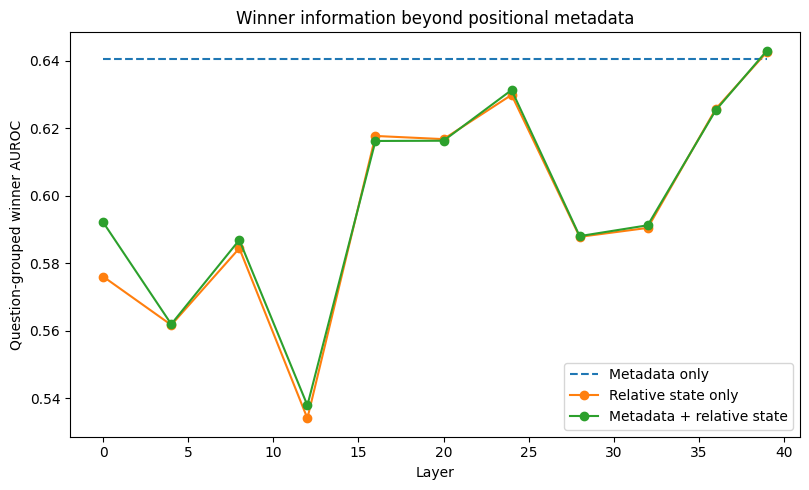

Best layer 39: delta AUROC=0.0023, 95% CI [-0.0491, 0.0538]
BLOCK 15 NO-GO: no clear incremental winner information beyond metadata.
Block 15 complete.


In [ ]:
# =====================================================================
# BLOCK 15 — WINNER INFORMATION BEYOND POSITION/ORDER METADATA
# =====================================================================
# CPU only. Tests whether option-boundary states add winner information
# beyond slot, order, and label-system metadata.

N_BOOT_15 = 1000


def grouped_auc_delta_ci(
    y,
    score_a,
    score_b,
    groups,
    n_boot=N_BOOT_15,
    salt=0,
):
    y = np.asarray(y, dtype=int)
    score_a = np.asarray(score_a, dtype=float)
    score_b = np.asarray(score_b, dtype=float)
    groups = np.asarray(groups)

    unique_groups = np.unique(groups)
    rows = {
        group: np.flatnonzero(groups == group)
        for group in unique_groups
    }

    observed = float(
        roc_auc_score(y, score_a)
        - roc_auc_score(y, score_b)
    )

    rng = np.random.default_rng(
        SEED + 1500 + salt
    )
    deltas = []

    for _ in range(n_boot):
        sampled_groups = rng.choice(
            unique_groups,
            len(unique_groups),
            replace=True,
        )

        sampled_rows = np.concatenate(
            [rows[group] for group in sampled_groups]
        )

        sampled_y = y[sampled_rows]

        if np.unique(sampled_y).size < 2:
            continue

        deltas.append(
            roc_auc_score(
                sampled_y,
                score_a[sampled_rows],
            )
            - roc_auc_score(
                sampled_y,
                score_b[sampled_rows],
            )
        )

    if not deltas:
        return observed, np.nan, np.nan, np.nan

    deltas = np.asarray(deltas)

    return (
        observed,
        float(np.quantile(deltas, 0.025)),
        float(np.quantile(deltas, 0.975)),
        float(np.mean(deltas > 0)),
    )


# Recreate only when Block 14 variables are unavailable.
if "winner_targets" not in globals():
    winner_targets = boundary_metadata_df[
        "is_model_winner"
    ].to_numpy(dtype=int)

if "boundary_groups" not in globals():
    boundary_groups = boundary_metadata_df[
        "question_id"
    ].to_numpy(dtype=int)

if "metadata_features" not in globals():
    metadata_features = pd.get_dummies(
        boundary_metadata_df[
            [
                "option_slot",
                "order_id",
                "label_system",
            ]
        ].astype("category"),
        drop_first=False,
    ).to_numpy(dtype=np.float32)

if "metadata_probe" not in globals():
    metadata_probe = grouped_probe(
        metadata_features,
        winner_targets,
        boundary_groups,
    )

metadata_scores = np.asarray(
    metadata_probe["binary_scores"],
    dtype=float,
)

metadata_auroc = float(
    roc_auc_score(
        winner_targets,
        metadata_scores,
    )
)

rows = []

oof_df = boundary_metadata_df[
    [
        "boundary_row",
        "presentation_row",
        "question_id",
        "option_slot",
        "order_id",
        "label_system",
        "is_model_winner",
    ]
].copy()

oof_df["metadata_score"] = metadata_scores


for layer_i, layer in enumerate(
    RESIDUAL_LAYERS
):
    states = boundary_state_arrays[
        layer
    ].astype(np.float32)

    relative_states = (
        states
        - states.mean(
            axis=1,
            keepdims=True,
        )
    ).reshape(
        -1,
        model.cfg.d_model,
    )

    state_column = f"winner_score_L{layer}"

    if (
        "boundary_oof_df" in globals()
        and state_column
        in boundary_oof_df.columns
    ):
        state_scores = boundary_oof_df[
            state_column
        ].to_numpy(dtype=float)
    else:
        state_scores = grouped_probe(
            relative_states,
            winner_targets,
            boundary_groups,
        )["binary_scores"]

    combined_features = np.concatenate(
        [
            metadata_features,
            relative_states,
        ],
        axis=1,
    )

    combined_scores = grouped_probe(
        combined_features,
        winner_targets,
        boundary_groups,
    )["binary_scores"]

    state_auroc = float(
        roc_auc_score(
            winner_targets,
            state_scores,
        )
    )

    combined_auroc = float(
        roc_auc_score(
            winner_targets,
            combined_scores,
        )
    )

    (
        state_delta,
        state_lo,
        state_hi,
        _,
    ) = grouped_auc_delta_ci(
        winner_targets,
        state_scores,
        metadata_scores,
        boundary_groups,
        salt=100 + layer_i,
    )

    (
        combined_delta,
        combined_lo,
        combined_hi,
        probability_positive,
    ) = grouped_auc_delta_ci(
        winner_targets,
        combined_scores,
        metadata_scores,
        boundary_groups,
        salt=layer_i,
    )

    rows.append(
        {
            "layer": int(layer),
            "metadata_auroc": metadata_auroc,
            "state_only_auroc": state_auroc,
            "combined_auroc": combined_auroc,
            "state_minus_metadata": float(
                state_delta
            ),
            "state_delta_ci_low": float(
                state_lo
            ),
            "state_delta_ci_high": float(
                state_hi
            ),
            "combined_minus_metadata": float(
                combined_delta
            ),
            "combined_delta_ci_low": float(
                combined_lo
            ),
            "combined_delta_ci_high": float(
                combined_hi
            ),
            "bootstrap_probability_positive": float(
                probability_positive
            ),
        }
    )

    oof_df[
        f"state_score_L{layer}"
    ] = state_scores

    oof_df[
        f"combined_score_L{layer}"
    ] = combined_scores


incremental_winner_df = pd.DataFrame(
    rows
)

incremental_winner_df[
    "incremental_go"
] = (
    (
        incremental_winner_df[
            "combined_delta_ci_low"
        ]
        > 0
    )
    & (
        incremental_winner_df[
            "combined_minus_metadata"
        ]
        >= 0.02
    )
)

incremental_winner_df.to_csv(
    OUTPUT_DIR
    / "block15_incremental_winner_information.csv",
    index=False,
)

oof_df.to_csv(
    OUTPUT_DIR
    / "block15_incremental_winner_oof.csv",
    index=False,
)

print("\nINCREMENTAL WINNER INFORMATION")

print(
    incremental_winner_df
    .round(4)
    .to_string(index=False)
)

fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

ax.plot(
    incremental_winner_df["layer"],
    incremental_winner_df[
        "metadata_auroc"
    ],
    linestyle="--",
    label="Metadata only",
)

ax.plot(
    incremental_winner_df["layer"],
    incremental_winner_df[
        "state_only_auroc"
    ],
    marker="o",
    label="Relative state only",
)

ax.plot(
    incremental_winner_df["layer"],
    incremental_winner_df[
        "combined_auroc"
    ],
    marker="o",
    label="Metadata + relative state",
)

ax.set_xlabel("Layer")
ax.set_ylabel(
    "Question-grouped winner AUROC"
)
ax.set_title(
    "Winner information beyond positional metadata"
)
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "figure_block15_incremental_winner.png",
    dpi=180,
)

plt.show()

best = incremental_winner_df.loc[
    incremental_winner_df[
        "combined_minus_metadata"
    ].idxmax()
]

print(
    f"Best layer {int(best['layer'])}: "
    f"delta AUROC="
    f"{best['combined_minus_metadata']:.4f}, "
    f"95% CI "
    f"[{best['combined_delta_ci_low']:.4f}, "
    f"{best['combined_delta_ci_high']:.4f}]"
)

if incremental_winner_df[
    "incremental_go"
].any():
    print(
        "BLOCK 15 GO: state adds meaningful "
        "winner information beyond metadata."
    )
else:
    print(
        "BLOCK 15 NO-GO: no clear incremental "
        "winner information beyond metadata."
    )

print("Block 15 complete.")

Patch pairs: 960
Pure-binding pairs: 448
Three-way conflict pairs: 222

IDENTITY-PATCH CHECK
 layer  identity_patch_accuracy
    24                      1.0
    28                      1.0
    32                      1.0
    36                      1.0


Cross-order patch layers:   0%|          | 0/4 [00:00<?, ?it/s]


CROSS-ORDER CAUSAL PATCHING
 layer  all_change_rate  all_source_slot_transfer  all_source_content_transfer  pure_binding_pairs  pure_binding_slot_transfer  pure_binding_content_preservation  pure_binding_slot_minus_content  pure_binding_diff_ci_low  pure_binding_diff_ci_high  three_way_conflict_pairs  conflict_slot_transfer  conflict_content_transfer  conflict_slot_minus_content  conflict_diff_ci_low  conflict_diff_ci_high
    24           0.0698                    0.3021                       0.4771                 448                      0.0134                             0.9621                          -0.9487                   -0.9754                    -0.9132                       222                  0.0541                     0.0631                      -0.0090               -0.0529                 0.0365
    28           0.1469                    0.3562                       0.4448                 448                      0.1004                             0.8638            

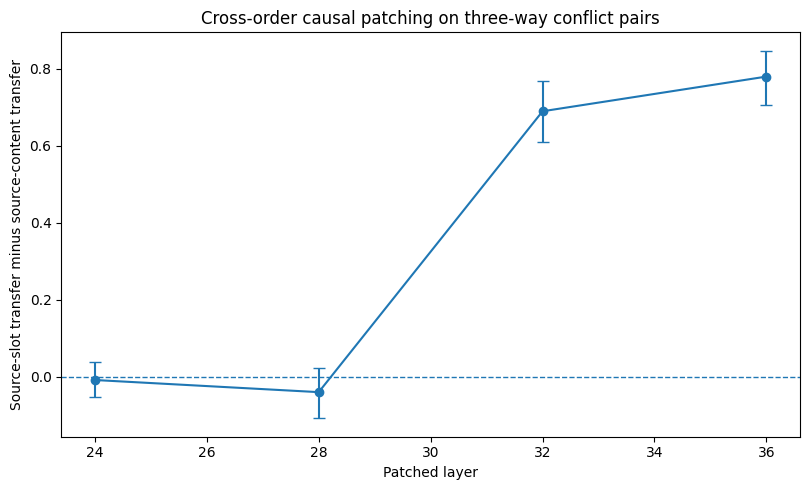

BLOCK 16: late answer states causally favor output-slot transfer.
Block 16 complete.


In [ ]:
# =====================================================================
# BLOCK 16 — CROSS-ORDER CAUSAL PATCHING AT THE ANSWER POSITION
# =====================================================================
# For each target view, use the next cyclic order of the same question
# and label system as the source.
#
# Patch the source final-position residual state into the target at
# layers 24, 28, 32, and 36.

PATCH_LAYERS = [
    24,
    28,
    32,
    36,
]

N_BOOT_16 = 1000
IDENTITY_CHECK_PER_LABEL = 32

missing = [
    layer
    for layer in PATCH_LAYERS
    if layer not in residual_arrays
]

if missing:
    raise RuntimeError(
        f"Missing cached residual states "
        f"for layers: {missing}"
    )


# ---------------------------------------------------------------------
# Construct one deterministic source-target pair per presentation
# ---------------------------------------------------------------------

row_lookup = {
    (
        int(row.question_id),
        str(row.label_system),
        int(row.order_id),
    ): int(row_id)
    for row_id, row
    in activation_index_df.iterrows()
}

pair_rows = []

for target_row, target in (
    activation_index_df.iterrows()
):
    question_id = int(
        target["question_id"]
    )

    label_system = str(
        target["label_system"]
    )

    target_order = int(
        target["order_id"]
    )

    source_order = (
        target_order + 1
    ) % 4

    source_row = row_lookup[
        (
            question_id,
            label_system,
            source_order,
        )
    ]

    source = activation_index_df.iloc[
        source_row
    ]

    source_slot = int(
        source["predicted_slot"]
    )

    target_slot = int(
        target["predicted_slot"]
    )

    source_content = int(
        source["predicted_content_id"]
    )

    target_content = int(
        target["predicted_content_id"]
    )

    target_mapping = [
        int(value)
        for value
        in target["slot_to_content"]
    ]

    target_slot_for_source_content = int(
        target_mapping.index(
            source_content
        )
    )

    pair_rows.append(
        {
            "pair_id": len(pair_rows),
            "question_id": question_id,
            "label_system": label_system,
            "source_order": source_order,
            "target_order": target_order,
            "source_row": int(source_row),
            "target_row": int(target_row),
            "source_slot": source_slot,
            "target_slot": target_slot,
            "source_content": source_content,
            "target_content": target_content,
            "target_slot_for_source_content": (
                target_slot_for_source_content
            ),
            "pure_binding_pair": int(
                source_content == target_content
                and source_slot != target_slot
            ),
            "three_way_conflict": int(
                source_slot != target_slot
                and target_slot_for_source_content
                != target_slot
                and source_slot
                != target_slot_for_source_content
            ),
        }
    )

patch_pair_df = pd.DataFrame(
    pair_rows
)

if len(patch_pair_df) != len(
    activation_index_df
):
    raise RuntimeError(
        "Expected exactly one patch pair "
        "per target presentation."
    )

print(
    "Patch pairs:",
    len(patch_pair_df),
)

print(
    "Pure-binding pairs:",
    int(
        patch_pair_df[
            "pure_binding_pair"
        ].sum()
    ),
)

print(
    "Three-way conflict pairs:",
    int(
        patch_pair_df[
            "three_way_conflict"
        ].sum()
    ),
)


# ---------------------------------------------------------------------
# Patched forward pass
# ---------------------------------------------------------------------

def run_answer_state_patch(
    layer,
    pair_frame,
):
    frame = pair_frame.reset_index(
        drop=True
    )

    patched_slots = np.full(
        len(frame),
        -1,
        dtype=int,
    )

    for label_system in LABEL_SYSTEMS:
        label_indices = np.flatnonzero(
            frame[
                "label_system"
            ].to_numpy()
            == label_system
        )

        for batch_indices in batched(
            label_indices,
            BATCH_SIZE,
        ):
            batch_indices = np.asarray(
                batch_indices,
                dtype=int,
            )

            batch = frame.iloc[
                batch_indices
            ]

            target_rows = batch[
                "target_row"
            ].to_numpy(dtype=int)

            source_rows = batch[
                "source_row"
            ].to_numpy(dtype=int)

            prompts = activation_index_df.iloc[
                target_rows
            ]["prompt"].tolist()

            replacements = torch.tensor(
                residual_arrays[layer][
                    source_rows
                ],
                dtype=DTYPE,
                device=DEVICE,
            )

            def patch_hook(
                activation,
                hook,
                replacement=replacements,
            ):
                patched = activation.clone()

                patched[:, -1, :] = (
                    replacement.to(
                        device=activation.device,
                        dtype=activation.dtype,
                    )
                )

                return patched

            tokens, attention_mask = (
                tokenize_prompts(prompts)
            )

            with torch.inference_mode():
                logits = model.run_with_hooks(
                    tokens,
                    attention_mask=attention_mask,
                    fwd_hooks=[
                        (
                            RESIDUAL_HOOKS[layer],
                            patch_hook,
                        )
                    ],
                    return_type="logits",
                    use_cache=False,
                )

            vocab_logits = (
                logits[:, -1, :]
                .float()
                .cpu()
            )

            option_logits = (
                option_logits_from_vocab(
                    vocab_logits,
                    label_system,
                )
            )

            patched_slots[
                batch_indices
            ] = (
                option_logits.argmax(
                    dim=-1
                )
                .numpy()
                .astype(int)
            )

            del tokens
            del attention_mask
            del logits
            del vocab_logits
            del option_logits
            del replacements

    if (patched_slots < 0).any():
        raise RuntimeError(
            f"Layer {layer}: missing "
            "patched predictions."
        )

    patched_contents = np.asarray(
        [
            int(
                activation_index_df.iloc[
                    int(target_row)
                ]["slot_to_content"][
                    int(slot)
                ]
            )
            for slot, target_row
            in zip(
                patched_slots,
                frame[
                    "target_row"
                ].to_numpy(dtype=int),
            )
        ],
        dtype=int,
    )

    return (
        patched_slots,
        patched_contents,
    )


# ---------------------------------------------------------------------
# Identity-patch sanity check
# ---------------------------------------------------------------------

identity_df = pd.concat(
    [
        patch_pair_df[
            patch_pair_df[
                "label_system"
            ]
            == label_system
        ].head(
            IDENTITY_CHECK_PER_LABEL
        )
        for label_system in LABEL_SYSTEMS
    ],
    ignore_index=True,
)

identity_df[
    "source_row"
] = identity_df[
    "target_row"
]

identity_rows = []

for layer in PATCH_LAYERS:
    identity_slots, _ = (
        run_answer_state_patch(
            layer,
            identity_df,
        )
    )

    accuracy = float(
        np.mean(
            identity_slots
            == identity_df[
                "target_slot"
            ].to_numpy(dtype=int)
        )
    )

    identity_rows.append(
        {
            "layer": int(layer),
            "identity_patch_accuracy": (
                accuracy
            ),
        }
    )

identity_patch_df = pd.DataFrame(
    identity_rows
)

print("\nIDENTITY-PATCH CHECK")

print(
    identity_patch_df
    .round(4)
    .to_string(index=False)
)

if (
    identity_patch_df[
        "identity_patch_accuracy"
    ].min()
    < 0.98
):
    raise RuntimeError(
        "Identity patching failed. "
        "Stop before interpreting "
        "cross-order patches."
    )


# ---------------------------------------------------------------------
# Cross-order patches
# ---------------------------------------------------------------------

layer_frames = []

for layer in tqdm(
    PATCH_LAYERS,
    desc="Cross-order patch layers",
):
    (
        patched_slots,
        patched_contents,
    ) = run_answer_state_patch(
        layer,
        patch_pair_df,
    )

    current = patch_pair_df.copy()

    current[
        "layer"
    ] = int(layer)

    current[
        "patched_slot"
    ] = patched_slots

    current[
        "patched_content"
    ] = patched_contents

    current[
        "changed_from_target"
    ] = (
        current[
            "patched_slot"
        ]
        != current[
            "target_slot"
        ]
    ).astype(int)

    current[
        "source_slot_transfer"
    ] = (
        current[
            "patched_slot"
        ]
        == current[
            "source_slot"
        ]
    ).astype(int)

    current[
        "source_content_transfer"
    ] = (
        current[
            "patched_slot"
        ]
        == current[
            "target_slot_for_source_content"
        ]
    ).astype(int)

    current[
        "target_slot_preserved"
    ] = (
        current[
            "patched_slot"
        ]
        == current[
            "target_slot"
        ]
    ).astype(int)

    layer_frames.append(
        current
    )

patch_results_df = pd.concat(
    layer_frames,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Question-grouped bootstrap
# ---------------------------------------------------------------------

def grouped_rate_difference_ci(
    frame,
    first,
    second,
    salt=0,
):
    if len(frame) == 0:
        return (
            np.nan,
            np.nan,
            np.nan,
            0,
        )

    observed = float(
        frame[first].mean()
        - frame[second].mean()
    )

    questions = frame[
        "question_id"
    ].unique()

    rows = {
        question: frame.index[
            frame[
                "question_id"
            ]
            == question
        ].to_numpy()
        for question in questions
    }

    rng = np.random.default_rng(
        SEED + 1600 + salt
    )

    differences = []

    for _ in range(N_BOOT_16):
        sampled_questions = rng.choice(
            questions,
            len(questions),
            replace=True,
        )

        sampled_rows = np.concatenate(
            [
                rows[question]
                for question
                in sampled_questions
            ]
        )

        sampled = frame.loc[
            sampled_rows
        ]

        differences.append(
            sampled[first].mean()
            - sampled[second].mean()
        )

    return (
        observed,
        float(
            np.quantile(
                differences,
                0.025,
            )
        ),
        float(
            np.quantile(
                differences,
                0.975,
            )
        ),
        int(len(frame)),
    )


summary_rows = []

for layer_i, layer in enumerate(
    PATCH_LAYERS
):
    current = patch_results_df[
        patch_results_df[
            "layer"
        ]
        == layer
    ]

    pure = current[
        current[
            "pure_binding_pair"
        ]
        == 1
    ]

    conflict = current[
        current[
            "three_way_conflict"
        ]
        == 1
    ]

    (
        pure_diff,
        pure_low,
        pure_high,
        pure_n,
    ) = grouped_rate_difference_ci(
        pure,
        "source_slot_transfer",
        "source_content_transfer",
        salt=layer_i,
    )

    (
        conflict_diff,
        conflict_low,
        conflict_high,
        conflict_n,
    ) = grouped_rate_difference_ci(
        conflict,
        "source_slot_transfer",
        "source_content_transfer",
        salt=100 + layer_i,
    )

    summary_rows.append(
        {
            "layer": int(layer),
            "all_change_rate": float(
                current[
                    "changed_from_target"
                ].mean()
            ),
            "all_source_slot_transfer": float(
                current[
                    "source_slot_transfer"
                ].mean()
            ),
            "all_source_content_transfer": float(
                current[
                    "source_content_transfer"
                ].mean()
            ),
            "pure_binding_pairs": pure_n,
            "pure_binding_slot_transfer": (
                float(
                    pure[
                        "source_slot_transfer"
                    ].mean()
                )
                if pure_n
                else np.nan
            ),
            "pure_binding_content_preservation": (
                float(
                    pure[
                        "source_content_transfer"
                    ].mean()
                )
                if pure_n
                else np.nan
            ),
            "pure_binding_slot_minus_content": float(
                pure_diff
            ),
            "pure_binding_diff_ci_low": float(
                pure_low
            ),
            "pure_binding_diff_ci_high": float(
                pure_high
            ),
            "three_way_conflict_pairs": conflict_n,
            "conflict_slot_transfer": (
                float(
                    conflict[
                        "source_slot_transfer"
                    ].mean()
                )
                if conflict_n
                else np.nan
            ),
            "conflict_content_transfer": (
                float(
                    conflict[
                        "source_content_transfer"
                    ].mean()
                )
                if conflict_n
                else np.nan
            ),
            "conflict_slot_minus_content": float(
                conflict_diff
            ),
            "conflict_diff_ci_low": float(
                conflict_low
            ),
            "conflict_diff_ci_high": float(
                conflict_high
            ),
        }
    )

patch_summary_df = pd.DataFrame(
    summary_rows
)

patch_results_df.to_pickle(
    OUTPUT_DIR
    / "block16_cross_order_patch_results.pkl"
)

patch_summary_df.to_csv(
    OUTPUT_DIR
    / "block16_cross_order_patch_summary.csv",
    index=False,
)

identity_patch_df.to_csv(
    OUTPUT_DIR
    / "block16_identity_patch_check.csv",
    index=False,
)

print("\nCROSS-ORDER CAUSAL PATCHING")

print(
    patch_summary_df
    .round(4)
    .to_string(index=False)
)

fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

midpoint = patch_summary_df[
    "conflict_slot_minus_content"
]

lower_error = (
    midpoint
    - patch_summary_df[
        "conflict_diff_ci_low"
    ]
)

upper_error = (
    patch_summary_df[
        "conflict_diff_ci_high"
    ]
    - midpoint
)

ax.errorbar(
    patch_summary_df["layer"],
    midpoint,
    yerr=np.vstack(
        [
            lower_error,
            upper_error,
        ]
    ),
    marker="o",
    capsize=4,
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Patched layer")

ax.set_ylabel(
    "Source-slot transfer minus "
    "source-content transfer"
)

ax.set_title(
    "Cross-order causal patching "
    "on three-way conflict pairs"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "figure_block16_cross_order_patch.png",
    dpi=180,
)

plt.show()

late = patch_summary_df[
    patch_summary_df[
        "layer"
    ]
    >= 32
]

if (
    late[
        "conflict_diff_ci_low"
    ]
    > 0
).any():
    print(
        "BLOCK 16: late answer states "
        "causally favor output-slot transfer."
    )
elif (
    late[
        "conflict_diff_ci_high"
    ]
    < 0
).any():
    print(
        "BLOCK 16: late answer states "
        "causally favor answer-content transfer."
    )
else:
    print(
        "BLOCK 16 INCONCLUSIVE: no clear "
        "late slot-versus-content preference."
    )

print("Block 16 complete.")


QUESTION-LEVEL ORDER INSTABILITY
       order_instability_rate  unstable_directed_pairs  directed_order_pairs
count                120.0000                 120.0000                 120.0
mean                   0.5333                   4.2667                   8.0
std                    0.3344                   2.6749                   0.0
min                    0.0000                   0.0000                   8.0
25%                    0.2500                   2.0000                   8.0
50%                    0.6250                   5.0000                   8.0
75%                    0.7500                   6.0000                   8.0
max                    1.0000                   8.0000                   8.0

Order-instability AUROC for base error: 0.7126
Order-instability AUROC for consensus error: 0.6306

CAUSAL EFFECTS STRATIFIED BY ORDER INSTABILITY
 layer  stable_pairs  unstable_pairs  stable_source_slot_transfer  unstable_source_slot_transfer  unstable_minus_stable_slot_

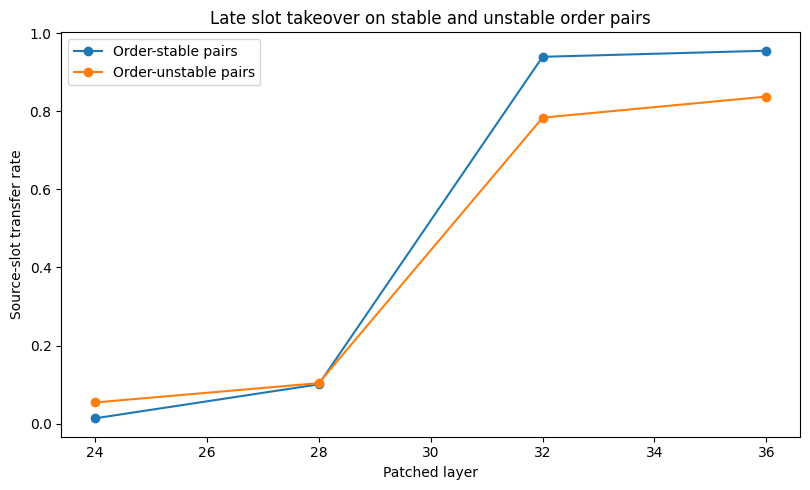

BLOCK 17 RESULT: late stratification is mixed; interpret the layerwise confidence intervals.
Block 17 complete.


In [ ]:
# =====================================================================
# BLOCK 17 — ORDER-INSTABILITY STRATIFICATION OF CAUSAL PATCHING
# =====================================================================
# CPU only. Links Block 16's causal effect to behavioural order
# instability without rerunning the model.
#
# Interpretation:
# - Stronger late takeover on unstable pairs suggests an association
#   with order-induced answer instability.
# - Similar takeover on stable and unstable pairs suggests a general
#   late output-slot commitment mechanism.

N_BOOT_17 = 1000

required_block17_objects = [
    "patch_pair_df",
    "patch_results_df",
    "question_metrics_df",
]

missing_block17_objects = [
    name
    for name in required_block17_objects
    if name not in globals()
]

if missing_block17_objects:
    raise RuntimeError(
        "Run Blocks 1–16 first. Missing: "
        + ", ".join(missing_block17_objects)
    )


def safe_auc_17(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    if (
        np.unique(y_true).size < 2
        or np.unique(scores).size < 2
    ):
        return np.nan

    return float(
        roc_auc_score(y_true, scores)
    )


# ---------------------------------------------------------------------
# Behavioural order-instability labels
# ---------------------------------------------------------------------

pair_metadata_17 = patch_pair_df.copy()

pair_metadata_17["order_unstable"] = (
    pair_metadata_17["source_content"]
    != pair_metadata_17["target_content"]
).astype(int)

pair_metadata_17["slot_informative"] = (
    pair_metadata_17["source_slot"]
    != pair_metadata_17["target_slot"]
).astype(int)


question_order_instability_df = (
    pair_metadata_17
    .groupby(
        "question_id",
        as_index=False,
    )
    .agg(
        directed_order_pairs=(
            "pair_id",
            "count",
        ),
        unstable_directed_pairs=(
            "order_unstable",
            "sum",
        ),
        order_instability_rate=(
            "order_unstable",
            "mean",
        ),
        informative_slot_pairs=(
            "slot_informative",
            "sum",
        ),
        pure_binding_pairs=(
            "pure_binding_pair",
            "sum",
        ),
        three_way_conflict_pairs=(
            "three_way_conflict",
            "sum",
        ),
    )
    .merge(
        question_metrics_df[
            [
                "question_id",
                "base_error",
                "consensus_error",
                "presentation_js",
                "order_js",
                "modal_consistency",
            ]
        ],
        on="question_id",
        how="left",
        validate="one_to_one",
    )
)


order_instability_base_auroc = safe_auc_17(
    question_order_instability_df[
        "base_error"
    ].astype(int),
    question_order_instability_df[
        "order_instability_rate"
    ],
)

order_instability_consensus_auroc = safe_auc_17(
    question_order_instability_df[
        "consensus_error"
    ].astype(int),
    question_order_instability_df[
        "order_instability_rate"
    ],
)


# ---------------------------------------------------------------------
# Question-clustered stable-versus-unstable contrasts
# ---------------------------------------------------------------------

def clustered_condition_difference_ci_17(
    frame,
    outcome,
    condition="order_unstable",
    n_boot=N_BOOT_17,
    salt=0,
):
    frame = frame.reset_index(drop=True)

    positive = frame[
        frame[condition] == 1
    ][outcome]

    negative = frame[
        frame[condition] == 0
    ][outcome]

    if (
        len(positive) == 0
        or len(negative) == 0
    ):
        return (
            np.nan,
            np.nan,
            np.nan,
            int(len(positive)),
            int(len(negative)),
        )

    observed = float(
        positive.mean()
        - negative.mean()
    )

    questions = frame[
        "question_id"
    ].unique()

    rows_by_question = {
        question_id: np.flatnonzero(
            frame[
                "question_id"
            ].to_numpy()
            == question_id
        )
        for question_id in questions
    }

    rng = np.random.default_rng(
        SEED + 1700 + salt
    )

    differences = []

    for _ in range(n_boot):
        sampled_questions = rng.choice(
            questions,
            size=len(questions),
            replace=True,
        )

        sampled_rows = np.concatenate(
            [
                rows_by_question[
                    question_id
                ]
                for question_id
                in sampled_questions
            ]
        )

        sampled = frame.iloc[
            sampled_rows
        ]

        sampled_positive = sampled[
            sampled[condition] == 1
        ][outcome]

        sampled_negative = sampled[
            sampled[condition] == 0
        ][outcome]

        if (
            len(sampled_positive) == 0
            or len(sampled_negative) == 0
        ):
            continue

        differences.append(
            sampled_positive.mean()
            - sampled_negative.mean()
        )

    if not differences:
        return (
            observed,
            np.nan,
            np.nan,
            int(len(positive)),
            int(len(negative)),
        )

    return (
        observed,
        float(
            np.quantile(
                differences,
                0.025,
            )
        ),
        float(
            np.quantile(
                differences,
                0.975,
            )
        ),
        int(len(positive)),
        int(len(negative)),
    )


analysis_17 = patch_results_df.merge(
    pair_metadata_17[
        [
            "pair_id",
            "order_unstable",
            "slot_informative",
        ]
    ],
    on="pair_id",
    how="left",
    validate="many_to_one",
)


informative_17 = analysis_17[
    analysis_17[
        "slot_informative"
    ]
    == 1
].copy()


stratified_rows = []

for layer_i, layer in enumerate(
    sorted(
        informative_17[
            "layer"
        ].unique()
    )
):
    current = informative_17[
        informative_17[
            "layer"
        ]
        == layer
    ]

    stable = current[
        current[
            "order_unstable"
        ]
        == 0
    ]

    unstable = current[
        current[
            "order_unstable"
        ]
        == 1
    ]

    (
        slot_difference,
        slot_ci_low,
        slot_ci_high,
        unstable_n,
        stable_n,
    ) = clustered_condition_difference_ci_17(
        current,
        "source_slot_transfer",
        salt=layer_i,
    )

    (
        change_difference,
        change_ci_low,
        change_ci_high,
        _,
        _,
    ) = clustered_condition_difference_ci_17(
        current,
        "changed_from_target",
        salt=100 + layer_i,
    )

    (
        content_difference,
        content_ci_low,
        content_ci_high,
        _,
        _,
    ) = clustered_condition_difference_ci_17(
        current,
        "source_content_transfer",
        salt=200 + layer_i,
    )

    stratified_rows.append(
        {
            "layer": int(layer),

            "stable_pairs": int(
                stable_n
            ),
            "unstable_pairs": int(
                unstable_n
            ),

            "stable_source_slot_transfer": float(
                stable[
                    "source_slot_transfer"
                ].mean()
            ),
            "unstable_source_slot_transfer": float(
                unstable[
                    "source_slot_transfer"
                ].mean()
            ),

            "unstable_minus_stable_slot_transfer": float(
                slot_difference
            ),
            "slot_difference_ci_low": float(
                slot_ci_low
            ),
            "slot_difference_ci_high": float(
                slot_ci_high
            ),

            "stable_change_rate": float(
                stable[
                    "changed_from_target"
                ].mean()
            ),
            "unstable_change_rate": float(
                unstable[
                    "changed_from_target"
                ].mean()
            ),

            "unstable_minus_stable_change_rate": float(
                change_difference
            ),
            "change_difference_ci_low": float(
                change_ci_low
            ),
            "change_difference_ci_high": float(
                change_ci_high
            ),

            "stable_source_content_transfer": float(
                stable[
                    "source_content_transfer"
                ].mean()
            ),
            "unstable_source_content_transfer": float(
                unstable[
                    "source_content_transfer"
                ].mean()
            ),

            "unstable_minus_stable_content_transfer": float(
                content_difference
            ),
            "content_difference_ci_low": float(
                content_ci_low
            ),
            "content_difference_ci_high": float(
                content_ci_high
            ),
        }
    )


order_instability_patch_df = pd.DataFrame(
    stratified_rows
)


# ---------------------------------------------------------------------
# Compare the sharp layer-28 -> layer-32 transition
# ---------------------------------------------------------------------

transition_source = informative_17[
    informative_17[
        "layer"
    ].isin(
        [28, 32, 36]
    )
][
    [
        "pair_id",
        "question_id",
        "order_unstable",
        "layer",
        "source_slot_transfer",
    ]
]


slot_wide = transition_source.pivot(
    index=[
        "pair_id",
        "question_id",
        "order_unstable",
    ],
    columns="layer",
    values="source_slot_transfer",
).reset_index()


for required_layer in [
    28,
    32,
    36,
]:
    if required_layer not in slot_wide.columns:
        raise RuntimeError(
            f"Layer {required_layer} is missing "
            "from Block 16 results."
        )


slot_wide[
    "slot_transition_28_to_32"
] = (
    slot_wide[32]
    - slot_wide[28]
)

slot_wide[
    "slot_transition_32_to_36"
] = (
    slot_wide[36]
    - slot_wide[32]
)


transition_rows = []

for transition_i, outcome in enumerate(
    [
        "slot_transition_28_to_32",
        "slot_transition_32_to_36",
    ]
):
    (
        difference,
        ci_low,
        ci_high,
        unstable_n,
        stable_n,
    ) = clustered_condition_difference_ci_17(
        slot_wide,
        outcome,
        salt=300 + transition_i,
    )

    transition_rows.append(
        {
            "transition": outcome,

            "stable_mean": float(
                slot_wide[
                    slot_wide[
                        "order_unstable"
                    ]
                    == 0
                ][outcome].mean()
            ),

            "unstable_mean": float(
                slot_wide[
                    slot_wide[
                        "order_unstable"
                    ]
                    == 1
                ][outcome].mean()
            ),

            "unstable_minus_stable": float(
                difference
            ),
            "difference_ci_low": float(
                ci_low
            ),
            "difference_ci_high": float(
                ci_high
            ),

            "stable_pairs": int(
                stable_n
            ),
            "unstable_pairs": int(
                unstable_n
            ),
        }
    )


order_instability_transition_df = pd.DataFrame(
    transition_rows
)


# ---------------------------------------------------------------------
# Save and display
# ---------------------------------------------------------------------

question_order_instability_df.to_csv(
    OUTPUT_DIR
    / "block17_question_order_instability.csv",
    index=False,
)

order_instability_patch_df.to_csv(
    OUTPUT_DIR
    / "block17_patch_stratification.csv",
    index=False,
)

order_instability_transition_df.to_csv(
    OUTPUT_DIR
    / "block17_transition_stratification.csv",
    index=False,
)


print(
    "\nQUESTION-LEVEL ORDER INSTABILITY"
)

print(
    question_order_instability_df[
        [
            "order_instability_rate",
            "unstable_directed_pairs",
            "directed_order_pairs",
        ]
    ]
    .describe()
    .round(4)
    .to_string()
)


print(
    "\nOrder-instability AUROC "
    "for base error:",
    round(
        float(
            order_instability_base_auroc
        ),
        4,
    ),
)

print(
    "Order-instability AUROC "
    "for consensus error:",
    round(
        float(
            order_instability_consensus_auroc
        ),
        4,
    ),
)


print(
    "\nCAUSAL EFFECTS STRATIFIED "
    "BY ORDER INSTABILITY"
)

print(
    order_instability_patch_df
    .round(4)
    .to_string(index=False)
)


print(
    "\nTRANSITION STRATIFICATION"
)

print(
    order_instability_transition_df
    .round(4)
    .to_string(index=False)
)


fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

ax.plot(
    order_instability_patch_df[
        "layer"
    ],
    order_instability_patch_df[
        "stable_source_slot_transfer"
    ],
    marker="o",
    label="Order-stable pairs",
)

ax.plot(
    order_instability_patch_df[
        "layer"
    ],
    order_instability_patch_df[
        "unstable_source_slot_transfer"
    ],
    marker="o",
    label="Order-unstable pairs",
)

ax.set_xlabel(
    "Patched layer"
)

ax.set_ylabel(
    "Source-slot transfer rate"
)

ax.set_title(
    "Late slot takeover on stable "
    "and unstable order pairs"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "figure_block17_instability_stratification.png",
    dpi=180,
)

plt.show()


late_17 = order_instability_patch_df[
    order_instability_patch_df[
        "layer"
    ]
    >= 32
]


if (
    late_17[
        "slot_difference_ci_low"
    ]
    > 0
).any():
    print(
        "BLOCK 17 RESULT: late slot takeover "
        "is stronger on order-unstable pairs "
        "at at least one late layer."
    )

elif (
    (
        late_17[
            "slot_difference_ci_low"
        ]
        <= 0
    )
    & (
        late_17[
            "slot_difference_ci_high"
        ]
        >= 0
    )
).all():
    print(
        "BLOCK 17 RESULT: late slot takeover "
        "is not detectably specific to "
        "order-unstable pairs; it appears "
        "to be a general late output-slot "
        "commitment mechanism."
    )

else:
    print(
        "BLOCK 17 RESULT: late stratification "
        "is mixed; interpret the layerwise "
        "confidence intervals."
    )


print("Block 17 complete.")


UNRELATED-SOURCE MATCH QUALITY
       match_tier  matched_order  matched_correctness  prompt_length_gap  unrelated_source_reuse_count
count       960.0          960.0                960.0            960.000                       960.000
mean          0.0            1.0                  1.0             26.600                         1.006
std           0.0            0.0                  0.0             51.499                         0.079
min           0.0            1.0                  1.0              0.000                         1.000
25%           0.0            1.0                  1.0              3.000                         1.000
50%           0.0            1.0                  1.0              9.000                         1.000
75%           0.0            1.0                  1.0             24.000                         1.000
max           0.0            1.0                  1.0            409.000                         2.000
Match-tier counts: {0: 960}


Matched unrelated-source controls:   0%|          | 0/3 [00:00<?, ?it/s]


MATCHED UNRELATED-SOURCE CONTROL
 layer             subset  pairs  same_question_slot_transfer  unrelated_slot_transfer  same_minus_unrelated_slot_transfer  slot_advantage_ci_low  slot_advantage_ci_high  same_question_change_rate  unrelated_change_rate  same_minus_unrelated_change_rate  change_advantage_ci_low  change_advantage_ci_high  same_unrelated_slot_agreement
    28    all_informative    670                       0.1015                   0.1776                             -0.0761                -0.1094                 -0.0410                     0.1866                 0.3358                           -0.1493                  -0.2024                   -0.0975                         0.6881
    28       pure_binding    448                       0.1004                   0.1808                             -0.0804                -0.1235                 -0.0411                     0.1362                 0.3147                           -0.1786                  -0.2417                

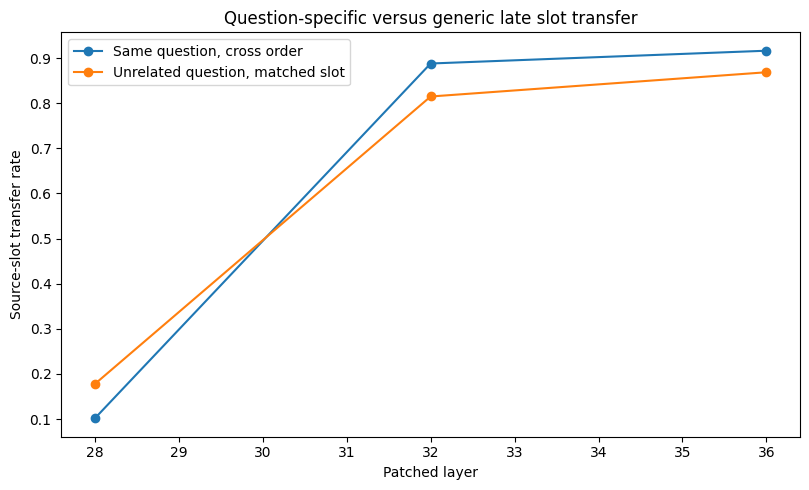

BLOCK 18 RESULT: late states contain a generic slot code plus a detectable same-question advantage at at least one late layer.
Block 18 complete.


In [ ]:
# =====================================================================
# BLOCK 18 — MATCHED UNRELATED-SOURCE CONTROL
# =====================================================================
# GPU block.
#
# Compares:
# 1. Same-question, cross-order source states from Block 16.
# 2. Unrelated-question source states matched on output slot and label.
#
# Matching also preserves source order and correctness whenever possible.
# Prompt length is used as a nearest-neighbour tie-break.
#
# Interpretation:
# - Similar transfer from unrelated same-slot states means the late
#   representation is primarily a generic output-slot code.
# - Stronger same-question transfer means the representation retains
#   question-specific information beyond generic slot coding.

CONTROL_LAYERS_18 = [
    28,
    32,
    36,
]

N_BOOT_18 = 1000


required_block18_objects = [
    "activation_index_df",
    "patch_pair_df",
    "patch_results_df",
    "residual_arrays",
    "run_answer_state_patch",
]

missing_block18_objects = [
    name
    for name in required_block18_objects
    if name not in globals()
]

if missing_block18_objects:
    raise RuntimeError(
        "Run Blocks 1–16 first. Missing: "
        + ", ".join(
            missing_block18_objects
        )
    )


missing_control_layers = [
    layer
    for layer in CONTROL_LAYERS_18
    if layer not in residual_arrays
]

if missing_control_layers:
    raise RuntimeError(
        "Missing cached residual states "
        f"for layers: {missing_control_layers}"
    )


# ---------------------------------------------------------------------
# Build deterministic unrelated-source matches
# ---------------------------------------------------------------------

source_catalog_18 = (
    activation_index_df
    .copy()
    .reset_index(drop=False)
    .rename(
        columns={
            "index": "catalog_row"
        }
    )
)


if (
    "prompt_tokens"
    in source_catalog_18.columns
):
    source_catalog_18[
        "control_prompt_length"
    ] = source_catalog_18[
        "prompt_tokens"
    ].astype(int)

else:
    source_catalog_18[
        "control_prompt_length"
    ] = source_catalog_18[
        "prompt"
    ].map(
        lambda prompt: len(
            tokenizer.encode(
                prompt,
                add_special_tokens=False,
            )
        )
    )


reuse_counts_18 = {
    int(row_id): 0
    for row_id
    in source_catalog_18[
        "catalog_row"
    ]
}


matched_rows_18 = []


for pair in patch_pair_df.itertuples(
    index=False
):
    original_source = (
        activation_index_df.iloc[
            int(pair.source_row)
        ]
    )

    target_question = int(
        pair.question_id
    )

    required_label = str(
        pair.label_system
    )

    required_slot = int(
        pair.source_slot
    )

    preferred_order = int(
        pair.source_order
    )

    preferred_correctness = bool(
        original_source[
            "view_correct"
        ]
    )

    if (
        "prompt_tokens"
        in activation_index_df.columns
    ):
        preferred_length = int(
            original_source[
                "prompt_tokens"
            ]
        )

    else:
        preferred_length = len(
            tokenizer.encode(
                original_source["prompt"],
                add_special_tokens=False,
            )
        )


    base_mask = (
        (
            source_catalog_18[
                "question_id"
            ].astype(int)
            != target_question
        )
        & (
            source_catalog_18[
                "label_system"
            ]
            == required_label
        )
        & (
            source_catalog_18[
                "predicted_slot"
            ].astype(int)
            == required_slot
        )
    )


    tier_masks = [
        (
            base_mask
            & (
                source_catalog_18[
                    "order_id"
                ].astype(int)
                == preferred_order
            )
            & (
                source_catalog_18[
                    "view_correct"
                ].astype(bool)
                == preferred_correctness
            )
        ),

        (
            base_mask
            & (
                source_catalog_18[
                    "order_id"
                ].astype(int)
                == preferred_order
            )
        ),

        (
            base_mask
            & (
                source_catalog_18[
                    "view_correct"
                ].astype(bool)
                == preferred_correctness
            )
        ),

        base_mask,
    ]


    chosen_tier = None
    candidates = None


    for tier, mask in enumerate(
        tier_masks
    ):
        current_candidates = (
            source_catalog_18[
                mask
            ].copy()
        )

        if len(current_candidates) > 0:
            chosen_tier = int(tier)
            candidates = current_candidates
            break


    if (
        candidates is None
        or len(candidates) == 0
    ):
        raise RuntimeError(
            "No unrelated source match "
            f"for pair {int(pair.pair_id)}."
        )


    candidates[
        "reuse_count"
    ] = candidates[
        "catalog_row"
    ].map(
        reuse_counts_18
    )


    candidates[
        "length_gap"
    ] = (
        candidates[
            "control_prompt_length"
        ]
        - preferred_length
    ).abs()


    candidates[
        "deterministic_tie"
    ] = (
        candidates[
            "catalog_row"
        ].astype(int)
        * 1009
        + int(pair.pair_id)
        * 9176
        + SEED
    ) % 1000003


    chosen = candidates.sort_values(
        [
            "reuse_count",
            "length_gap",
            "deterministic_tie",
            "catalog_row",
        ]
    ).iloc[0]


    unrelated_source_row = int(
        chosen[
            "catalog_row"
        ]
    )

    reuse_counts_18[
        unrelated_source_row
    ] += 1


    matched_rows_18.append(
        {
            "pair_id": int(
                pair.pair_id
            ),

            "same_question_source_row": int(
                pair.source_row
            ),

            "unrelated_source_row": (
                unrelated_source_row
            ),

            "unrelated_source_question_id": int(
                chosen[
                    "question_id"
                ]
            ),

            "match_tier": chosen_tier,

            "matched_order": int(
                int(
                    chosen[
                        "order_id"
                    ]
                )
                == preferred_order
            ),

            "matched_correctness": int(
                bool(
                    chosen[
                        "view_correct"
                    ]
                )
                == preferred_correctness
            ),

            "prompt_length_gap": int(
                chosen[
                    "length_gap"
                ]
            ),

            "unrelated_source_reuse_count": int(
                reuse_counts_18[
                    unrelated_source_row
                ]
            ),
        }
    )


unrelated_match_df = pd.DataFrame(
    matched_rows_18
)


unrelated_pair_df = patch_pair_df.merge(
    unrelated_match_df,
    on="pair_id",
    how="left",
    validate="one_to_one",
)


unrelated_pair_df[
    "source_row"
] = unrelated_pair_df[
    "unrelated_source_row"
].astype(int)


# ---------------------------------------------------------------------
# Validate source matching
# ---------------------------------------------------------------------

unrelated_source_slots = (
    activation_index_df.iloc[
        unrelated_pair_df[
            "source_row"
        ].to_numpy(dtype=int)
    ][
        "predicted_slot"
    ]
    .to_numpy(dtype=int)
)


if not np.array_equal(
    unrelated_source_slots,
    unrelated_pair_df[
        "source_slot"
    ].to_numpy(dtype=int),
):
    raise RuntimeError(
        "At least one unrelated source "
        "does not match the required slot."
    )


unrelated_source_questions = (
    activation_index_df.iloc[
        unrelated_pair_df[
            "source_row"
        ].to_numpy(dtype=int)
    ][
        "question_id"
    ]
    .to_numpy(dtype=int)
)


if np.any(
    unrelated_source_questions
    == unrelated_pair_df[
        "question_id"
    ].to_numpy(dtype=int)
):
    raise RuntimeError(
        "At least one control source "
        "comes from the target question."
    )


print(
    "\nUNRELATED-SOURCE MATCH QUALITY"
)

print(
    unrelated_match_df[
        [
            "match_tier",
            "matched_order",
            "matched_correctness",
            "prompt_length_gap",
            "unrelated_source_reuse_count",
        ]
    ]
    .describe()
    .round(3)
    .to_string()
)


print(
    "Match-tier counts:",
    unrelated_match_df[
        "match_tier"
    ]
    .value_counts()
    .sort_index()
    .to_dict(),
)


# ---------------------------------------------------------------------
# Run unrelated-source patches
# ---------------------------------------------------------------------

control_frames_18 = []


for layer in tqdm(
    CONTROL_LAYERS_18,
    desc="Matched unrelated-source controls",
):
    (
        unrelated_slots,
        unrelated_contents,
    ) = run_answer_state_patch(
        layer,
        unrelated_pair_df,
    )


    current = unrelated_pair_df.copy()

    current[
        "layer"
    ] = int(layer)

    current[
        "unrelated_patched_slot"
    ] = unrelated_slots

    current[
        "unrelated_patched_content"
    ] = unrelated_contents


    current[
        "unrelated_source_slot_transfer"
    ] = (
        current[
            "unrelated_patched_slot"
        ]
        == current[
            "source_slot"
        ]
    ).astype(int)


    current[
        "unrelated_target_slot_preserved"
    ] = (
        current[
            "unrelated_patched_slot"
        ]
        == current[
            "target_slot"
        ]
    ).astype(int)


    current[
        "unrelated_changed_from_target"
    ] = (
        current[
            "unrelated_patched_slot"
        ]
        != current[
            "target_slot"
        ]
    ).astype(int)


    same_question = patch_results_df[
        patch_results_df[
            "layer"
        ]
        == layer
    ][
        [
            "pair_id",
            "patched_slot",
            "source_slot_transfer",
            "target_slot_preserved",
            "changed_from_target",
        ]
    ].rename(
        columns={
            "patched_slot": (
                "same_question_patched_slot"
            ),
            "source_slot_transfer": (
                "same_question_source_slot_transfer"
            ),
            "target_slot_preserved": (
                "same_question_target_slot_preserved"
            ),
            "changed_from_target": (
                "same_question_changed_from_target"
            ),
        }
    )


    current = current.merge(
        same_question,
        on="pair_id",
        how="left",
        validate="one_to_one",
    )


    current[
        "same_unrelated_slot_agreement"
    ] = (
        current[
            "same_question_patched_slot"
        ]
        == current[
            "unrelated_patched_slot"
        ]
    ).astype(int)


    control_frames_18.append(
        current
    )


unrelated_control_results_df = pd.concat(
    control_frames_18,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Question-clustered paired differences
# ---------------------------------------------------------------------

def paired_question_difference_ci_18(
    frame,
    first,
    second,
    n_boot=N_BOOT_18,
    salt=0,
):
    frame = frame.reset_index(
        drop=True
    )

    if len(frame) == 0:
        return (
            np.nan,
            np.nan,
            np.nan,
            0,
        )


    per_row_difference = (
        frame[
            first
        ].to_numpy(dtype=float)
        - frame[
            second
        ].to_numpy(dtype=float)
    )


    observed = float(
        per_row_difference.mean()
    )


    questions = frame[
        "question_id"
    ].unique()


    rows_by_question = {
        question_id: np.flatnonzero(
            frame[
                "question_id"
            ].to_numpy()
            == question_id
        )
        for question_id in questions
    }


    rng = np.random.default_rng(
        SEED + 1800 + salt
    )

    differences = []


    for _ in range(n_boot):
        sampled_questions = rng.choice(
            questions,
            size=len(questions),
            replace=True,
        )

        sampled_rows = np.concatenate(
            [
                rows_by_question[
                    question_id
                ]
                for question_id
                in sampled_questions
            ]
        )

        differences.append(
            float(
                per_row_difference[
                    sampled_rows
                ].mean()
            )
        )


    return (
        observed,
        float(
            np.quantile(
                differences,
                0.025,
            )
        ),
        float(
            np.quantile(
                differences,
                0.975,
            )
        ),
        int(len(frame)),
    )


subset_definitions_18 = {
    "all_informative": (
        lambda frame: frame[
            frame[
                "source_slot"
            ]
            != frame[
                "target_slot"
            ]
        ]
    ),

    "pure_binding": (
        lambda frame: frame[
            frame[
                "pure_binding_pair"
            ]
            == 1
        ]
    ),

    "three_way_conflict": (
        lambda frame: frame[
            frame[
                "three_way_conflict"
            ]
            == 1
        ]
    ),
}


summary_rows_18 = []


for layer_i, layer in enumerate(
    CONTROL_LAYERS_18
):
    layer_frame = (
        unrelated_control_results_df[
            unrelated_control_results_df[
                "layer"
            ]
            == layer
        ]
    )


    for subset_i, (
        subset_name,
        selector,
    ) in enumerate(
        subset_definitions_18.items()
    ):
        subset = selector(
            layer_frame
        ).copy()


        (
            slot_advantage,
            slot_ci_low,
            slot_ci_high,
            subset_n,
        ) = paired_question_difference_ci_18(
            subset,
            "same_question_source_slot_transfer",
            "unrelated_source_slot_transfer",
            salt=(
                100 * layer_i
                + subset_i
            ),
        )


        (
            change_advantage,
            change_ci_low,
            change_ci_high,
            _,
        ) = paired_question_difference_ci_18(
            subset,
            "same_question_changed_from_target",
            "unrelated_changed_from_target",
            salt=(
                500
                + 100 * layer_i
                + subset_i
            ),
        )


        summary_rows_18.append(
            {
                "layer": int(layer),
                "subset": subset_name,
                "pairs": int(
                    subset_n
                ),

                "same_question_slot_transfer": (
                    float(
                        subset[
                            "same_question_source_slot_transfer"
                        ].mean()
                    )
                    if subset_n
                    else np.nan
                ),

                "unrelated_slot_transfer": (
                    float(
                        subset[
                            "unrelated_source_slot_transfer"
                        ].mean()
                    )
                    if subset_n
                    else np.nan
                ),

                "same_minus_unrelated_slot_transfer": float(
                    slot_advantage
                ),

                "slot_advantage_ci_low": float(
                    slot_ci_low
                ),

                "slot_advantage_ci_high": float(
                    slot_ci_high
                ),

                "same_question_change_rate": (
                    float(
                        subset[
                            "same_question_changed_from_target"
                        ].mean()
                    )
                    if subset_n
                    else np.nan
                ),

                "unrelated_change_rate": (
                    float(
                        subset[
                            "unrelated_changed_from_target"
                        ].mean()
                    )
                    if subset_n
                    else np.nan
                ),

                "same_minus_unrelated_change_rate": float(
                    change_advantage
                ),

                "change_advantage_ci_low": float(
                    change_ci_low
                ),

                "change_advantage_ci_high": float(
                    change_ci_high
                ),

                "same_unrelated_slot_agreement": (
                    float(
                        subset[
                            "same_unrelated_slot_agreement"
                        ].mean()
                    )
                    if subset_n
                    else np.nan
                ),
            }
        )


unrelated_control_summary_df = pd.DataFrame(
    summary_rows_18
)


# ---------------------------------------------------------------------
# Save and display
# ---------------------------------------------------------------------

unrelated_match_df.to_csv(
    OUTPUT_DIR
    / "block18_unrelated_source_matches.csv",
    index=False,
)

unrelated_control_results_df.to_pickle(
    OUTPUT_DIR
    / "block18_unrelated_source_results.pkl"
)

unrelated_control_summary_df.to_csv(
    OUTPUT_DIR
    / "block18_unrelated_source_summary.csv",
    index=False,
)


print(
    "\nMATCHED UNRELATED-SOURCE CONTROL"
)

print(
    unrelated_control_summary_df
    .round(4)
    .to_string(index=False)
)


plot_18 = unrelated_control_summary_df[
    unrelated_control_summary_df[
        "subset"
    ]
    == "all_informative"
]


fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

ax.plot(
    plot_18["layer"],
    plot_18[
        "same_question_slot_transfer"
    ],
    marker="o",
    label=(
        "Same question, "
        "cross order"
    ),
)

ax.plot(
    plot_18["layer"],
    plot_18[
        "unrelated_slot_transfer"
    ],
    marker="o",
    label=(
        "Unrelated question, "
        "matched slot"
    ),
)

ax.set_xlabel(
    "Patched layer"
)

ax.set_ylabel(
    "Source-slot transfer rate"
)

ax.set_title(
    "Question-specific versus "
    "generic late slot transfer"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "figure_block18_unrelated_source_control.png",
    dpi=180,
)

plt.show()


late_18 = plot_18[
    plot_18[
        "layer"
    ]
    >= 32
]


if (
    (
        late_18[
            "unrelated_slot_transfer"
        ]
        >= 0.75
    ).all()
    and (
        (
            late_18[
                "slot_advantage_ci_low"
            ]
            <= 0
        )
        & (
            late_18[
                "slot_advantage_ci_high"
            ]
            >= 0
        )
    ).all()
):
    print(
        "BLOCK 18 RESULT: late transfer is "
        "largely a generic output-slot code; "
        "same-question context adds no "
        "detectable advantage."
    )

elif (
    late_18[
        "slot_advantage_ci_low"
    ]
    > 0
).any():
    print(
        "BLOCK 18 RESULT: late states contain "
        "a generic slot code plus a detectable "
        "same-question advantage at at least "
        "one late layer."
    )

elif (
    late_18[
        "unrelated_slot_transfer"
    ]
    < 0.50
).all():
    print(
        "BLOCK 18 RESULT: late transfer appears "
        "predominantly question-specific rather "
        "than generic slot copying."
    )

else:
    print(
        "BLOCK 18 RESULT: mixed control outcome; "
        "interpret the paired layerwise "
        "confidence intervals."
    )


print("Block 18 complete.")

In [ ]:
# =====================================================================
# BLOCK 19 — SWITCH FROM GRANITE TO QWEN AND FREEZE THE REPLICATION
# =====================================================================
# No new pip cell.
#
# This block:
# 1. freezes the paired replication criteria;
# 2. releases Granite from GPU memory;
# 3. loads Qwen3-4B-Instruct-2507;
# 4. rebuilds the same 200 × 8 presentations with Qwen's chat template;
# 5. validates constrained answer-label scoring.

QWEN_MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"
QWEN_OUTPUT_DIR = Path(
    "/content/content_binding_uncertainty_qwen_replication"
)
QWEN_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Batch size 1 is deliberately conservative for a Colab T4.
QWEN_BATCH_SIZE = 1


required = [
    "questions_df",
    "presentation_df",
    "LABEL_SYSTEMS",
    "format_multiple_choice_prompt",
    "apply_chat_template",
    "build_label_token_sets",
    "final_vocabulary_logits",
    "option_logits_from_vocab",
    "PANELS",
    "panel_metrics",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run Blocks 1–18 first. Missing: "
        + ", ".join(missing)
    )


# ---------------------------------------------------------------------
# Freeze the replication protocol before observing Qwen results
# ---------------------------------------------------------------------

replication_protocol = {
    "discovery_model": str(MODEL_ID),
    "replication_model": QWEN_MODEL_ID,
    "question_ids": (
        questions_df[
            "question_id"
        ]
        .astype(int)
        .tolist()
    ),
    "primary_directional_criteria": {
        "four_orders_improve_over_single_view": True,
        "two_order_views_beat_two_label_views": True,
        "order_instability_predicts_base_error_above_chance": True,
    },
    "formal_order_binding_decomposition_deferred_to_block_21": True,
    "no_tuning_after_qwen_results": True,
}

with open(
    QWEN_OUTPUT_DIR
    / "replication_protocol.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        replication_protocol,
        handle,
        indent=2,
    )


# ---------------------------------------------------------------------
# Release Granite GPU memory
# ---------------------------------------------------------------------

for name in [
    "model",
    "tokenizer",
    "tokens",
    "attention_mask",
    "logits",
    "vocab_logits",
    "option_logits",
    "replacements",
]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(
    "GPU after Granite release:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        3,
    ),
    "GiB allocated",
)


# ---------------------------------------------------------------------
# Load Qwen through TransformerBridge
# ---------------------------------------------------------------------

MODEL_ID = QWEN_MODEL_ID
BATCH_SIZE = QWEN_BATCH_SIZE

model = TransformerBridge.boot_transformers(
    MODEL_ID,
    device=DEVICE,
    dtype=DTYPE,
    trust_remote_code=False,
)

model.enable_compatibility_mode(
    no_processing=True,
    disable_warnings=True,
)

model.eval()

tokenizer = model.tokenizer
tokenizer.padding_side = "left"
tokenizer.truncation_side = "left"

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = (
        tokenizer.eos_token_id
    )

if not getattr(
    tokenizer,
    "chat_template",
    None,
):
    raise RuntimeError(
        "The Qwen tokenizer has no chat template."
    )

print(
    f"Loaded {MODEL_ID}: "
    f"{model.cfg.n_layers} layers, "
    f"{model.cfg.n_heads} heads, "
    f"d_model={model.cfg.d_model}"
)


# ---------------------------------------------------------------------
# Rebuild the same semantic presentations with Qwen's chat template
# ---------------------------------------------------------------------

question_lookup = (
    questions_df
    .set_index("question_id")
    .to_dict(orient="index")
)

qwen_rows = []

for row in presentation_df.itertuples(
    index=False
):
    question_id = int(
        row.question_id
    )

    question_record = question_lookup[
        question_id
    ]

    canonical_texts = (
        question_record[
            "canonical_texts"
        ]
    )

    ordered_texts = [
        canonical_texts[
            int(content_id)
        ]
        for content_id
        in row.slot_to_content
    ]

    label_system = str(
        row.label_system
    )

    user_text = (
        format_multiple_choice_prompt(
            question_record[
                "question"
            ],
            ordered_texts,
            LABEL_SYSTEMS[
                label_system
            ],
        )
    )

    # apply_chat_template reads the current global tokenizer,
    # which is now Qwen's tokenizer.
    prompt = apply_chat_template(
        user_text
    )

    qwen_rows.append(
        {
            "presentation_index": int(
                row.presentation_index
            ),
            "question_id": question_id,
            "category": str(
                row.category
            ),
            "gold_content_id": int(
                row.gold_content_id
            ),
            "order_id": int(
                row.order_id
            ),
            "label_system": label_system,
            "slot_to_content": [
                int(value)
                for value
                in row.slot_to_content
            ],
            "prompt": prompt,
            "prompt_tokens": len(
                tokenizer.encode(
                    prompt,
                    add_special_tokens=False,
                )
            ),
        }
    )


qwen_presentation_df = (
    pd.DataFrame(
        qwen_rows
    )
    .sort_values(
        "presentation_index"
    )
    .reset_index(drop=True)
)


if len(qwen_presentation_df) != len(
    presentation_df
):
    raise RuntimeError(
        "Qwen presentation count differs "
        "from Granite."
    )


if not (
    qwen_presentation_df
    .groupby("question_id")
    .size()
    == 8
).all():
    raise RuntimeError(
        "Every Qwen question must have "
        "exactly eight presentations."
    )


if (
    qwen_presentation_df[
        "prompt_tokens"
    ].max()
    > MAX_PROMPT_TOKENS
):
    raise RuntimeError(
        "A Qwen prompt exceeds "
        "MAX_PROMPT_TOKENS."
    )


# ---------------------------------------------------------------------
# Rebuild answer-token sets for Qwen
# ---------------------------------------------------------------------
# Existing scoring functions read the global model, tokenizer,
# BATCH_SIZE and LABEL_TOKEN_SETS, so no duplicate scoring framework
# is needed.

LABEL_TOKEN_SETS = {
    label_system: (
        build_label_token_sets(
            labels
        )
    )
    for label_system, labels
    in LABEL_SYSTEMS.items()
}


# ---------------------------------------------------------------------
# Validate constrained scoring against Qwen's greedy next token
# ---------------------------------------------------------------------

validation_rows = []

for label_system in LABEL_SYSTEMS:
    prompts = (
        qwen_presentation_df[
            qwen_presentation_df[
                "label_system"
            ]
            == label_system
        ][
            "prompt"
        ]
        .iloc[
            :N_CALIBRATION_PER_SYSTEM
        ]
        .tolist()
    )

    vocabulary_logits = (
        final_vocabulary_logits(
            prompts
        )
    )

    constrained_slots = (
        option_logits_from_vocab(
            vocabulary_logits,
            label_system,
        )
        .argmax(dim=-1)
        .numpy()
    )

    greedy_token_ids = (
        vocabulary_logits
        .argmax(dim=-1)
        .numpy()
    )

    token_to_slot = {
        int(token_id): int(slot)
        for slot, label in enumerate(
            LABEL_SYSTEMS[
                label_system
            ]
        )
        for token_id in (
            LABEL_TOKEN_SETS[
                label_system
            ][label]
        )
    }

    greedy_slots = np.array(
        [
            token_to_slot.get(
                int(token_id),
                -1,
            )
            for token_id
            in greedy_token_ids
        ],
        dtype=int,
    )

    covered = (
        greedy_slots >= 0
    )

    validation_rows.append(
        {
            "label_system": label_system,

            "greedy_label_coverage": float(
                covered.mean()
            ),

            "constrained_greedy_agreement": (
                float(
                    (
                        greedy_slots[
                            covered
                        ]
                        == constrained_slots[
                            covered
                        ]
                    ).mean()
                )
                if covered.any()
                else 0.0
            ),
        }
    )

    del vocabulary_logits


qwen_scoring_validation_df = (
    pd.DataFrame(
        validation_rows
    )
)


print(
    "\nQWEN SCORING VALIDATION"
)

print(
    qwen_scoring_validation_df
    .round(4)
    .to_string(index=False)
)


qwen_scoring_valid = bool(
    (
        qwen_scoring_validation_df[
            "greedy_label_coverage"
        ]
        >= 0.75
    ).all()
    and
    (
        qwen_scoring_validation_df[
            "constrained_greedy_agreement"
        ]
        >= 0.95
    ).all()
)


if not qwen_scoring_valid:
    raise RuntimeError(
        "Qwen constrained-label scoring "
        "validation failed."
    )


# ---------------------------------------------------------------------
# Save Block 19 outputs
# ---------------------------------------------------------------------

qwen_presentation_df.to_pickle(
    QWEN_OUTPUT_DIR
    / "qwen_presentations.pkl"
)

qwen_scoring_validation_df.to_csv(
    QWEN_OUTPUT_DIR
    / "qwen_scoring_validation.csv",
    index=False,
)

with open(
    QWEN_OUTPUT_DIR
    / "qwen_model_config.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        {
            "model_id": MODEL_ID,
            "n_layers": int(
                model.cfg.n_layers
            ),
            "n_heads": int(
                model.cfg.n_heads
            ),
            "d_model": int(
                model.cfg.d_model
            ),
            "batch_size": int(
                BATCH_SIZE
            ),
            "label_token_sets": (
                LABEL_TOKEN_SETS
            ),
        },
        handle,
        indent=2,
    )


print(
    "Qwen paired presentations:",
    len(qwen_presentation_df),
)

print(
    "Prompt-token range:",
    int(
        qwen_presentation_df[
            "prompt_tokens"
        ].min()
    ),
    "to",
    int(
        qwen_presentation_df[
            "prompt_tokens"
        ].max()
    ),
)

print("Block 19 complete.")

GPU after Granite release: 0.009 GiB allocated


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

Loaded Qwen/Qwen3-4B-Instruct-2507: 36 layers, 32 heads, d_model=2560

QWEN SCORING VALIDATION
label_system  greedy_label_coverage  constrained_greedy_agreement
     letters                    1.0                           1.0
      digits                    1.0                           1.0
Qwen paired presentations: 1600
Prompt-token range: 99 to 509
Block 19 complete.


In [ ]:
# =====================================================================
# BLOCK 20 — QWEN PAIRED BEHAVIOURAL REPLICATION
# =====================================================================
# Runs the same eight presentations per question on Qwen.
#
# No mechanistic hooks are used here. The goal is to establish whether
# the option-order uncertainty phenomenon replicates before conducting
# any Qwen mechanistic intervention.

required = [
    "qwen_presentation_df",
    "score_prompt_list",
    "entropy_bits",
    "generalized_js_divergence",
    "PANELS",
    "panel_metrics",
    "safe_metric",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run Block 19 first. Missing: "
        + ", ".join(missing)
    )


CONTENT_COLS = [
    f"content_probability_{content_id}"
    for content_id in range(4)
]


# ---------------------------------------------------------------------
# Run Qwen inference
# ---------------------------------------------------------------------

scored_parts = []

for label_system in LABEL_SYSTEMS:
    subset = (
        qwen_presentation_df[
            qwen_presentation_df[
                "label_system"
            ]
            == label_system
        ]
        .copy()
        .reset_index(drop=True)
    )

    print(
        f"Scoring {len(subset)} Qwen views "
        f"with {label_system!r} labels..."
    )

    result = score_prompt_list(
        subset[
            "prompt"
        ].tolist(),
        label_system,
    )

    subset[
        "predicted_slot"
    ] = result[
        "predicted_slot"
    ]

    subset[
        "view_entropy_bits"
    ] = result[
        "entropy_bits"
    ]

    subset[
        "view_margin"
    ] = result[
        "margin"
    ]

    subset[
        "view_max_probability"
    ] = result[
        "max_probability"
    ]

    for slot in range(4):
        subset[
            f"slot_logit_{slot}"
        ] = result[
            "option_logits"
        ][
            :,
            slot,
        ]

        subset[
            f"slot_probability_{slot}"
        ] = result[
            "option_probs"
        ][
            :,
            slot,
        ]

    scored_parts.append(
        subset
    )


qwen_scored_df = (
    pd.concat(
        scored_parts,
        ignore_index=True,
    )
    .sort_values(
        "presentation_index"
    )
    .reset_index(drop=True)
)


if len(qwen_scored_df) != len(
    qwen_presentation_df
):
    raise RuntimeError(
        "Qwen inference returned the "
        "wrong number of rows."
    )


# ---------------------------------------------------------------------
# Map emitted slots back to invariant answer-content identities
# ---------------------------------------------------------------------

content_rows = []
predicted_contents = []


for row in qwen_scored_df.itertuples(
    index=False
):
    slot_probabilities = np.array(
        [
            getattr(
                row,
                f"slot_probability_{slot}",
            )
            for slot in range(4)
        ],
        dtype=float,
    )

    content_probabilities = np.zeros(
        4,
        dtype=float,
    )

    for slot, content_id in enumerate(
        row.slot_to_content
    ):
        content_probabilities[
            int(content_id)
        ] = slot_probabilities[
            slot
        ]

    content_rows.append(
        content_probabilities
    )

    predicted_contents.append(
        int(
            row.slot_to_content[
                int(
                    row.predicted_slot
                )
            ]
        )
    )


content_matrix = np.vstack(
    content_rows
)


if not np.allclose(
    content_matrix.sum(axis=1),
    1.0,
    atol=1e-5,
):
    raise RuntimeError(
        "Mapped Qwen content probabilities "
        "do not sum to one."
    )


for content_id in range(4):
    qwen_scored_df[
        f"content_probability_{content_id}"
    ] = content_matrix[
        :,
        content_id,
    ]


qwen_scored_df[
    "predicted_content_id"
] = predicted_contents


qwen_scored_df[
    "view_correct"
] = (
    qwen_scored_df[
        "predicted_content_id"
    ]
    == qwen_scored_df[
        "gold_content_id"
    ]
)


# ---------------------------------------------------------------------
# Question-level uncertainty quantities
# ---------------------------------------------------------------------

question_rows = []


for question_id, group in (
    qwen_scored_df.groupby(
        "question_id",
        sort=False,
    )
):
    group = group.sort_values(
        [
            "order_id",
            "label_system",
        ]
    )

    content_probabilities = group[
        CONTENT_COLS
    ].to_numpy(dtype=float)

    consensus_probabilities = (
        content_probabilities.mean(
            axis=0
        )
    )

    gold_content_id = int(
        group[
            "gold_content_id"
        ].iloc[0]
    )

    predictions = group[
        "predicted_content_id"
    ].to_numpy(dtype=int)

    prediction_counts = np.bincount(
        predictions,
        minlength=4,
    )

    binding_js_values = [
        generalized_js_divergence(
            group[
                group[
                    "order_id"
                ]
                == order_id
            ][
                CONTENT_COLS
            ].to_numpy(dtype=float)
        )
        for order_id in range(4)
    ]

    order_js_values = [
        generalized_js_divergence(
            group[
                group[
                    "label_system"
                ]
                == label_system
            ][
                CONTENT_COLS
            ].to_numpy(dtype=float)
        )
        for label_system in LABEL_SYSTEMS
    ]

    base_row = group[
        (
            group[
                "order_id"
            ]
            == 0
        )
        & (
            group[
                "label_system"
            ]
            == "letters"
        )
    ].iloc[0]

    question_rows.append(
        {
            "question_id": int(
                question_id
            ),

            "base_correct": bool(
                base_row[
                    "view_correct"
                ]
            ),

            "base_entropy": float(
                base_row[
                    "view_entropy_bits"
                ]
            ),

            "base_margin": float(
                base_row[
                    "view_margin"
                ]
            ),

            "consensus_correct": bool(
                int(
                    consensus_probabilities.argmax()
                )
                == gold_content_id
            ),

            "mean_view_accuracy": float(
                group[
                    "view_correct"
                ].mean()
            ),

            "modal_consistency": float(
                prediction_counts.max()
                / len(predictions)
            ),

            "content_consensus_entropy": float(
                entropy_bits(
                    consensus_probabilities
                )
            ),

            "presentation_js": float(
                generalized_js_divergence(
                    content_probabilities
                )
            ),

            "binding_js": float(
                np.mean(
                    binding_js_values
                )
            ),

            "order_js": float(
                np.mean(
                    order_js_values
                )
            ),
        }
    )


qwen_question_metrics_df = (
    pd.DataFrame(
        question_rows
    )
)


qwen_question_metrics_df[
    "base_error"
] = (
    ~qwen_question_metrics_df[
        "base_correct"
    ]
)


qwen_question_metrics_df[
    "consensus_error"
] = (
    ~qwen_question_metrics_df[
        "consensus_correct"
    ]
)


# ---------------------------------------------------------------------
# Reuse the exact compute-matched panel definitions from Block 11
# ---------------------------------------------------------------------

panel_rows = []


for (
    panel_id,
    design,
    view_keys,
) in PANELS:
    for question_id, group in (
        qwen_scored_df.groupby(
            "question_id",
            sort=False,
        )
    ):
        panel_rows.append(
            {
                "panel_id": panel_id,
                "design": design,
                "n_views": int(
                    len(view_keys)
                ),
                "question_id": int(
                    question_id
                ),
                **panel_metrics(
                    group,
                    view_keys,
                ),
            }
        )


qwen_compute_matched_question_df = (
    pd.DataFrame(
        panel_rows
    )
)


qwen_panel_accuracy_df = (
    qwen_compute_matched_question_df
    .groupby(
        [
            "panel_id",
            "design",
            "n_views",
        ],
        as_index=False,
    )
    .agg(
        consensus_accuracy=(
            "panel_error",
            lambda values: (
                1.0
                - float(
                    np.mean(
                        values
                    )
                )
            ),
        ),

        mean_view_accuracy=(
            "mean_view_accuracy",
            "mean",
        ),
    )
)


qwen_accuracy_summary_df = (
    qwen_panel_accuracy_df
    .groupby(
        [
            "design",
            "n_views",
        ],
        as_index=False,
    )
    .agg(
        panels=(
            "panel_id",
            "nunique",
        ),

        consensus_accuracy=(
            "consensus_accuracy",
            "mean",
        ),

        consensus_accuracy_sd=(
            "consensus_accuracy",
            "std",
        ),

        mean_view_accuracy=(
            "mean_view_accuracy",
            "mean",
        ),
    )
    .sort_values(
        [
            "n_views",
            "design",
        ]
    )
)


# ---------------------------------------------------------------------
# Error detection for the fixed base presentation
# ---------------------------------------------------------------------

target = (
    qwen_question_metrics_df[
        "base_error"
    ]
    .astype(int)
    .to_numpy()
)


signals = {
    "base_entropy": (
        qwen_question_metrics_df[
            "base_entropy"
        ].to_numpy()
    ),

    "negative_base_margin": (
        -qwen_question_metrics_df[
            "base_margin"
        ].to_numpy()
    ),

    "content_consensus_entropy": (
        qwen_question_metrics_df[
            "content_consensus_entropy"
        ].to_numpy()
    ),

    "presentation_js": (
        qwen_question_metrics_df[
            "presentation_js"
        ].to_numpy()
    ),

    "order_js": (
        qwen_question_metrics_df[
            "order_js"
        ].to_numpy()
    ),

    "binding_js": (
        qwen_question_metrics_df[
            "binding_js"
        ].to_numpy()
    ),

    "one_minus_modal_consistency": (
        1.0
        - qwen_question_metrics_df[
            "modal_consistency"
        ].to_numpy()
    ),
}


qwen_uncertainty_evaluation_df = (
    pd.DataFrame(
        [
            {
                "signal": signal_name,

                "auroc": safe_metric(
                    target,
                    scores,
                    roc_auc_score,
                ),

                "auprc": safe_metric(
                    target,
                    scores,
                    average_precision_score,
                ),
            }
            for signal_name, scores
            in signals.items()
        ]
    )
    .sort_values(
        "auroc",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Pre-specified replication decisions
# ---------------------------------------------------------------------

def design_accuracy(
    design_name,
):
    row = qwen_accuracy_summary_df[
        qwen_accuracy_summary_df[
            "design"
        ]
        == design_name
    ]

    if len(row) != 1:
        raise RuntimeError(
            "Missing Qwen design summary: "
            f"{design_name}"
        )

    return float(
        row[
            "consensus_accuracy"
        ].iloc[0]
    )


single_accuracy = design_accuracy(
    "single_view"
)

two_label_accuracy = design_accuracy(
    "label_variation"
)

two_order_accuracy = design_accuracy(
    "order_variation"
)

four_order_accuracy = design_accuracy(
    "all_orders_one_label"
)

full_accuracy = design_accuracy(
    "full_factorial"
)


modal_auroc = float(
    qwen_uncertainty_evaluation_df.loc[
        qwen_uncertainty_evaluation_df[
            "signal"
        ]
        == "one_minus_modal_consistency",
        "auroc",
    ].iloc[0]
)


qwen_primary_replication_df = (
    pd.DataFrame(
        [
            {
                "criterion": (
                    "four_orders_improve_"
                    "over_single_view"
                ),

                "value": (
                    four_order_accuracy
                    - single_accuracy
                ),

                "passed": bool(
                    four_order_accuracy
                    > single_accuracy
                ),
            },

            {
                "criterion": (
                    "two_order_views_beat_"
                    "two_label_views"
                ),

                "value": (
                    two_order_accuracy
                    - two_label_accuracy
                ),

                "passed": bool(
                    two_order_accuracy
                    > two_label_accuracy
                ),
            },

            {
                "criterion": (
                    "order_instability_predicts_"
                    "base_error_above_chance"
                ),

                "value": modal_auroc,

                "passed": bool(
                    modal_auroc > 0.5
                ),
            },
        ]
    )
)


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

qwen_scored_df.to_pickle(
    QWEN_OUTPUT_DIR
    / "qwen_scored_presentations.pkl"
)

qwen_question_metrics_df.to_csv(
    QWEN_OUTPUT_DIR
    / "qwen_question_uncertainty.csv",
    index=False,
)

qwen_compute_matched_question_df.to_pickle(
    QWEN_OUTPUT_DIR
    / "qwen_compute_matched_questions.pkl"
)

qwen_accuracy_summary_df.to_csv(
    QWEN_OUTPUT_DIR
    / "qwen_compute_matched_accuracy.csv",
    index=False,
)

qwen_uncertainty_evaluation_df.to_csv(
    QWEN_OUTPUT_DIR
    / "qwen_uncertainty_error_detection.csv",
    index=False,
)

qwen_primary_replication_df.to_csv(
    QWEN_OUTPUT_DIR
    / "qwen_primary_replication_decisions.csv",
    index=False,
)


print(
    "\nQWEN COMPUTE-MATCHED ACCURACY"
)

print(
    qwen_accuracy_summary_df
    .round(4)
    .to_string(index=False)
)


print(
    "\nQWEN BASE-ERROR DETECTION"
)

print(
    qwen_uncertainty_evaluation_df
    .round(4)
    .to_string(index=False)
)


print(
    "\nPRE-SPECIFIED QWEN "
    "REPLICATION CRITERIA"
)

print(
    qwen_primary_replication_df
    .round(4)
    .to_string(index=False)
)


if "accuracy_summary_df" in globals():
    cross_model_accuracy_df = (
        pd.concat(
            [
                accuracy_summary_df.assign(
                    model="Granite-3.3-2B"
                ),

                qwen_accuracy_summary_df.assign(
                    model=(
                        "Qwen3-4B-Instruct-2507"
                    )
                ),
            ],
            ignore_index=True,
        )
    )

    cross_model_accuracy_df.to_csv(
        QWEN_OUTPUT_DIR
        / "granite_vs_qwen_accuracy.csv",
        index=False,
    )


passed = int(
    qwen_primary_replication_df[
        "passed"
    ].sum()
)


print(
    f"\nQwen behavioural replication: "
    f"{passed}/"
    f"{len(qwen_primary_replication_df)} "
    "directional criteria passed."
)

print("Block 20 complete.")

Scoring 800 Qwen views with 'letters' labels...
Scoring 800 Qwen views with 'digits' labels...

QWEN COMPUTE-MATCHED ACCURACY
               design  n_views  panels  consensus_accuracy  consensus_accuracy_sd  mean_view_accuracy
          single_view        1       8              0.5519                 0.0365              0.5512
      label_variation        2       4              0.5588                 0.0281              0.5512
      order_variation        2      12              0.5771                 0.0186              0.5512
 all_orders_one_label        4       2              0.5950                 0.0141              0.5512
two_orders_two_labels        4       6              0.5725                 0.0250              0.5512
       full_factorial        8       1              0.6000                    NaN              0.5512

QWEN BASE-ERROR DETECTION
                     signal  auroc  auprc
  content_consensus_entropy 0.7950 0.7509
            presentation_js 0.7815 0.7409
       

In [ ]:
# =====================================================================
# BLOCK 21 — QWEN FORMAL DECOMPOSITION AND REPLICATION GATE
# =====================================================================
# CPU only. Run after Block 20.
#
# This block:
# 1. applies the same formal order/binding decomposition used for Granite;
# 2. derives the missing information and variation shares;
# 3. computes question-paired confidence intervals for accuracy gains;
# 4. applies the frozen Qwen mechanistic-replication gate.

N_BOOT_21 = 2000
N_PERM_21 = 10000
EPS_21 = 1e-12


# ---------------------------------------------------------------------
# Validate required objects
# ---------------------------------------------------------------------

required_21 = [
    "qwen_scored_df",
    "qwen_question_metrics_df",
    "qwen_compute_matched_question_df",
    "qwen_primary_replication_df",
    "decompose_question",
    "QWEN_OUTPUT_DIR",
]

missing_21 = [
    name
    for name in required_21
    if name not in globals()
]

if missing_21:
    raise RuntimeError(
        "Run Blocks 1–20 first. Missing: "
        + ", ".join(missing_21)
    )


# ---------------------------------------------------------------------
# Exact order / label decomposition
# ---------------------------------------------------------------------

qwen_factor_decomposition_df = pd.DataFrame(
    [
        decompose_question(
            question_id,
            group,
        )
        for question_id, group
        in qwen_scored_df.groupby(
            "question_id",
            sort=False,
        )
    ]
).merge(
    qwen_question_metrics_df[
        [
            "question_id",
            "base_error",
            "consensus_error",
        ]
    ],
    on="question_id",
    how="left",
    validate="one_to_one",
)


# ---------------------------------------------------------------------
# Additivity checks
# ---------------------------------------------------------------------

if (
    qwen_factor_decomposition_df[
        "information_additivity_error"
    ].max()
    > 1e-7
):
    raise RuntimeError(
        "Qwen information decomposition "
        "failed its additivity check."
    )

if (
    qwen_factor_decomposition_df[
        "variance_additivity_error"
    ].max()
    > 1e-7
):
    raise RuntimeError(
        "Qwen variation decomposition "
        "failed its additivity check."
    )


# ---------------------------------------------------------------------
# Derive per-question information and variation shares
# ---------------------------------------------------------------------

valid_information_21 = (
    qwen_factor_decomposition_df[
        "total_information_bits"
    ]
    > EPS_21
)

valid_variation_21 = (
    qwen_factor_decomposition_df[
        "total_variation"
    ]
    > EPS_21
)


qwen_factor_decomposition_df[
    "order_information_share"
] = np.where(
    valid_information_21,
    qwen_factor_decomposition_df[
        "shapley_order_bits"
    ]
    / qwen_factor_decomposition_df[
        "total_information_bits"
    ],
    np.nan,
)


qwen_factor_decomposition_df[
    "binding_information_share"
] = np.where(
    valid_information_21,
    qwen_factor_decomposition_df[
        "shapley_binding_bits"
    ]
    / qwen_factor_decomposition_df[
        "total_information_bits"
    ],
    np.nan,
)


for component in [
    "order",
    "binding",
    "interaction",
]:
    qwen_factor_decomposition_df[
        f"{component}_variation_share"
    ] = np.where(
        valid_variation_21,
        qwen_factor_decomposition_df[
            f"{component}_variation"
        ]
        / qwen_factor_decomposition_df[
            "total_variation"
        ],
        np.nan,
    )


# ---------------------------------------------------------------------
# Share-sum sanity checks
# ---------------------------------------------------------------------

information_share_sum_21 = (
    qwen_factor_decomposition_df[
        "order_information_share"
    ]
    + qwen_factor_decomposition_df[
        "binding_information_share"
    ]
)

variation_share_sum_21 = (
    qwen_factor_decomposition_df[
        "order_variation_share"
    ]
    + qwen_factor_decomposition_df[
        "binding_variation_share"
    ]
    + qwen_factor_decomposition_df[
        "interaction_variation_share"
    ]
)


if not np.allclose(
    information_share_sum_21[
        valid_information_21
    ],
    1.0,
    atol=1e-7,
):
    raise RuntimeError(
        "Qwen information shares "
        "do not sum to one."
    )


if not np.allclose(
    variation_share_sum_21[
        valid_variation_21
    ],
    1.0,
    atol=1e-7,
):
    raise RuntimeError(
        "Qwen variation shares "
        "do not sum to one."
    )


# ---------------------------------------------------------------------
# Question-paired equal-compute effects
# ---------------------------------------------------------------------

def design_accuracy_by_question_21(
    frame,
    design,
):
    selected = frame[
        frame["design"] == design
    ]

    if selected.empty:
        raise RuntimeError(
            f"Missing panel design: {design}"
        )

    return (
        selected.groupby(
            "question_id",
            as_index=False,
        )
        .agg(
            **{
                design: (
                    "panel_error",
                    lambda values: (
                        1.0
                        - float(
                            np.mean(values)
                        )
                    ),
                )
            }
        )
    )


designs_21 = [
    "single_view",
    "label_variation",
    "order_variation",
    "all_orders_one_label",
    "full_factorial",
]


qwen_design_question_df = (
    design_accuracy_by_question_21(
        qwen_compute_matched_question_df,
        designs_21[0],
    )
)


for design in designs_21[1:]:
    qwen_design_question_df = (
        qwen_design_question_df.merge(
            design_accuracy_by_question_21(
                qwen_compute_matched_question_df,
                design,
            ),
            on="question_id",
            how="inner",
            validate="one_to_one",
        )
    )


if (
    len(qwen_design_question_df)
    != qwen_scored_df[
        "question_id"
    ].nunique()
):
    raise RuntimeError(
        "Question-level panel effects "
        "are missing one or more questions."
    )


qwen_design_question_df[
    "four_order_gain"
] = (
    qwen_design_question_df[
        "all_orders_one_label"
    ]
    - qwen_design_question_df[
        "single_view"
    ]
)


qwen_design_question_df[
    "two_order_minus_two_label"
] = (
    qwen_design_question_df[
        "order_variation"
    ]
    - qwen_design_question_df[
        "label_variation"
    ]
)


qwen_design_question_df[
    "full_factorial_gain"
] = (
    qwen_design_question_df[
        "full_factorial"
    ]
    - qwen_design_question_df[
        "single_view"
    ]
)


qwen_design_question_df[
    "full_minus_four_order"
] = (
    qwen_design_question_df[
        "full_factorial"
    ]
    - qwen_design_question_df[
        "all_orders_one_label"
    ]
)


# ---------------------------------------------------------------------
# Paired bootstrap and sign-flip inference
# ---------------------------------------------------------------------

def paired_inference_21(
    values,
    salt,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        raise RuntimeError(
            "No finite paired values "
            "were provided."
        )

    rng = np.random.default_rng(
        SEED + 2100 + salt
    )

    sampled_indices = rng.integers(
        0,
        len(values),
        size=(
            N_BOOT_21,
            len(values),
        ),
    )

    bootstrap_means = values[
        sampled_indices
    ].mean(axis=1)

    signs = rng.choice(
        [-1.0, 1.0],
        size=(
            N_PERM_21,
            len(values),
        ),
    )

    permutation_means = (
        signs
        * values[None, :]
    ).mean(axis=1)

    observed = float(
        values.mean()
    )

    return {
        "n_questions": int(
            len(values)
        ),

        "mean": observed,

        "ci_low": float(
            np.quantile(
                bootstrap_means,
                0.025,
            )
        ),

        "ci_high": float(
            np.quantile(
                bootstrap_means,
                0.975,
            )
        ),

        "sign_flip_p": float(
            (
                1
                + np.sum(
                    np.abs(
                        permutation_means
                    )
                    >= abs(observed)
                )
            )
            / (
                N_PERM_21 + 1
            )
        ),

        "probability_positive": float(
            np.mean(
                bootstrap_means > 0
            )
        ),
    }


paired_effect_names_21 = [
    "four_order_gain",
    "two_order_minus_two_label",
    "full_factorial_gain",
    "full_minus_four_order",
]


qwen_paired_effects_df = pd.DataFrame(
    [
        {
            "effect": effect,
            **paired_inference_21(
                qwen_design_question_df[
                    effect
                ],
                salt=effect_index,
            ),
        }
        for effect_index, effect
        in enumerate(
            paired_effect_names_21
        )
    ]
)


# ---------------------------------------------------------------------
# Bootstrap decomposition means
# ---------------------------------------------------------------------

summary_quantities_21 = [
    "total_information_bits",
    "shapley_order_bits",
    "shapley_binding_bits",
    "order_information_share",
    "binding_information_share",
    "signed_interaction_bits",
    "total_variation",
    "order_variation_share",
    "binding_variation_share",
    "interaction_variation_share",
]


summary_rows_21 = []


for quantity_index, quantity in enumerate(
    summary_quantities_21
):
    values = qwen_factor_decomposition_df[
        quantity
    ].to_numpy(dtype=float)

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        raise RuntimeError(
            f"No finite values for "
            f"{quantity}."
        )

    rng = np.random.default_rng(
        SEED
        + 2150
        + quantity_index
    )

    sampled_indices = rng.integers(
        0,
        len(values),
        size=(
            N_BOOT_21,
            len(values),
        ),
    )

    sampled_means = values[
        sampled_indices
    ].mean(axis=1)

    summary_rows_21.append(
        {
            "quantity": quantity,

            "n_questions": int(
                len(values)
            ),

            "mean": float(
                values.mean()
            ),

            "median": float(
                np.median(values)
            ),

            "std": float(
                values.std(
                    ddof=1
                )
            ),

            "ci_low": float(
                np.quantile(
                    sampled_means,
                    0.025,
                )
            ),

            "ci_high": float(
                np.quantile(
                    sampled_means,
                    0.975,
                )
            ),
        }
    )


qwen_decomposition_summary_df = (
    pd.DataFrame(
        summary_rows_21
    )
)


# ---------------------------------------------------------------------
# Decomposed uncertainty components as error signals
# ---------------------------------------------------------------------

decomposed_signals_21 = [
    "total_information_bits",
    "shapley_order_bits",
    "shapley_binding_bits",
    "total_variation",
    "order_variation",
    "binding_variation",
    "interaction_variation",
]


qwen_decomposed_error_rows_21 = []


for target_name in [
    "base_error",
    "consensus_error",
]:
    target = (
        qwen_factor_decomposition_df[
            target_name
        ]
        .astype(int)
        .to_numpy()
    )

    for signal_name in (
        decomposed_signals_21
    ):
        scores = (
            qwen_factor_decomposition_df[
                signal_name
            ]
            .to_numpy(dtype=float)
        )

        qwen_decomposed_error_rows_21.append(
            {
                "target": target_name,
                "signal": signal_name,

                "auroc": safe_metric(
                    target,
                    scores,
                    roc_auc_score,
                ),

                "auprc": safe_metric(
                    target,
                    scores,
                    average_precision_score,
                ),
            }
        )


qwen_decomposed_error_df = pd.DataFrame(
    qwen_decomposed_error_rows_21
)


# ---------------------------------------------------------------------
# Frozen mechanistic-replication gate
# ---------------------------------------------------------------------

criterion_lookup_21 = (
    qwen_primary_replication_df
    .set_index("criterion")[
        "passed"
    ]
    .astype(bool)
    .to_dict()
)


required_criteria_21 = [
    "four_orders_improve_over_single_view",
    "two_order_views_beat_two_label_views",
    "order_instability_predicts_base_error_above_chance",
]


for criterion in required_criteria_21:
    if criterion not in criterion_lookup_21:
        raise RuntimeError(
            "Missing Block 20 criterion: "
            f"{criterion}"
        )


mean_order_information_21 = float(
    qwen_factor_decomposition_df[
        "shapley_order_bits"
    ].mean()
)


mean_binding_information_21 = float(
    qwen_factor_decomposition_df[
        "shapley_binding_bits"
    ].mean()
)


order_dominates_binding_21 = bool(
    mean_order_information_21
    > mean_binding_information_21
)


four_order_effect_row_21 = (
    qwen_paired_effects_df[
        qwen_paired_effects_df[
            "effect"
        ]
        == "four_order_gain"
    ].iloc[0]
)


two_order_effect_row_21 = (
    qwen_paired_effects_df[
        qwen_paired_effects_df[
            "effect"
        ]
        == "two_order_minus_two_label"
    ].iloc[0]
)


four_order_direction_positive_21 = bool(
    four_order_effect_row_21[
        "mean"
    ]
    > 0
)


two_order_direction_positive_21 = bool(
    two_order_effect_row_21[
        "mean"
    ]
    > 0
)


QWEN_MECHANISTIC_GO = bool(
    all(
        criterion_lookup_21[
            criterion
        ]
        for criterion
        in required_criteria_21
    )
    and order_dominates_binding_21
    and four_order_direction_positive_21
    and two_order_direction_positive_21
)


qwen_mechanistic_gate_df = pd.DataFrame(
    [
        {
            "condition": criterion,
            "passed": bool(
                criterion_lookup_21[
                    criterion
                ]
            ),
        }
        for criterion
        in required_criteria_21
    ]
    + [
        {
            "condition": (
                "mean_order_information_"
                "exceeds_binding"
            ),
            "passed": (
                order_dominates_binding_21
            ),
        },

        {
            "condition": (
                "paired_four_order_gain_"
                "is_positive"
            ),
            "passed": (
                four_order_direction_positive_21
            ),
        },

        {
            "condition": (
                "paired_two_order_advantage_"
                "is_positive"
            ),
            "passed": (
                two_order_direction_positive_21
            ),
        },

        {
            "condition": (
                "overall_qwen_mechanistic_go"
            ),
            "passed": (
                QWEN_MECHANISTIC_GO
            ),
        },
    ]
)


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

qwen_factor_decomposition_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block21_qwen_factor_decomposition.csv",
    index=False,
)


qwen_design_question_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block21_qwen_question_paired_effects.csv",
    index=False,
)


qwen_paired_effects_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block21_qwen_paired_effect_summary.csv",
    index=False,
)


qwen_decomposition_summary_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block21_qwen_decomposition_summary.csv",
    index=False,
)


qwen_decomposed_error_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block21_qwen_decomposed_error_detection.csv",
    index=False,
)


qwen_mechanistic_gate_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block21_qwen_mechanistic_gate.csv",
    index=False,
)


# ---------------------------------------------------------------------
# Display results
# ---------------------------------------------------------------------

print(
    "\nQWEN FORMAL DECOMPOSITION"
)

print(
    qwen_decomposition_summary_df
    .round(5)
    .to_string(index=False)
)


print(
    "\nQWEN QUESTION-PAIRED EFFECTS"
)

print(
    qwen_paired_effects_df
    .round(5)
    .to_string(index=False)
)


print(
    "\nQWEN DECOMPOSED COMPONENTS "
    "AS ERROR SIGNALS"
)

print(
    qwen_decomposed_error_df
    .round(4)
    .to_string(index=False)
)


print(
    "\nQWEN MECHANISTIC GATE"
)

print(
    qwen_mechanistic_gate_df
    .to_string(index=False)
)


print(
    "\nMean order information:",
    round(
        mean_order_information_21,
        5,
    ),
    "bits",
)


print(
    "Mean binding information:",
    round(
        mean_binding_information_21,
        5,
    ),
    "bits",
)


if QWEN_MECHANISTIC_GO:
    print(
        "\nBLOCK 21 GO: proceed to the "
        "frozen Qwen mechanistic replication."
    )
else:
    print(
        "\nBLOCK 21 STOP: do not run the "
        "Qwen mechanism as a claimed "
        "replication."
    )


print("Block 21 complete.")


QWEN FORMAL DECOMPOSITION
                   quantity  n_questions    mean  median     std  ci_low  ci_high
     total_information_bits          200 0.47368 0.43948 0.46909 0.40826  0.54356
         shapley_order_bits          200 0.42250 0.32301 0.43597 0.36615  0.48107
       shapley_binding_bits          200 0.05118 0.01201 0.07472 0.04147  0.06132
    order_information_share          200 0.80954 0.80378 0.12826 0.79186  0.82772
  binding_information_share          200 0.19046 0.19622 0.12826 0.17404  0.20837
    signed_interaction_bits          200 0.04711 0.00764 0.07829 0.03669  0.05848
            total_variation          200 0.20045 0.16431 0.19989 0.17352  0.22748
      order_variation_share          156 0.71840 0.74089 0.22440 0.68314  0.75387
    binding_variation_share          156 0.06805 0.05661 0.06638 0.05821  0.07858
interaction_variation_share          156 0.21354 0.19453 0.17492 0.18653  0.24123

QWEN QUESTION-PAIRED EFFECTS
                   effect  n_questions   

Qwen answer-state extraction:   0%|          | 0/960 [00:00<?, ?it/s]


QWEN ANSWER-SLOT TRAJECTORY
 layer  normalized_depth  answer_slot_balanced_accuracy  ci_low  ci_high
     0            0.0000                         0.2626  0.2360   0.2922
     4            0.1143                         0.3080  0.2781   0.3375
     8            0.2286                         0.2781  0.2482   0.3073
    12            0.3429                         0.2533  0.2287   0.2795
    16            0.4571                         0.2507  0.2264   0.2765
    20            0.5714                         0.3861  0.3435   0.4291
    22            0.6286                         0.4739  0.4274   0.5222
    24            0.6857                         0.7141  0.6717   0.7564
    25            0.7143                         0.7898  0.7570   0.8226
    28            0.8000                         0.8465  0.8160   0.8751
    29            0.8286                         0.8501  0.8121   0.8812
    32            0.9143                         0.8865  0.8581   0.9098
    35            1.00

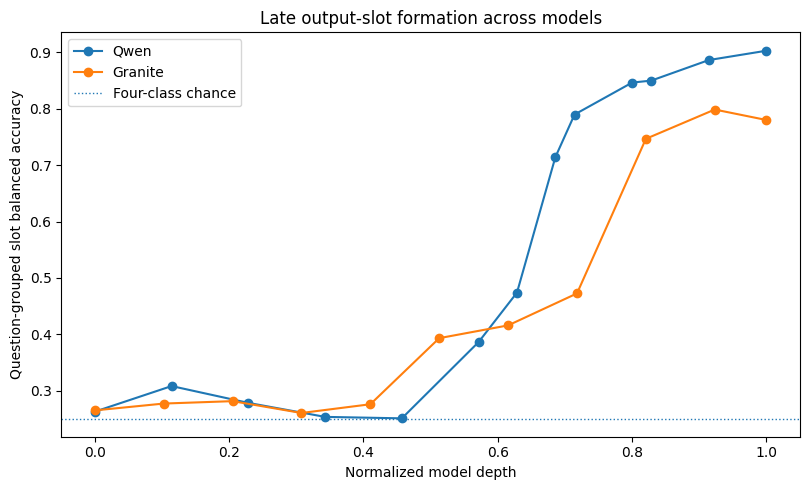

Peak Qwen slot probe: layer 35, balanced accuracy=0.9031
Frozen Qwen causal layers: [22, 25, 29, 32]
Block 22 complete.


In [ ]:
# =====================================================================
# BLOCK 22 — QWEN ANSWER-STATE TRAJECTORY
# =====================================================================
# GPU extraction followed by CPU probes.
#
# Confirmatory design:
# - same 120 question IDs used for Granite when available;
# - question-grouped folds;
# - causal layers fixed from Granite's relative depths before viewing
#   Qwen activation results.

required_22 = [
    "QWEN_MECHANISTIC_GO",
    "qwen_scored_df",
    "grouped_probe",
    "grouped_bootstrap_ci",
]

missing_22 = [
    name
    for name in required_22
    if name not in globals()
]

if missing_22:
    raise RuntimeError(
        "Run Block 21 first. Missing: "
        + ", ".join(missing_22)
    )

if not QWEN_MECHANISTIC_GO:
    raise RuntimeError(
        "Block 21 did not pass the frozen "
        "Qwen mechanistic gate."
    )


QWEN_MAX_ACTIVATION_QUESTIONS = 120
QWEN_ACTIVATION_BATCH_SIZE = 1

# Granite layers 24, 28, 32 and 36 mapped by relative depth
# from a 40-layer model to Qwen's 36-layer model.
QWEN_PATCH_LAYERS = [
    22,
    25,
    29,
    32,
]

QWEN_TRAJECTORY_LAYERS = sorted(
    set(
        list(
            range(
                0,
                model.cfg.n_layers,
                4,
            )
        )
        + [
            model.cfg.n_layers - 1
        ]
        + QWEN_PATCH_LAYERS
    )
)

invalid_layers_22 = [
    layer
    for layer
    in QWEN_TRAJECTORY_LAYERS
    if not (
        0
        <= layer
        < model.cfg.n_layers
    )
]

if invalid_layers_22:
    raise RuntimeError(
        "Invalid Qwen layers: "
        + str(invalid_layers_22)
    )

QWEN_RESIDUAL_HOOKS = {
    layer: (
        f"blocks.{layer}."
        "hook_resid_post"
    )
    for layer
    in QWEN_TRAJECTORY_LAYERS
}

missing_hooks_22 = [
    hook_name
    for hook_name
    in QWEN_RESIDUAL_HOOKS.values()
    if hook_name
    not in model.hook_dict
]

if missing_hooks_22:
    raise RuntimeError(
        "Missing Qwen residual hooks: "
        + ", ".join(
            missing_hooks_22[:5]
        )
    )


# ---------------------------------------------------------------------
# Use the same question subset as Granite
# ---------------------------------------------------------------------

available_qwen_questions_22 = set(
    qwen_scored_df[
        "question_id"
    ].astype(int)
)

if (
    "activation_question_ids"
    in globals()
):
    qwen_activation_question_ids = [
        int(question_id)
        for question_id
        in activation_question_ids
        if int(question_id)
        in available_qwen_questions_22
    ][
        :QWEN_MAX_ACTIVATION_QUESTIONS
    ]
else:
    qwen_activation_question_ids = (
        qwen_scored_df[
            "question_id"
        ]
        .drop_duplicates()
        .sort_values()
        .iloc[
            :QWEN_MAX_ACTIVATION_QUESTIONS
        ]
        .astype(int)
        .tolist()
    )

if (
    len(
        qwen_activation_question_ids
    )
    < QWEN_MAX_ACTIVATION_QUESTIONS
):
    raise RuntimeError(
        "Fewer than 120 paired Qwen "
        "activation questions are available."
    )

qwen_activation_index_df = (
    qwen_scored_df[
        qwen_scored_df[
            "question_id"
        ].isin(
            qwen_activation_question_ids
        )
    ]
    .sort_values(
        "presentation_index"
    )
    .reset_index(drop=True)
)

if (
    len(qwen_activation_index_df)
    != (
        QWEN_MAX_ACTIVATION_QUESTIONS
        * 8
    )
):
    raise RuntimeError(
        "Expected 960 Qwen activation "
        "presentations."
    )


# ---------------------------------------------------------------------
# Extract answer-position residual states
# ---------------------------------------------------------------------

qwen_residual_chunks = {
    layer: []
    for layer
    in QWEN_TRAJECTORY_LAYERS
}


def make_qwen_collector_22(
    layer,
):
    def collector(
        activation,
        hook,
    ):
        if activation.ndim != 3:
            raise RuntimeError(
                f"Layer {layer} returned "
                f"shape "
                f"{tuple(activation.shape)}."
            )

        qwen_residual_chunks[
            layer
        ].append(
            activation[
                :,
                -1,
                :,
            ]
            .detach()
            .to(torch.float16)
            .cpu()
            .numpy()
        )

        return activation

    return collector


for batch_start in tqdm(
    range(
        0,
        len(qwen_activation_index_df),
        QWEN_ACTIVATION_BATCH_SIZE,
    ),
    desc="Qwen answer-state extraction",
):
    batch_stop = min(
        batch_start
        + QWEN_ACTIVATION_BATCH_SIZE,
        len(qwen_activation_index_df),
    )

    prompts = qwen_activation_index_df[
        "prompt"
    ].iloc[
        batch_start:batch_stop
    ].tolist()

    tokens, attention_mask = (
        tokenize_prompts(prompts)
    )

    hooks = [
        (
            QWEN_RESIDUAL_HOOKS[
                layer
            ],
            make_qwen_collector_22(
                layer
            ),
        )
        for layer
        in QWEN_TRAJECTORY_LAYERS
    ]

    with torch.inference_mode():
        model.run_with_hooks(
            tokens,
            attention_mask=attention_mask,
            fwd_hooks=hooks,
            return_type=None,
            use_cache=False,
        )

    del tokens
    del attention_mask


qwen_residual_arrays = {
    layer: np.concatenate(
        qwen_residual_chunks[
            layer
        ],
        axis=0,
    )
    for layer
    in QWEN_TRAJECTORY_LAYERS
}

expected_shape_22 = (
    len(qwen_activation_index_df),
    model.cfg.d_model,
)

for layer, array in (
    qwen_residual_arrays.items()
):
    if array.shape != expected_shape_22:
        raise RuntimeError(
            f"Layer {layer}: "
            f"{array.shape}, expected "
            f"{expected_shape_22}."
        )


# ---------------------------------------------------------------------
# Question-grouped output-slot probes
# ---------------------------------------------------------------------

qwen_slot_targets_22 = (
    qwen_activation_index_df[
        "predicted_slot"
    ].to_numpy(dtype=int)
)

qwen_groups_22 = (
    qwen_activation_index_df[
        "question_id"
    ].to_numpy(dtype=int)
)

trajectory_rows_22 = []

qwen_slot_oof_df = (
    qwen_activation_index_df[
        [
            "presentation_index",
            "question_id",
            "label_system",
            "predicted_slot",
        ]
    ].copy()
)


for layer_index, layer in enumerate(
    QWEN_TRAJECTORY_LAYERS
):
    features = qwen_residual_arrays[
        layer
    ].astype(np.float32)

    probe = grouped_probe(
        features,
        qwen_slot_targets_22,
        qwen_groups_22,
    )

    accuracy = float(
        balanced_accuracy_score(
            qwen_slot_targets_22,
            probe[
                "predictions"
            ],
        )
    )

    ci_low, ci_high = (
        grouped_bootstrap_ci(
            qwen_slot_targets_22,
            probe[
                "predictions"
            ],
            qwen_groups_22,
            balanced_accuracy_score,
            samples=500,
            salt=(
                220
                + layer_index
            ),
        )
    )

    trajectory_rows_22.append(
        {
            "layer": int(layer),

            "normalized_depth": float(
                layer
                / (
                    model.cfg.n_layers
                    - 1
                )
            ),

            "answer_slot_balanced_accuracy": (
                accuracy
            ),

            "ci_low": float(
                ci_low
            ),

            "ci_high": float(
                ci_high
            ),
        }
    )

    qwen_slot_oof_df[
        f"slot_prediction_L{layer}"
    ] = probe[
        "predictions"
    ]

    qwen_slot_oof_df[
        f"slot_fold_L{layer}"
    ] = probe[
        "fold_ids"
    ]


qwen_probe_trajectory_df = pd.DataFrame(
    trajectory_rows_22
)


# ---------------------------------------------------------------------
# Frozen relative-depth transitions
# ---------------------------------------------------------------------

def qwen_layer_accuracy_22(
    layer,
):
    row = qwen_probe_trajectory_df[
        qwen_probe_trajectory_df[
            "layer"
        ]
        == layer
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Missing Qwen layer {layer}."
        )

    return float(
        row[
            "answer_slot_balanced_accuracy"
        ].iloc[0]
    )


qwen_transition_summary_df = pd.DataFrame(
    [
        {
            "transition": "22_to_25",

            "accuracy_change": (
                qwen_layer_accuracy_22(25)
                - qwen_layer_accuracy_22(22)
            ),
        },

        {
            "transition": "25_to_29",

            "accuracy_change": (
                qwen_layer_accuracy_22(29)
                - qwen_layer_accuracy_22(25)
            ),
        },

        {
            "transition": "29_to_32",

            "accuracy_change": (
                qwen_layer_accuracy_22(32)
                - qwen_layer_accuracy_22(29)
            ),
        },
    ]
)


# ---------------------------------------------------------------------
# Save and display
# ---------------------------------------------------------------------

np.savez_compressed(
    QWEN_OUTPUT_DIR
    / "block22_qwen_answer_states.npz",
    **{
        f"layer_{layer}": array
        for layer, array
        in qwen_residual_arrays.items()
    },
)

qwen_activation_index_df.to_pickle(
    QWEN_OUTPUT_DIR
    / "block22_qwen_activation_index.pkl"
)

qwen_probe_trajectory_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block22_qwen_probe_trajectory.csv",
    index=False,
)

qwen_slot_oof_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block22_qwen_slot_probe_oof.csv",
    index=False,
)

qwen_transition_summary_df.to_csv(
    QWEN_OUTPUT_DIR
    / "block22_qwen_transition_summary.csv",
    index=False,
)

print("\nQWEN ANSWER-SLOT TRAJECTORY")

print(
    qwen_probe_trajectory_df
    .round(4)
    .to_string(index=False)
)

print(
    "\nFROZEN RELATIVE-DEPTH TRANSITIONS"
)

print(
    qwen_transition_summary_df
    .round(4)
    .to_string(index=False)
)


fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

ax.plot(
    qwen_probe_trajectory_df[
        "normalized_depth"
    ],
    qwen_probe_trajectory_df[
        "answer_slot_balanced_accuracy"
    ],
    marker="o",
    label="Qwen",
)

if (
    "probe_trajectory_df"
    in globals()
):
    granite_plot_22 = (
        probe_trajectory_df.copy()
    )

    granite_plot_22[
        "normalized_depth"
    ] = (
        granite_plot_22[
            "layer"
        ]
        / 39.0
    )

    ax.plot(
        granite_plot_22[
            "normalized_depth"
        ],
        granite_plot_22[
            "answer_slot_balanced_accuracy"
        ],
        marker="o",
        label="Granite",
    )

ax.axhline(
    0.25,
    linestyle=":",
    linewidth=1,
    label="Four-class chance",
)

ax.set_xlabel(
    "Normalized model depth"
)

ax.set_ylabel(
    "Question-grouped slot "
    "balanced accuracy"
)

ax.set_title(
    "Late output-slot formation "
    "across models"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    QWEN_OUTPUT_DIR
    / "figure_block22_cross_model_slot_trajectory.png",
    dpi=180,
)

plt.show()


best_qwen_22 = (
    qwen_probe_trajectory_df.loc[
        qwen_probe_trajectory_df[
            "answer_slot_balanced_accuracy"
        ].idxmax()
    ]
)

print(
    f"Peak Qwen slot probe: "
    f"layer "
    f"{int(best_qwen_22['layer'])}, "
    f"balanced accuracy="
    f"{best_qwen_22['answer_slot_balanced_accuracy']:.4f}"
)

print(
    "Frozen Qwen causal layers:",
    QWEN_PATCH_LAYERS,
)

print("Block 22 complete.")

Qwen patch pairs: 960
Slot-informative pairs: 833
Pure-binding pairs: 673
Three-way-conflict pairs: 160

QWEN IDENTITY-PATCH CHECK
 layer  identity_patch_accuracy
    22                      1.0
    25                      1.0
    29                      1.0
    32                      1.0


Frozen Qwen causal layers:   0%|          | 0/4 [00:00<?, ?it/s]

Qwen L22 letters:   0%|          | 0/480 [00:00<?, ?it/s]

Qwen L22 digits:   0%|          | 0/480 [00:00<?, ?it/s]

Qwen L25 letters:   0%|          | 0/480 [00:00<?, ?it/s]

...

Qwen L29 letters:   0%|          | 0/480 [00:00<?, ?it/s]

Qwen L29 digits:   0%|          | 0/480 [00:00<?, ?it/s]

Qwen L32 letters:   0%|          | 0/480 [00:00<?, ?it/s]

Qwen L32 digits:   0%|          | 0/480 [00:00<?, ?it/s]


QWEN CROSS-ORDER CAUSAL PATCHING
 layer  all_change_rate  all_source_slot_transfer  all_source_content_transfer  informative_pairs  informative_source_slot_transfer  pure_binding_pairs  pure_binding_slot_transfer  pure_binding_content_preservation  pure_binding_slot_minus_content  pure_binding_diff_ci_low  pure_binding_diff_ci_high  three_way_conflict_pairs  conflict_slot_transfer  conflict_content_transfer  conflict_slot_minus_content  conflict_diff_ci_low  conflict_diff_ci_high
    22           0.0625                    0.1479                       0.6958                833                            0.0252                 673                      0.0208                             0.9599                          -0.9391                   -0.9655                    -0.9116                       160                  0.0438                     0.1062                      -0.0625               -0.1272                 0.0000
    25           0.8292                    0.9240             

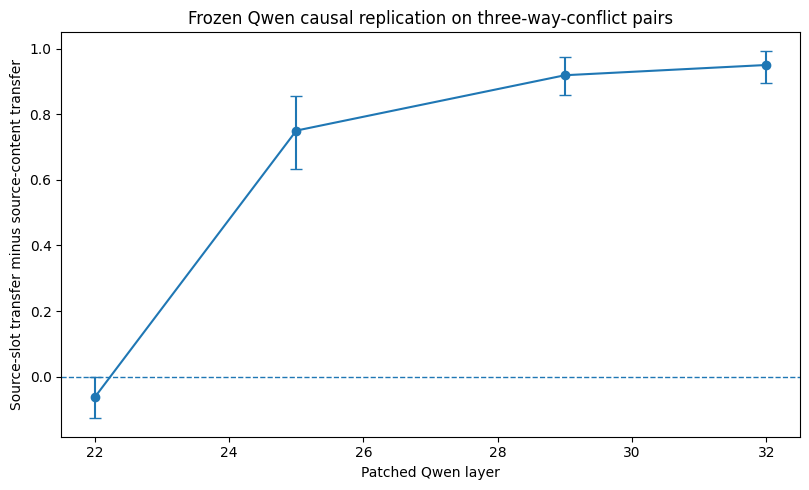


BLOCK 23 GO: the late causal output-slot mechanism replicated in Qwen.
Block 23 complete.


In [ ]:
# =====================================================================
# BLOCK 23 — FROZEN QWEN CROSS-ORDER CAUSAL REPLICATION
# =====================================================================
# Final essential Qwen experiment.
#
# For every target presentation, the source is the next cyclic order
# of the same question under the same label system. The source final-
# position residual state is patched into the target at the layers
# frozen before viewing Qwen activation results: [22, 25, 29, 32].
#
# Main confirmatory test:
# On three-way-conflict pairs, does the patched state transfer the
# source output slot rather than the source answer content?

QWEN_CAUSAL_LAYERS_23 = list(
    QWEN_PATCH_LAYERS
)

QWEN_PATCH_BATCH_SIZE_23 = 1
N_BOOT_23 = 1500
IDENTITY_CHECK_PER_LABEL_23 = 24


# ---------------------------------------------------------------------
# Validate required objects
# ---------------------------------------------------------------------

required_23 = [
    "qwen_activation_index_df",
    "qwen_residual_arrays",
    "QWEN_RESIDUAL_HOOKS",
    "QWEN_PATCH_LAYERS",
    "tokenize_prompts",
    "option_logits_from_vocab",
    "LABEL_SYSTEMS",
    "QWEN_OUTPUT_DIR",
]

missing_23 = [
    name
    for name in required_23
    if name not in globals()
]

if missing_23:
    raise RuntimeError(
        "Run Blocks 19–22 first. Missing: "
        + ", ".join(missing_23)
    )

missing_layers_23 = [
    layer
    for layer in QWEN_CAUSAL_LAYERS_23
    if (
        layer not in qwen_residual_arrays
        or layer not in QWEN_RESIDUAL_HOOKS
    )
]

if missing_layers_23:
    raise RuntimeError(
        "Missing Qwen residual states or hooks "
        f"for layers: {missing_layers_23}"
    )


# ---------------------------------------------------------------------
# Construct deterministic same-question, cross-order patch pairs
# ---------------------------------------------------------------------

qwen_row_lookup_23 = {
    (
        int(row.question_id),
        str(row.label_system),
        int(row.order_id),
    ): int(row_id)
    for row_id, row
    in qwen_activation_index_df.iterrows()
}

qwen_pair_rows_23 = []

for target_row, target in (
    qwen_activation_index_df.iterrows()
):
    question_id = int(
        target["question_id"]
    )

    label_system = str(
        target["label_system"]
    )

    target_order = int(
        target["order_id"]
    )

    source_order = (
        target_order + 1
    ) % 4

    source_key = (
        question_id,
        label_system,
        source_order,
    )

    if source_key not in qwen_row_lookup_23:
        raise RuntimeError(
            "Missing source presentation for "
            f"{source_key}."
        )

    source_row = qwen_row_lookup_23[
        source_key
    ]

    source = qwen_activation_index_df.iloc[
        source_row
    ]

    source_slot = int(
        source["predicted_slot"]
    )

    target_slot = int(
        target["predicted_slot"]
    )

    source_content = int(
        source["predicted_content_id"]
    )

    target_content = int(
        target["predicted_content_id"]
    )

    target_mapping = [
        int(content_id)
        for content_id
        in target["slot_to_content"]
    ]

    target_slot_for_source_content = int(
        target_mapping.index(
            source_content
        )
    )

    qwen_pair_rows_23.append(
        {
            "pair_id": int(
                len(qwen_pair_rows_23)
            ),
            "question_id": question_id,
            "label_system": label_system,
            "source_order": source_order,
            "target_order": target_order,
            "source_row": int(
                source_row
            ),
            "target_row": int(
                target_row
            ),
            "source_slot": source_slot,
            "target_slot": target_slot,
            "source_content": source_content,
            "target_content": target_content,
            "target_slot_for_source_content": (
                target_slot_for_source_content
            ),
            "slot_informative": int(
                source_slot
                != target_slot
            ),
            "order_unstable": int(
                source_content
                != target_content
            ),
            "pure_binding_pair": int(
                source_content
                == target_content
                and source_slot
                != target_slot
            ),
            "three_way_conflict": int(
                source_slot
                != target_slot
                and target_slot_for_source_content
                != target_slot
                and source_slot
                != target_slot_for_source_content
            ),
        }
    )

qwen_patch_pair_df_23 = pd.DataFrame(
    qwen_pair_rows_23
)

if (
    len(qwen_patch_pair_df_23)
    != len(qwen_activation_index_df)
):
    raise RuntimeError(
        "Expected one Qwen patch pair "
        "per target presentation."
    )

if (
    qwen_patch_pair_df_23[
        "pair_id"
    ].nunique()
    != len(qwen_patch_pair_df_23)
):
    raise RuntimeError(
        "Qwen patch pair IDs are not unique."
    )

print(
    "Qwen patch pairs:",
    len(qwen_patch_pair_df_23),
)

print(
    "Slot-informative pairs:",
    int(
        qwen_patch_pair_df_23[
            "slot_informative"
        ].sum()
    ),
)

print(
    "Pure-binding pairs:",
    int(
        qwen_patch_pair_df_23[
            "pure_binding_pair"
        ].sum()
    ),
)

print(
    "Three-way-conflict pairs:",
    int(
        qwen_patch_pair_df_23[
            "three_way_conflict"
        ].sum()
    ),
)


# ---------------------------------------------------------------------
# Qwen patched forward pass
# ---------------------------------------------------------------------

def run_qwen_answer_state_patch_23(
    layer,
    pair_frame,
    show_progress=True,
):
    frame = pair_frame.reset_index(
        drop=True
    )

    patched_slots = np.full(
        len(frame),
        -1,
        dtype=int,
    )

    for label_system in LABEL_SYSTEMS:
        label_indices = np.flatnonzero(
            frame[
                "label_system"
            ].to_numpy()
            == label_system
        )

        batch_starts = range(
            0,
            len(label_indices),
            QWEN_PATCH_BATCH_SIZE_23,
        )

        if show_progress:
            batch_starts = tqdm(
                batch_starts,
                total=int(
                    np.ceil(
                        len(label_indices)
                        / QWEN_PATCH_BATCH_SIZE_23
                    )
                ),
                desc=(
                    f"Qwen L{layer} "
                    f"{label_system}"
                ),
                leave=False,
            )

        for batch_start in batch_starts:
            batch_indices = label_indices[
                batch_start:
                batch_start
                + QWEN_PATCH_BATCH_SIZE_23
            ]

            batch = frame.iloc[
                batch_indices
            ]

            target_rows = batch[
                "target_row"
            ].to_numpy(dtype=int)

            source_rows = batch[
                "source_row"
            ].to_numpy(dtype=int)

            prompts = (
                qwen_activation_index_df
                .iloc[target_rows][
                    "prompt"
                ]
                .tolist()
            )

            replacement_array = (
                qwen_residual_arrays[
                    layer
                ][
                    source_rows
                ]
            )

            replacements = torch.tensor(
                replacement_array,
                device=DEVICE,
            )

            def patch_hook(
                activation,
                hook,
                replacement=replacements,
            ):
                patched = activation.clone()

                patched[
                    :,
                    -1,
                    :,
                ] = replacement.to(
                    device=activation.device,
                    dtype=activation.dtype,
                )

                return patched

            tokens, attention_mask = (
                tokenize_prompts(
                    prompts
                )
            )

            with torch.inference_mode():
                logits = model.run_with_hooks(
                    tokens,
                    attention_mask=attention_mask,
                    fwd_hooks=[
                        (
                            QWEN_RESIDUAL_HOOKS[
                                layer
                            ],
                            patch_hook,
                        )
                    ],
                    return_type="logits",
                    use_cache=False,
                )

            vocabulary_logits = (
                logits[
                    :,
                    -1,
                    :,
                ]
                .float()
                .cpu()
            )

            answer_logits = (
                option_logits_from_vocab(
                    vocabulary_logits,
                    label_system,
                )
            )

            patched_slots[
                batch_indices
            ] = (
                answer_logits
                .argmax(dim=-1)
                .numpy()
                .astype(int)
            )

            del tokens
            del attention_mask
            del logits
            del vocabulary_logits
            del answer_logits
            del replacements

    if (
        patched_slots < 0
    ).any():
        raise RuntimeError(
            f"Layer {layer}: some Qwen "
            "patched predictions are missing."
        )

    patched_contents = np.asarray(
        [
            int(
                qwen_activation_index_df
                .iloc[
                    int(target_row)
                ][
                    "slot_to_content"
                ][
                    int(slot)
                ]
            )
            for slot, target_row
            in zip(
                patched_slots,
                frame[
                    "target_row"
                ].to_numpy(dtype=int),
            )
        ],
        dtype=int,
    )

    return (
        patched_slots,
        patched_contents,
    )


# ---------------------------------------------------------------------
# Identity-patch validity control
# ---------------------------------------------------------------------

identity_parts_23 = []

for label_system in LABEL_SYSTEMS:
    current = (
        qwen_patch_pair_df_23[
            qwen_patch_pair_df_23[
                "label_system"
            ]
            == label_system
        ]
        .head(
            IDENTITY_CHECK_PER_LABEL_23
        )
        .copy()
    )

    identity_parts_23.append(
        current
    )

qwen_identity_df_23 = pd.concat(
    identity_parts_23,
    ignore_index=True,
)

qwen_identity_df_23[
    "source_row"
] = qwen_identity_df_23[
    "target_row"
].astype(int)

identity_rows_23 = []

for layer in QWEN_CAUSAL_LAYERS_23:
    (
        identity_slots,
        _,
    ) = run_qwen_answer_state_patch_23(
        layer,
        qwen_identity_df_23,
        show_progress=False,
    )

    identity_accuracy = float(
        np.mean(
            identity_slots
            == qwen_identity_df_23[
                "target_slot"
            ].to_numpy(dtype=int)
        )
    )

    identity_rows_23.append(
        {
            "layer": int(layer),
            "identity_patch_accuracy": (
                identity_accuracy
            ),
        }
    )

qwen_identity_patch_df_23 = pd.DataFrame(
    identity_rows_23
)

print(
    "\nQWEN IDENTITY-PATCH CHECK"
)

print(
    qwen_identity_patch_df_23
    .round(4)
    .to_string(index=False)
)

if (
    qwen_identity_patch_df_23[
        "identity_patch_accuracy"
    ].min()
    < 0.98
):
    raise RuntimeError(
        "Qwen identity patching failed. "
        "Stop before interpreting the "
        "cross-order intervention."
    )


# ---------------------------------------------------------------------
# Frozen cross-order causal intervention
# ---------------------------------------------------------------------

qwen_layer_frames_23 = []

for layer in tqdm(
    QWEN_CAUSAL_LAYERS_23,
    desc="Frozen Qwen causal layers",
):
    (
        patched_slots,
        patched_contents,
    ) = run_qwen_answer_state_patch_23(
        layer,
        qwen_patch_pair_df_23,
        show_progress=True,
    )

    current = (
        qwen_patch_pair_df_23.copy()
    )

    current[
        "layer"
    ] = int(layer)

    current[
        "patched_slot"
    ] = patched_slots

    current[
        "patched_content"
    ] = patched_contents

    current[
        "changed_from_target"
    ] = (
        current[
            "patched_slot"
        ]
        != current[
            "target_slot"
        ]
    ).astype(int)

    current[
        "source_slot_transfer"
    ] = (
        current[
            "patched_slot"
        ]
        == current[
            "source_slot"
        ]
    ).astype(int)

    current[
        "source_content_transfer"
    ] = (
        current[
            "patched_slot"
        ]
        == current[
            "target_slot_for_source_content"
        ]
    ).astype(int)

    current[
        "target_slot_preserved"
    ] = (
        current[
            "patched_slot"
        ]
        == current[
            "target_slot"
        ]
    ).astype(int)

    qwen_layer_frames_23.append(
        current
    )

    gc.collect()
    torch.cuda.empty_cache()

qwen_patch_results_df_23 = pd.concat(
    qwen_layer_frames_23,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Question-clustered paired bootstrap
# ---------------------------------------------------------------------

def clustered_mean_ci_23(
    frame,
    value_column,
    n_boot=N_BOOT_23,
    salt=0,
):
    frame = frame.reset_index(
        drop=True
    )

    if len(frame) == 0:
        return (
            np.nan,
            np.nan,
            np.nan,
            0,
        )

    observed = float(
        frame[
            value_column
        ].mean()
    )

    questions = frame[
        "question_id"
    ].unique()

    rows_by_question = {
        question_id: np.flatnonzero(
            frame[
                "question_id"
            ].to_numpy()
            == question_id
        )
        for question_id in questions
    }

    rng = np.random.default_rng(
        SEED + 2300 + salt
    )

    bootstrap_values = []

    for _ in range(n_boot):
        sampled_questions = rng.choice(
            questions,
            size=len(questions),
            replace=True,
        )

        sampled_rows = np.concatenate(
            [
                rows_by_question[
                    question_id
                ]
                for question_id
                in sampled_questions
            ]
        )

        bootstrap_values.append(
            float(
                frame.iloc[
                    sampled_rows
                ][
                    value_column
                ].mean()
            )
        )

    return (
        observed,
        float(
            np.quantile(
                bootstrap_values,
                0.025,
            )
        ),
        float(
            np.quantile(
                bootstrap_values,
                0.975,
            )
        ),
        int(len(frame)),
    )


def clustered_difference_ci_23(
    frame,
    first_column,
    second_column,
    n_boot=N_BOOT_23,
    salt=0,
):
    frame = frame.copy()

    difference_column = (
        "_paired_difference_23"
    )

    frame[
        difference_column
    ] = (
        frame[
            first_column
        ].astype(float)
        - frame[
            second_column
        ].astype(float)
    )

    return clustered_mean_ci_23(
        frame,
        difference_column,
        n_boot=n_boot,
        salt=salt,
    )


summary_rows_23 = []

for layer_index, layer in enumerate(
    QWEN_CAUSAL_LAYERS_23
):
    current = qwen_patch_results_df_23[
        qwen_patch_results_df_23[
            "layer"
        ]
        == layer
    ]

    informative = current[
        current[
            "slot_informative"
        ]
        == 1
    ]

    pure_binding = current[
        current[
            "pure_binding_pair"
        ]
        == 1
    ]

    conflict = current[
        current[
            "three_way_conflict"
        ]
        == 1
    ]

    (
        conflict_difference,
        conflict_ci_low,
        conflict_ci_high,
        conflict_n,
    ) = clustered_difference_ci_23(
        conflict,
        "source_slot_transfer",
        "source_content_transfer",
        salt=layer_index,
    )

    (
        pure_difference,
        pure_ci_low,
        pure_ci_high,
        pure_n,
    ) = clustered_difference_ci_23(
        pure_binding,
        "source_slot_transfer",
        "source_content_transfer",
        salt=100 + layer_index,
    )

    summary_rows_23.append(
        {
            "layer": int(layer),

            "all_change_rate": float(
                current[
                    "changed_from_target"
                ].mean()
            ),

            "all_source_slot_transfer": float(
                current[
                    "source_slot_transfer"
                ].mean()
            ),

            "all_source_content_transfer": float(
                current[
                    "source_content_transfer"
                ].mean()
            ),

            "informative_pairs": int(
                len(informative)
            ),

            "informative_source_slot_transfer": float(
                informative[
                    "source_slot_transfer"
                ].mean()
            ),

            "pure_binding_pairs": int(
                pure_n
            ),

            "pure_binding_slot_transfer": float(
                pure_binding[
                    "source_slot_transfer"
                ].mean()
            ) if pure_n else np.nan,

            "pure_binding_content_preservation": float(
                pure_binding[
                    "source_content_transfer"
                ].mean()
            ) if pure_n else np.nan,

            "pure_binding_slot_minus_content": float(
                pure_difference
            ),

            "pure_binding_diff_ci_low": float(
                pure_ci_low
            ),

            "pure_binding_diff_ci_high": float(
                pure_ci_high
            ),

            "three_way_conflict_pairs": int(
                conflict_n
            ),

            "conflict_slot_transfer": float(
                conflict[
                    "source_slot_transfer"
                ].mean()
            ) if conflict_n else np.nan,

            "conflict_content_transfer": float(
                conflict[
                    "source_content_transfer"
                ].mean()
            ) if conflict_n else np.nan,

            "conflict_slot_minus_content": float(
                conflict_difference
            ),

            "conflict_diff_ci_low": float(
                conflict_ci_low
            ),

            "conflict_diff_ci_high": float(
                conflict_ci_high
            ),
        }
    )

qwen_patch_summary_df_23 = pd.DataFrame(
    summary_rows_23
)


# ---------------------------------------------------------------------
# Paired layer-transition tests on three-way-conflict pairs
# ---------------------------------------------------------------------

qwen_conflict_results_23 = (
    qwen_patch_results_df_23[
        qwen_patch_results_df_23[
            "three_way_conflict"
        ]
        == 1
    ][
        [
            "pair_id",
            "question_id",
            "layer",
            "source_slot_transfer",
            "source_content_transfer",
        ]
    ]
    .copy()
)

qwen_conflict_results_23[
    "slot_minus_content"
] = (
    qwen_conflict_results_23[
        "source_slot_transfer"
    ]
    - qwen_conflict_results_23[
        "source_content_transfer"
    ]
)

transition_wide_23 = (
    qwen_conflict_results_23.pivot(
        index=[
            "pair_id",
            "question_id",
        ],
        columns="layer",
        values="slot_minus_content",
    )
    .reset_index()
)

for layer in QWEN_CAUSAL_LAYERS_23:
    if layer not in transition_wide_23:
        raise RuntimeError(
            f"Layer {layer} is missing from "
            "the Qwen transition table."
        )

transition_pairs_23 = list(
    zip(
        QWEN_CAUSAL_LAYERS_23[:-1],
        QWEN_CAUSAL_LAYERS_23[1:],
    )
)

transition_rows_23 = []

for transition_index, (
    earlier_layer,
    later_layer,
) in enumerate(
    transition_pairs_23
):
    transition_name = (
        f"{earlier_layer}_to_"
        f"{later_layer}"
    )

    transition_wide_23[
        transition_name
    ] = (
        transition_wide_23[
            later_layer
        ]
        - transition_wide_23[
            earlier_layer
        ]
    )

    (
        transition_mean,
        transition_ci_low,
        transition_ci_high,
        transition_n,
    ) = clustered_mean_ci_23(
        transition_wide_23,
        transition_name,
        salt=300 + transition_index,
    )

    transition_rows_23.append(
        {
            "transition": transition_name,

            "conflict_pairs": int(
                transition_n
            ),

            "mean_change_in_slot_minus_content": float(
                transition_mean
            ),

            "ci_low": float(
                transition_ci_low
            ),

            "ci_high": float(
                transition_ci_high
            ),
        }
    )

qwen_causal_transition_df_23 = pd.DataFrame(
    transition_rows_23
)


# ---------------------------------------------------------------------
# Frozen causal-replication decision
# ---------------------------------------------------------------------

late_layers_23 = [
    29,
    32,
]

late_summary_23 = (
    qwen_patch_summary_df_23[
        qwen_patch_summary_df_23[
            "layer"
        ].isin(
            late_layers_23
        )
    ]
)

identity_valid_23 = bool(
    (
        qwen_identity_patch_df_23[
            "identity_patch_accuracy"
        ]
        >= 0.98
    ).all()
)

late_slot_dominance_23 = bool(
    (
        (
            late_summary_23[
                "conflict_diff_ci_low"
            ]
            > 0
        )
        & (
            late_summary_23[
                "conflict_slot_transfer"
            ]
            >= 0.60
        )
    ).any()
)

QWEN_CAUSAL_REPLICATION_GO = bool(
    identity_valid_23
    and late_slot_dominance_23
)

qwen_causal_gate_df_23 = pd.DataFrame(
    [
        {
            "condition": (
                "identity_patch_accuracy_"
                "at_least_0.98"
            ),
            "passed": identity_valid_23,
        },

        {
            "condition": (
                "late_three_way_conflict_"
                "slot_dominance"
            ),
            "passed": late_slot_dominance_23,
        },

        {
            "condition": (
                "overall_qwen_causal_"
                "replication_go"
            ),
            "passed": (
                QWEN_CAUSAL_REPLICATION_GO
            ),
        },
    ]
)


# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------

qwen_patch_pair_df_23.to_pickle(
    QWEN_OUTPUT_DIR
    / "block23_qwen_patch_pairs.pkl"
)

qwen_patch_results_df_23.to_pickle(
    QWEN_OUTPUT_DIR
    / "block23_qwen_patch_results.pkl"
)

qwen_identity_patch_df_23.to_csv(
    QWEN_OUTPUT_DIR
    / "block23_qwen_identity_patch.csv",
    index=False,
)

qwen_patch_summary_df_23.to_csv(
    QWEN_OUTPUT_DIR
    / "block23_qwen_patch_summary.csv",
    index=False,
)

qwen_causal_transition_df_23.to_csv(
    QWEN_OUTPUT_DIR
    / "block23_qwen_causal_transitions.csv",
    index=False,
)

qwen_causal_gate_df_23.to_csv(
    QWEN_OUTPUT_DIR
    / "block23_qwen_causal_gate.csv",
    index=False,
)


# ---------------------------------------------------------------------
# Display results
# ---------------------------------------------------------------------

print(
    "\nQWEN CROSS-ORDER CAUSAL PATCHING"
)

print(
    qwen_patch_summary_df_23
    .round(4)
    .to_string(index=False)
)

print(
    "\nQWEN CAUSAL TRANSITIONS "
    "ON THREE-WAY-CONFLICT PAIRS"
)

print(
    qwen_causal_transition_df_23
    .round(4)
    .to_string(index=False)
)

print(
    "\nQWEN CAUSAL REPLICATION GATE"
)

print(
    qwen_causal_gate_df_23
    .to_string(index=False)
)


fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

midpoint_23 = qwen_patch_summary_df_23[
    "conflict_slot_minus_content"
]

lower_error_23 = (
    midpoint_23
    - qwen_patch_summary_df_23[
        "conflict_diff_ci_low"
    ]
)

upper_error_23 = (
    qwen_patch_summary_df_23[
        "conflict_diff_ci_high"
    ]
    - midpoint_23
)

ax.errorbar(
    qwen_patch_summary_df_23[
        "layer"
    ],
    midpoint_23,
    yerr=np.vstack(
        [
            lower_error_23,
            upper_error_23,
        ]
    ),
    marker="o",
    capsize=4,
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Patched Qwen layer"
)

ax.set_ylabel(
    "Source-slot transfer minus "
    "source-content transfer"
)

ax.set_title(
    "Frozen Qwen causal replication "
    "on three-way-conflict pairs"
)

fig.tight_layout()

fig.savefig(
    QWEN_OUTPUT_DIR
    / "figure_block23_qwen_causal_replication.png",
    dpi=180,
)

plt.show()


# ---------------------------------------------------------------------
# Optional cross-model export
# ---------------------------------------------------------------------

if (
    "patch_summary_df"
    in globals()
):
    granite_cross_model_23 = (
        patch_summary_df.copy()
    )

    granite_cross_model_23[
        "model"
    ] = "Granite-3.3-2B"

    granite_cross_model_23[
        "normalized_depth"
    ] = (
        granite_cross_model_23[
            "layer"
        ]
        / 39.0
    )

    qwen_cross_model_23 = (
        qwen_patch_summary_df_23.copy()
    )

    qwen_cross_model_23[
        "model"
    ] = (
        "Qwen3-4B-Instruct-2507"
    )

    qwen_cross_model_23[
        "normalized_depth"
    ] = (
        qwen_cross_model_23[
            "layer"
        ]
        / (
            model.cfg.n_layers - 1
        )
    )

    cross_model_causal_df_23 = pd.concat(
        [
            granite_cross_model_23,
            qwen_cross_model_23,
        ],
        ignore_index=True,
        sort=False,
    )

    cross_model_causal_df_23.to_csv(
        QWEN_OUTPUT_DIR
        / "block23_cross_model_causal_summary.csv",
        index=False,
    )


if QWEN_CAUSAL_REPLICATION_GO:
    print(
        "\nBLOCK 23 GO: the late causal "
        "output-slot mechanism replicated "
        "in Qwen."
    )
else:
    print(
        "\nBLOCK 23 NO-GO: Qwen did not "
        "meet the frozen causal-replication "
        "criterion. Retain Granite as the "
        "causal case and Qwen as behavioural "
        "plus representational replication."
    )

print("Block 23 complete.")